# Sewage Network — Final Manual Correction Post-Processing

This notebook is a **post-processing-only** workflow. It does **not** rerun the network expansion algorithms.

It reads:

- the automatic QGIS outputs already produced by the non-budgeted and budgeted notebooks;
- the manually corrected WWTP2 existing-pipe layers stored in `Results\After_Manual_Networks_Correction`;
- optional pumping station layers from the automatic QGIS files or from `areas2/pumps.gpkg`.

It then creates, for each of the five scenarios:

- a final corrected GeoPackage;
- an interactive Folium HTML map with selectable layers;
- final WWTP1/WWTP2 population and wastewater-load statistics;
- final coverage-by-municipality tables;
- pipe length/cost summaries;
- cross-scenario comparison CSVs.


In [1]:

# ============================================================
# BLOCK 1 -- CONFIGURATION
# ============================================================

from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\lucam\OneDrive\Desktop\Cyprus Project")

RESULTS_DIR = PROJECT_DIR / "Results"
NONBUDGETED_DIR = RESULTS_DIR / "NetworkNonBudgeted"
BUDGETED_DIR = RESULTS_DIR / "NetworkBudgeted"

MANUAL_CORRECTION_DIR = RESULTS_DIR / "After_Manual_Networks_Correction"

# Input folders used only for optional layers such as pumping stations.
AREAS2_DIR = PROJECT_DIR / "areas2"
AREAS_DIR = PROJECT_DIR / "areas"

CRS_PROJECTED = "EPSG:32636"
CRS_WGS84 = "EPSG:4326"

# Financial and wastewater assumptions.
# Change these only if your main notebooks use different values.
PIPE_COST_EUR_PER_M = 400.0
WASTEWATER_L_PER_CAPITA_DAY = 120.0

# Distance used to assign demand nodes to the nearest final pipe system.
# If too many nodes remain unassigned, increase slightly, e.g. 100.
POST_FIX_PIPE_SERVICE_BUFFER_M = 80.0

# Used when matching manual WWTP2 pipes to the automatic existing-pipe reference.
# The ID-based match is used first; geometry overlap is only a fallback.
GEOMETRY_MATCH_MIN_OVERLAP_RATIO = 0.80

# Map behaviour.
MAP_SIMPLIFY_TOLERANCE_M = 2.0
MAP_MAX_DEMAND_NODE_MARKERS = None  # None = show all demand nodes; use an integer if the HTML becomes too heavy
MAP_SHOW_DEMAND_NODES_BY_DEFAULT = False
MAP_SHOW_PUMPS_BY_DEFAULT = True
MAP_SHOW_WWTP1_PIPES_BY_DEFAULT = True
MAP_SHOW_WWTP2_PIPES_BY_DEFAULT = True
MAP_SHOW_NEW_PIPES_BY_DEFAULT = True
MAP_SHOW_NOT_CONSIDERED_NODES_BY_DEFAULT = False

# Scenario configuration.
# manual_wwtp2_file represents the final manually corrected EXISTING-pipe layer assigned to WWTP2.
SCENARIOS = [
    {
        "scenario_key": "dijkstra",
        "display_name": "Rooted Dijkstra / Shortest-Path",
        "algorithm_family": "non_budgeted",
        "automatic_dir": NONBUDGETED_DIR / "heuristic_rooted_dijkstra",
        "manual_wwtp2_file": MANUAL_CORRECTION_DIR / "Dijkstra_WWTP2.gpkg",
        "output_subdir": MANUAL_CORRECTION_DIR / "dijkstra_final_manual_correction",
    },
    {
        "scenario_key": "prim_steiner",
        "display_name": "Prim-Steiner",
        "algorithm_family": "non_budgeted",
        "automatic_dir": NONBUDGETED_DIR / "heuristic_prim_steiner",
        "manual_wwtp2_file": MANUAL_CORRECTION_DIR / "PrimSteiner_WWTP2.gpkg",
        "output_subdir": MANUAL_CORRECTION_DIR / "prim_steiner_final_manual_correction",
    },
    {
        "scenario_key": "shared_trunk",
        "display_name": "Shared-Trunk Expansion",
        "algorithm_family": "budgeted",
        "automatic_dir": BUDGETED_DIR / "heuristic_shared_trunk",
        "manual_wwtp2_file": MANUAL_CORRECTION_DIR / "SharedTrunk_WWTP2.gpkg",
        "output_subdir": MANUAL_CORRECTION_DIR / "shared_trunk_final_manual_correction",
    },
    {
        "scenario_key": "urban_priority",
        "display_name": "Urban Priority",
        "algorithm_family": "budgeted",
        "automatic_dir": BUDGETED_DIR / "heuristic_urban_priority",
        "manual_wwtp2_file": MANUAL_CORRECTION_DIR / "UrbanPriority_WWTP2.gpkg",
        "output_subdir": MANUAL_CORRECTION_DIR / "urban_priority_final_manual_correction",
    },
    {
        "scenario_key": "municipality_targets",
        "display_name": "Municipality Target-Progression",
        "algorithm_family": "budgeted",
        "automatic_dir": BUDGETED_DIR / "heuristic_municipality_targets",
        "manual_wwtp2_file": MANUAL_CORRECTION_DIR / "MunicipalityPriority_WWTP2.gpkg",
        "output_subdir": MANUAL_CORRECTION_DIR / "municipality_targets_final_manual_correction",
    },
]

print("Manual correction directory:")
print(MANUAL_CORRECTION_DIR)
print("\nConfigured scenarios:")
for s in SCENARIOS:
    print(f"  - {s['scenario_key']}:")
    print(f"      auto dir : {s['automatic_dir']}")
    print(f"      manual   : {s['manual_wwtp2_file']}")
    print(f"      output   : {s['output_subdir']}")


Manual correction directory:
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction

Configured scenarios:
  - dijkstra:
      auto dir : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\NetworkNonBudgeted\heuristic_rooted_dijkstra
      manual   : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\Dijkstra_WWTP2.gpkg
      output   : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction
  - prim_steiner:
      auto dir : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\NetworkNonBudgeted\heuristic_prim_steiner
      manual   : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\PrimSteiner_WWTP2.gpkg
      output   : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\prim_steiner_final_manual_correction
  - shared_trunk:
      auto dir : C:\Users\lucam\OneDrive\Deskt


### Correction note: preserved upstream WWTP demand assignment

This version fixes the demand-node reassignment logic in `CorrectedNetwork`.
The Budgeted/NonBudgeted notebooks already assign southern urban demand nodes to the existing WWTP1 system. In municipalities where the existing pipe geometries are incomplete or missing, a purely distance-based reassignment in `CorrectedNetwork` can incorrectly convert those nodes to `UNASSIGNED`.

The corrected logic now works as follows:

1. assign demand nodes by distance to the final manually corrected WWTP1/WWTP2 pipe layers when possible;
2. if a load-eligible node remains `UNASSIGNED`, preserve its upstream Budgeted/NonBudgeted WWTP assignment;
3. label these cases with `assignment_source = upstream_WWTP1_assignment_preserved_missing_pipe_geometry` or `upstream_WWTP2_assignment_preserved_missing_pipe_geometry`;
4. save the preserved nodes in the GeoPackage layer `demand_nodes_preserved_upstream_assignment`.


In [2]:

# ============================================================
# BLOCK 2 -- IMPORTS
# ============================================================

import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

try:
    import fiona
except Exception as e:
    raise RuntimeError("fiona is required to list GeoPackage layers.") from e

try:
    import folium
    from folium.plugins import Fullscreen, MiniMap, MeasureControl
    HAS_FOLIUM = True
except Exception:
    HAS_FOLIUM = False
    print("WARNING: folium is not available. HTML maps will be skipped.")

try:
    from IPython.display import display
except Exception:
    display = None

print("Imports completed.")
print(f"GeoPandas: {gpd.__version__}")
print(f"Fiona    : {fiona.__version__}")
print(f"Folium   : {'available' if HAS_FOLIUM else 'not available'}")


Imports completed.
GeoPandas: 1.1.1
Fiona    : 1.10.1
Folium   : available


In [3]:

# ============================================================
# BLOCK 3 -- GENERAL HELPERS
# ============================================================

WWTP1_LABEL = "WWTP_1_SOUTH"
WWTP2_LABEL = "WWTP_2_NORTH"


def safe_numeric(series, default=0.0):
    return pd.to_numeric(series, errors="coerce").fillna(default)


def ensure_projected(gdf, crs=CRS_PROJECTED):
    if gdf is None:
        return gpd.GeoDataFrame(geometry=[], crs=crs)

    if len(gdf) == 0:
        if isinstance(gdf, gpd.GeoDataFrame) and "geometry" in gdf.columns:
            return gpd.GeoDataFrame(gdf, geometry="geometry", crs=crs)
        return gpd.GeoDataFrame(geometry=[], crs=crs)

    if gdf.crs is None:
        return gdf.set_crs(crs)
    return gdf.to_crs(crs)


def clean_geometries(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    out = gdf.copy()
    out = out[out.geometry.notna() & (~out.geometry.is_empty)].copy()
    return out


def geometry_length_m(gdf):
    if gdf is None or len(gdf) == 0:
        return 0.0
    gg = ensure_projected(gdf)
    return float(gg.geometry.length.sum())


def ensure_length_cost_columns(gdf, pipe_group):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    out = ensure_projected(gdf).copy()
    out = clean_geometries(out)

    if len(out) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    if "length_m" in out.columns:
        out["length_m"] = pd.to_numeric(out["length_m"], errors="coerce")
        out["length_m"] = out["length_m"].fillna(out.geometry.length)
    else:
        out["length_m"] = out.geometry.length

    out["length_km"] = out["length_m"] / 1000.0
    out["cost_eur"] = out["length_m"] * PIPE_COST_EUR_PER_M
    out["pipe_group"] = pipe_group

    return out


def safe_value_for_gpkg(x):
    if isinstance(x, (list, tuple, set)):
        return ", ".join(map(str, x))
    if isinstance(x, dict):
        return json.dumps(x)
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass
    return x


def clean_for_gpkg(gdf):
    if gdf is None or len(gdf) == 0:
        return gdf

    out = gdf.copy()
    geom_col = out.geometry.name if hasattr(out, "geometry") else "geometry"

    for col in out.columns:
        if col == geom_col:
            continue

        if str(out[col].dtype) == "object":
            out[col] = out[col].apply(safe_value_for_gpkg)

    return out


def write_gpkg_layer(gdf, gpkg_path, layer_name):
    if gdf is None or len(gdf) == 0:
        print(f"    skipped empty layer: {layer_name}")
        return

    out = clean_for_gpkg(gdf)
    out.to_file(gpkg_path, layer=layer_name, driver="GPKG")
    print(f"    wrote layer: {layer_name} ({len(out):,} features)")


def list_layers_safe(path):
    path = Path(path)
    if not path.exists():
        return []
    try:
        return list(fiona.listlayers(path))
    except Exception:
        return []


def _normalise_layer_name(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).lower()).strip("_")


def _candidate_tokens(candidate):
    """
    Convert an expected layer name such as 'existing_pipes_WWTP1'
    into robust search tokens. This allows matching actual QGIS-exported names
    such as 'Block15_rooted_dijkstra_network_for_qgis_edit__existing_pipes_wwtp1'.
    """
    c = _normalise_layer_name(candidate)
    tokens = [t for t in c.split("_") if t]

    # Remove weak/common words that often differ across exports.
    weak = {
        "layer", "final", "manual", "corrected", "assignment", "postfix",
        "network", "for", "qgis", "edit", "block15", "block", "output",
    }
    tokens = [t for t in tokens if t not in weak]

    return tokens


def _score_layer_match(layer_name, candidate):
    """
    Score how well a real layer name matches an expected candidate name.
    Exact/case-insensitive matches should already have been checked before.
    """
    layer_norm = _normalise_layer_name(layer_name)
    tokens = _candidate_tokens(candidate)

    if not tokens:
        return 0

    score = 0
    for t in tokens:
        if t in layer_norm:
            score += 1

    # Strongly prefer WWTP-specific matches.
    cand_norm = _normalise_layer_name(candidate)
    if "wwtp1" in cand_norm and "wwtp1" not in layer_norm:
        return 0
    if "wwtp2" in cand_norm and "wwtp2" not in layer_norm:
        return 0

    # Strongly prefer geometry family matches.
    if "pipes" in cand_norm and "pipes" not in layer_norm and "conduits" not in layer_norm:
        return 0
    if "demand" in cand_norm and "demand" not in layer_norm:
        return 0
    if ("pump" in cand_norm or "pumping" in cand_norm) and ("pump" not in layer_norm and "pumping" not in layer_norm):
        return 0

    return score


def read_layer_if_exists(path, layer_candidates, target_crs=CRS_PROJECTED, verbose=True):
    """
    Read the first matching layer from a GeoPackage.

    Matching order:
    1. exact layer name;
    2. case-insensitive exact layer name;
    3. fuzzy token match, useful for QGIS-exported layer names with prefixes.
    """
    path = Path(path)
    if not path.exists():
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    layers = list_layers_safe(path)
    if not layers:
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    # 1. Exact match.
    selected_layer = None
    for candidate in layer_candidates:
        if candidate in layers:
            selected_layer = candidate
            break

    # 2. Case-insensitive exact match.
    if selected_layer is None:
        lower_to_layer = {_normalise_layer_name(l): l for l in layers}
        for candidate in layer_candidates:
            key = _normalise_layer_name(candidate)
            if key in lower_to_layer:
                selected_layer = lower_to_layer[key]
                break

    # 3. Fuzzy token match.
    if selected_layer is None:
        best = None
        best_score = 0
        for candidate in layer_candidates:
            for layer in layers:
                score = _score_layer_match(layer, candidate)
                if score > best_score:
                    best_score = score
                    best = layer

        if best is not None and best_score >= 2:
            selected_layer = best

    if selected_layer is None:
        if verbose:
            print(f"    WARNING: no layer matched {layer_candidates} in {path.name}. Available layers: {layers}")
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    if verbose:
        print(f"    read layer '{selected_layer}' from {path.name}")

    gdf = gpd.read_file(path, layer=selected_layer)

    if gdf.crs is None:
        gdf = gdf.set_crs(target_crs)
    else:
        gdf = gdf.to_crs(target_crs)

    return clean_geometries(gdf)


def read_first_layer(path, target_crs=CRS_PROJECTED):
    path = Path(path)
    if not path.exists():
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    layers = list_layers_safe(path)
    if not layers:
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    gdf = gpd.read_file(path, layer=layers[0])

    if gdf.crs is None:
        gdf = gdf.set_crs(target_crs)
    else:
        gdf = gdf.to_crs(target_crs)

    return clean_geometries(gdf)


def detect_automatic_network_gpkg(automatic_dir, scenario_key):
    automatic_dir = Path(automatic_dir)

    candidates = [
        automatic_dir / "network_for_qgis_edit.gpkg",
        automatic_dir / f"{scenario_key}_network_for_qgis_edit.gpkg",
        automatic_dir / f"Block15_{scenario_key}_network_for_qgis_edit.gpkg",
        automatic_dir / f"Block15_{scenario_key.replace('shared_trunk', 'shared-trunk')}_network_for_qgis_edit.gpkg",
    ]

    for p in candidates:
        if p.exists():
            return p

    matches = sorted(automatic_dir.glob("*network_for_qgis_edit*.gpkg"))
    if matches:
        return matches[0]

    matches = sorted(automatic_dir.glob("*.gpkg"))
    if len(matches) == 1:
        return matches[0]

    # Last fallback: search one level deeper, useful if a notebook saved outputs in nested folders.
    matches = sorted(automatic_dir.glob("**/*network_for_qgis_edit*.gpkg"))
    if matches:
        return matches[0]

    return None


def first_existing_path(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def read_optional_pumping_stations(auto_gpkg=None):
    """
    Read existing pumping/storage infrastructure for final maps.

    Priority:
    1. deduplicated storages.gpkg from the source input folders
    2. pumps.gpkg only as fallback
    3. automatic QGIS output only as last fallback

    This avoids reusing old duplicated pumping-station layers already saved
    inside previous automatic outputs.
    """

    # ------------------------------------------------------------
    # 1. Prefer deduplicated storages.gpkg from source folders
    # ------------------------------------------------------------

    storage_paths = [
        AREAS2_DIR / "storages.gpkg",
        AREAS_DIR / "storages.gpkg",
    ]

    p = first_existing_path(storage_paths)

    if p is not None:
        storages = read_first_layer(p)

        if len(storages) > 0:
            storages["pump_source"] = str(p)

            # Safety deduplication by facility name.
            if "Name" in storages.columns:
                storages = (
                    storages
                    .sort_values("Name")
                    .drop_duplicates(subset=["Name"], keep="first")
                    .copy()
                )

            # Label used in the map tooltip.
            for col in ["Name", "name", "NAME", "id", "ID", "pump_id"]:
                if col in storages.columns:
                    storages["Label"] = storages[col].astype(str)
                    break
            else:
                storages["Label"] = [
                    f"Storage-{i + 1}" for i in range(len(storages))
                ]

            print(f"✓ Pumping/storage sites loaded from storages: {len(storages)}")
            return storages

    # ------------------------------------------------------------
    # 2. Fallback to pumps.gpkg only if storages is not available
    # ------------------------------------------------------------

    pump_paths = [
        AREAS2_DIR / "pumps.gpkg",
        AREAS_DIR / "pumps.gpkg",
        AREAS2_DIR / "pump_stations.gpkg",
        AREAS_DIR / "pump_stations.gpkg",
    ]

    p = first_existing_path(pump_paths)

    if p is not None:
        pumps = read_first_layer(p)

        if len(pumps) > 0:
            pumps["pump_source"] = str(p)

            if "Name" in pumps.columns:
                pumps = (
                    pumps
                    .sort_values("Name")
                    .drop_duplicates(subset=["Name"], keep="first")
                    .copy()
                )

            for col in ["Name", "name", "NAME", "id", "ID", "pump_id"]:
                if col in pumps.columns:
                    pumps["Label"] = pumps[col].astype(str)
                    break
            else:
                pumps["Label"] = [
                    f"Pump-{i + 1}" for i in range(len(pumps))
                ]

            print(f"✓ Pumping/storage sites loaded from pumps fallback: {len(pumps)}")
            return pumps

    # ------------------------------------------------------------
    # 3. Last fallback: read from automatic QGIS output
    # ------------------------------------------------------------
    # This is intentionally last because older automatic outputs may contain
    # duplicated pumping-station layers already saved before storages.gpkg was cleaned.

    if auto_gpkg is not None and Path(auto_gpkg).exists():
        pumps = read_layer_if_exists(
            auto_gpkg,
            [
                "pumping_stations",
                "pump_stations",
                "pumps",
                "storages",
                "existing_pumping_stations",
                "pumping_storage_sites",
            ],
            verbose=False,
        )

        if len(pumps) > 0:
            pumps["pump_source"] = "automatic_qgis_output"

            if "Name" in pumps.columns:
                pumps = (
                    pumps
                    .sort_values("Name")
                    .drop_duplicates(subset=["Name"], keep="first")
                    .copy()
                )

            for col in ["Label", "Name", "name", "NAME", "id", "ID", "pump_id"]:
                if col in pumps.columns:
                    pumps["Label"] = pumps[col].astype(str)
                    break
            else:
                pumps["Label"] = [
                    f"Pump-{i + 1}" for i in range(len(pumps))
                ]

            print(f"✓ Pumping/storage sites loaded from automatic fallback: {len(pumps)}")
            return pumps

    print("⚠ No pumping/storage sites found.")
    return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

def read_optional_wwtp2_site(auto_gpkg=None):
    if auto_gpkg is None:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    return read_layer_if_exists(
        auto_gpkg,
        [
            "wwtp2_site",
            "wwtp2_proposed_site",
            "proposed_wwtp2_site",
            "WWTP2_site",
            "wwtp2_selected_site",
        ],
        verbose=False,
    )


In [4]:

# ============================================================
# BLOCK 4 -- PIPE MATCHING AND DEMAND ASSIGNMENT HELPERS
# ============================================================

def pipe_match_key(gdf):
    """
    Build a stable key used to match the manually corrected WWTP2 pipes
    against the automatic existing-pipe reference.

    Priority:
    1. existing_conduit_id + FromNode + ToNode + rounded length;
    2. FromNode + ToNode + rounded length;
    3. geometry WKB.
    """
    if gdf is None or len(gdf) == 0:
        return pd.Series(dtype="object")

    gg = ensure_projected(gdf).copy()
    length_rounded = gg.geometry.length.round(3).astype(str)

    has_id = "existing_conduit_id" in gg.columns
    has_from_to = ("FromNode" in gg.columns) and ("ToNode" in gg.columns)

    if has_id and has_from_to:
        return (
            "id="
            + gg["existing_conduit_id"].astype(str).fillna("")
            + "|from="
            + gg["FromNode"].astype(str).fillna("")
            + "|to="
            + gg["ToNode"].astype(str).fillna("")
            + "|len="
            + length_rounded
        )

    if has_from_to:
        return (
            "from="
            + gg["FromNode"].astype(str).fillna("")
            + "|to="
            + gg["ToNode"].astype(str).fillna("")
            + "|len="
            + length_rounded
        )

    return gg.geometry.apply(lambda geom: geom.wkb_hex if geom is not None else None)


def match_manual_wwtp2_to_existing(all_existing_pipes, manual_wwtp2_pipes):
    """
    Returns indices from all_existing_pipes that are represented in manual_wwtp2_pipes.

    Exact attribute/geometry-key matching is used first.
    Geometry overlap is then used as fallback for unmatched manual pipes.
    """
    all_existing = ensure_projected(all_existing_pipes).copy()
    manual = ensure_projected(manual_wwtp2_pipes).copy()

    all_existing = clean_geometries(all_existing)
    manual = clean_geometries(manual)

    if len(all_existing) == 0 or len(manual) == 0:
        return set(), len(manual), 0

    all_existing["_pipe_match_key"] = pipe_match_key(all_existing)
    manual["_pipe_match_key"] = pipe_match_key(manual)

    manual_keys = set(manual["_pipe_match_key"].dropna().astype(str))
    exact_mask = all_existing["_pipe_match_key"].astype(str).isin(manual_keys)
    matched_indices = set(all_existing.index[exact_mask].tolist())

    # Manual pipes already matched by key.
    existing_keys = set(all_existing.loc[exact_mask, "_pipe_match_key"].dropna().astype(str))
    unmatched_manual = manual[~manual["_pipe_match_key"].astype(str).isin(existing_keys)].copy()

    geometry_fallback_matches = 0

    if len(unmatched_manual) > 0:
        try:
            sindex = all_existing.sindex
            use_sindex = True
        except Exception:
            sindex = None
            use_sindex = False

        for _, mrow in unmatched_manual.iterrows():
            geom = mrow.geometry
            if geom is None or geom.is_empty:
                continue

            m_length = float(geom.length)
            if m_length <= 0:
                continue

            if use_sindex:
                candidate_positions = list(sindex.query(geom, predicate="intersects"))
                candidates = all_existing.iloc[candidate_positions]
            else:
                candidates = all_existing[all_existing.intersects(geom)]

            best_idx = None
            best_ratio = 0.0

            for idx, arow in candidates.iterrows():
                try:
                    inter_len = float(geom.intersection(arow.geometry).length)
                except Exception:
                    inter_len = 0.0

                ratio = inter_len / m_length if m_length > 0 else 0.0

                if ratio > best_ratio:
                    best_ratio = ratio
                    best_idx = idx

            if best_idx is not None and best_ratio >= GEOMETRY_MATCH_MIN_OVERLAP_RATIO:
                matched_indices.add(best_idx)
                geometry_fallback_matches += 1

    unmatched_manual_count = max(len(manual) - len(matched_indices), 0)
    return matched_indices, unmatched_manual_count, geometry_fallback_matches


def nearest_distances_to_pipes(nodes, pipes, distance_col):
    nodes_tmp = nodes[["_node_tmp_id", "geometry"]].copy()

    if pipes is None or len(pipes) == 0:
        return pd.Series(np.inf, index=nodes["_node_tmp_id"].values)

    pp = pipes[["geometry"]].copy()
    pp = pp[pp.geometry.notna() & (~pp.geometry.is_empty)].copy()

    if len(pp) == 0:
        return pd.Series(np.inf, index=nodes["_node_tmp_id"].values)

    joined = gpd.sjoin_nearest(
        nodes_tmp,
        pp,
        how="left",
        max_distance=POST_FIX_PIPE_SERVICE_BUFFER_M,
        distance_col=distance_col,
    )

    dist = (
        joined
        .groupby("_node_tmp_id")[distance_col]
        .min()
        .reindex(nodes["_node_tmp_id"].values)
        .fillna(np.inf)
    )

    return dist

def bool_series_from_col(df, col):
    """
    Robustly read boolean-like columns coming from GeoPackage/CSV exports.
    Handles bools, 0/1, True/False strings, yes/no strings.
    """
    if col not in df.columns:
        return pd.Series(False, index=df.index)

    s = df[col]

    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(float) != 0.0

    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y", "t"])
    )


def upstream_wwtp_flags(nodes):
    """
    Recover the WWTP assignment already produced by the Budgeted/NonBudgeted notebooks.

    Why this is needed:
      The Budgeted/NonBudgeted notebooks already classify southern urban demand nodes
      such as Kiti and Perivolia as served by Existing / WWTP1. In some of those areas,
      however, existing pipe geometries are missing from the dataset. If CorrectedNetwork
      reassigns nodes only by distance to known final pipe geometries, those nodes become
      artificially UNASSIGNED.

    Priority used here:
      1. balanced assignment columns, if available;
      2. final_network_assignment text column, if available;
      3. original assigned_to_existing_WWTP1 / assigned_to_new_WWTP2 booleans.

    WWTP2 is given priority over WWTP1 when both upstream flags are true, because the
    upstream notebooks use WWTP2/new-network assignment as an override after initial
    existing-WWTP1 assignment.
    """
    n = len(nodes)
    idx = nodes.index

    upstream_wwtp1 = pd.Series(False, index=idx)
    upstream_wwtp2 = pd.Series(False, index=idx)
    upstream_source = pd.Series("none", index=idx, dtype="object")

    # 1. Prefer post-rebalancing columns when they are present and populated.
    has_balanced_cols = (
        "assigned_to_existing_WWTP1_balanced" in nodes.columns
        or "assigned_to_new_WWTP2_balanced" in nodes.columns
    )

    if has_balanced_cols:
        b2 = bool_series_from_col(nodes, "assigned_to_new_WWTP2_balanced")
        b1 = bool_series_from_col(nodes, "assigned_to_existing_WWTP1_balanced")

        if b1.any() or b2.any():
            upstream_wwtp2 = b2.copy()
            upstream_wwtp1 = b1 & (~upstream_wwtp2)
            upstream_source.loc[upstream_wwtp1] = "upstream_balanced_assigned_to_existing_WWTP1"
            upstream_source.loc[upstream_wwtp2] = "upstream_balanced_assigned_to_new_WWTP2"
            return upstream_wwtp1, upstream_wwtp2, upstream_source

    # 2. Use text assignment column if it exists.
    if "final_network_assignment" in nodes.columns:
        raw = (
            nodes["final_network_assignment"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        txt_wwtp2 = (
            raw.str.contains("new_wwtp2", na=False)
            | raw.str.contains("wwtp_2", na=False)
            | raw.str.contains("wwtp2", na=False)
            | raw.str.contains("north", na=False)
        )

        txt_wwtp1 = (
            raw.str.contains("existing_wwtp1", na=False)
            | raw.str.contains("wwtp_1", na=False)
            | raw.str.contains("wwtp1", na=False)
            | raw.str.contains("south", na=False)
        ) & (~txt_wwtp2)

        if txt_wwtp1.any() or txt_wwtp2.any():
            upstream_wwtp2 = txt_wwtp2.copy()
            upstream_wwtp1 = txt_wwtp1.copy()
            upstream_source.loc[upstream_wwtp1] = "upstream_final_network_assignment_existing_WWTP1"
            upstream_source.loc[upstream_wwtp2] = "upstream_final_network_assignment_new_WWTP2"
            return upstream_wwtp1, upstream_wwtp2, upstream_source

    # 3. Fallback to original booleans.
    raw_wwtp2 = bool_series_from_col(nodes, "assigned_to_new_WWTP2")
    raw_wwtp1 = bool_series_from_col(nodes, "assigned_to_existing_WWTP1") & (~raw_wwtp2)

    upstream_wwtp2 = raw_wwtp2.copy()
    upstream_wwtp1 = raw_wwtp1.copy()
    upstream_source.loc[upstream_wwtp1] = "upstream_assigned_to_existing_WWTP1"
    upstream_source.loc[upstream_wwtp2] = "upstream_assigned_to_new_WWTP2"

    return upstream_wwtp1, upstream_wwtp2, upstream_source


def reassign_demand_nodes(demand_nodes, final_existing_wwtp1, final_existing_wwtp2, final_new_wwtp2):
    nodes = ensure_projected(demand_nodes).copy()
    nodes = clean_geometries(nodes)
    nodes["_node_tmp_id"] = np.arange(len(nodes))

    if "assigned_population" not in nodes.columns:
        raise RuntimeError("Demand node layer must contain an 'assigned_population' column.")

    nodes["assigned_population"] = safe_numeric(nodes["assigned_population"], 0.0)

    if "wastewater_m3_day" in nodes.columns:
        nodes["wastewater_m3_day"] = safe_numeric(nodes["wastewater_m3_day"], 0.0)
    else:
        nodes["wastewater_m3_day"] = nodes["assigned_population"] * WASTEWATER_L_PER_CAPITA_DAY / 1000.0

    if "is_urban_demand_node" in nodes.columns:
        # Works for bool columns and string columns.
        nodes["is_urban_demand_node"] = nodes["is_urban_demand_node"].astype(str).str.lower().isin(
            ["true", "1", "yes", "y"]
        )
    else:
        nodes["is_urban_demand_node"] = True

    nodes["load_eligible"] = (
        nodes["is_urban_demand_node"]
        & (nodes["assigned_population"] > 0)
    )

    # Recover the assignment that came from Budgeted/NonBudgeted.
    # This assignment is preserved only for nodes that the geometry-based
    # reassignment would otherwise leave UNASSIGNED.
    upstream_wwtp1, upstream_wwtp2, upstream_source = upstream_wwtp_flags(nodes)

    nodes["upstream_assignment_source"] = upstream_source
    nodes["upstream_wwtp_assignment"] = "UNASSIGNED_OR_NOT_COUNTED"
    nodes.loc[upstream_wwtp1, "upstream_wwtp_assignment"] = WWTP1_LABEL
    nodes.loc[upstream_wwtp2, "upstream_wwtp_assignment"] = WWTP2_LABEL

    final_existing_wwtp1 = ensure_length_cost_columns(final_existing_wwtp1, "existing_pipes_WWTP1_final")
    final_existing_wwtp2 = ensure_length_cost_columns(final_existing_wwtp2, "existing_pipes_WWTP2_final_manual")
    final_new_wwtp2 = ensure_length_cost_columns(final_new_wwtp2, "new_pipes_WWTP2_final")

    all_wwtp2_layers = []
    if len(final_existing_wwtp2) > 0:
        all_wwtp2_layers.append(final_existing_wwtp2[["geometry"]].copy())
    if len(final_new_wwtp2) > 0:
        all_wwtp2_layers.append(final_new_wwtp2[["geometry"]].copy())

    if all_wwtp2_layers:
        all_wwtp2_pipes = gpd.GeoDataFrame(
            pd.concat(all_wwtp2_layers, ignore_index=True),
            geometry="geometry",
            crs=CRS_PROJECTED,
        )
    else:
        all_wwtp2_pipes = gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    all_wwtp1_pipes = final_existing_wwtp1[["geometry"]].copy() if len(final_existing_wwtp1) else gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)
    all_wwtp1_pipes = gpd.GeoDataFrame(all_wwtp1_pipes, geometry="geometry", crs=CRS_PROJECTED)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        d1 = nearest_distances_to_pipes(nodes, all_wwtp1_pipes, "dist_to_WWTP1_pipe_m")
        d2 = nearest_distances_to_pipes(nodes, all_wwtp2_pipes, "dist_to_WWTP2_pipe_m")

    nodes["dist_to_WWTP1_pipe_m"] = nodes["_node_tmp_id"].map(d1.to_dict()).fillna(np.inf)
    nodes["dist_to_WWTP2_pipe_m"] = nodes["_node_tmp_id"].map(d2.to_dict()).fillna(np.inf)

    near1 = nodes["dist_to_WWTP1_pipe_m"] <= POST_FIX_PIPE_SERVICE_BUFFER_M
    near2 = nodes["dist_to_WWTP2_pipe_m"] <= POST_FIX_PIPE_SERVICE_BUFFER_M

    nodes["final_wwtp_assignment"] = "UNASSIGNED"
    nodes["assignment_source"] = "not_load_eligible"
    nodes.loc[nodes["load_eligible"], "assignment_source"] = "unassigned_no_final_pipe_within_buffer"

    # First pass: geometry-based final assignment from the manually corrected pipe layers.
    assign_wwtp1 = (
        nodes["load_eligible"]
        & near1
        & (
            ~near2
            | (nodes["dist_to_WWTP1_pipe_m"] <= nodes["dist_to_WWTP2_pipe_m"])
        )
    )

    assign_wwtp2 = (
        nodes["load_eligible"]
        & near2
        & (
            ~near1
            | (nodes["dist_to_WWTP2_pipe_m"] < nodes["dist_to_WWTP1_pipe_m"])
        )
    )

    nodes.loc[assign_wwtp1, "final_wwtp_assignment"] = WWTP1_LABEL
    nodes.loc[assign_wwtp1, "assignment_source"] = "distance_to_final_WWTP1_pipe"

    nodes.loc[assign_wwtp2, "final_wwtp_assignment"] = WWTP2_LABEL
    nodes.loc[assign_wwtp2, "assignment_source"] = "distance_to_final_WWTP2_pipe"

    # Second pass: preserve upstream assignment when geometry is missing.
    # This is the key fix for Kiti, Perivolia, and similar areas where the
    # Budgeted/NonBudgeted notebook already assigned the urban demand to WWTP1,
    # but the actual pipe geometries are not available in the input data.
    preserve_upstream_wwtp2 = (
        nodes["load_eligible"]
        & (nodes["final_wwtp_assignment"] == "UNASSIGNED")
        & upstream_wwtp2
    )

    preserve_upstream_wwtp1 = (
        nodes["load_eligible"]
        & (nodes["final_wwtp_assignment"] == "UNASSIGNED")
        & upstream_wwtp1
        & (~preserve_upstream_wwtp2)
    )

    nodes["final_assignment_preserved_from_upstream"] = False
    nodes["pipe_geometry_missing_preserved_assignment"] = False

    nodes.loc[preserve_upstream_wwtp1, "final_wwtp_assignment"] = WWTP1_LABEL
    nodes.loc[preserve_upstream_wwtp1, "assignment_source"] = "upstream_WWTP1_assignment_preserved_missing_pipe_geometry"

    nodes.loc[preserve_upstream_wwtp2, "final_wwtp_assignment"] = WWTP2_LABEL
    nodes.loc[preserve_upstream_wwtp2, "assignment_source"] = "upstream_WWTP2_assignment_preserved_missing_pipe_geometry"

    preserved_any = preserve_upstream_wwtp1 | preserve_upstream_wwtp2
    nodes.loc[preserved_any, "final_assignment_preserved_from_upstream"] = True
    nodes.loc[preserved_any, "pipe_geometry_missing_preserved_assignment"] = True

    nodes["final_covered_by_system"] = (
        nodes["load_eligible"]
        & nodes["final_wwtp_assignment"].isin([WWTP1_LABEL, WWTP2_LABEL])
    )

    # Useful diagnostics printed once per scenario.
    print("\nCorrectedNetwork demand-node reassignment diagnostics:")
    print(f"  Distance-based WWTP1 nodes       : {int(assign_wwtp1.sum()):,}")
    print(f"  Distance-based WWTP2 nodes       : {int(assign_wwtp2.sum()):,}")
    print(f"  Preserved upstream WWTP1 nodes   : {int(preserve_upstream_wwtp1.sum()):,}")
    print(f"  Preserved upstream WWTP2 nodes   : {int(preserve_upstream_wwtp2.sum()):,}")
    print(
        "  Preserved upstream WWTP1 pop.    : "
        f"{nodes.loc[preserve_upstream_wwtp1, 'assigned_population'].sum():,.3f}"
    )
    print(
        "  Preserved upstream WWTP2 pop.    : "
        f"{nodes.loc[preserve_upstream_wwtp2, 'assigned_population'].sum():,.3f}"
    )
    print(
        "  Final unassigned eligible pop.   : "
        f"{nodes.loc[nodes['load_eligible'] & (nodes['final_wwtp_assignment'] == 'UNASSIGNED'), 'assigned_population'].sum():,.3f}"
    )

    preserved_summary = (
        nodes[preserved_any]
        .groupby(["municipality", "final_wwtp_assignment", "assignment_source"], dropna=False)
        .agg(
            n_nodes=("_node_tmp_id", "count"),
            population=("assigned_population", "sum"),
            wastewater_m3_day=("wastewater_m3_day", "sum"),
        )
        .reset_index()
        .sort_values(["final_wwtp_assignment", "population"], ascending=[True, False])
    ) if preserved_any.any() else pd.DataFrame()

    if len(preserved_summary) > 0:
        print("\nPreserved upstream assignment by municipality:")
        if display is not None:
            display(preserved_summary)
        else:
            print(preserved_summary.to_string(index=False))

    return nodes


In [5]:

# ============================================================
# BLOCK 5 -- STATISTICS HELPERS
# ============================================================

def build_pipe_summary(scenario, final_existing_wwtp1, final_existing_wwtp2, final_new_wwtp2):
    rows = []

    for name, gdf, investment_relevant in [
        ("existing_pipes_WWTP1_final", final_existing_wwtp1, False),
        ("existing_pipes_WWTP2_final_manual", final_existing_wwtp2, False),
        ("new_pipes_WWTP2_final", final_new_wwtp2, True),
    ]:
        gg = ensure_length_cost_columns(gdf, name)

        length_m = float(gg["length_m"].sum()) if len(gg) else 0.0

        rows.append({
            "scenario_key": scenario["scenario_key"],
            "display_name": scenario["display_name"],
            "algorithm_family": scenario["algorithm_family"],
            "pipe_group": name,
            "n_features": int(len(gg)),
            "length_m": length_m,
            "length_km": length_m / 1000.0,
            "cost_eur_at_unit_rate": length_m * PIPE_COST_EUR_PER_M,
            "investment_relevant_new_pipe": bool(investment_relevant),
        })

    total_wwtp2_length_m = (
        float(ensure_length_cost_columns(final_existing_wwtp2, "tmp")["length_m"].sum()) if len(final_existing_wwtp2) else 0.0
    ) + (
        float(ensure_length_cost_columns(final_new_wwtp2, "tmp")["length_m"].sum()) if len(final_new_wwtp2) else 0.0
    )

    rows.append({
        "scenario_key": scenario["scenario_key"],
        "display_name": scenario["display_name"],
        "algorithm_family": scenario["algorithm_family"],
        "pipe_group": "all_pipes_WWTP2_final_existing_plus_new",
        "n_features": int(len(final_existing_wwtp2) + len(final_new_wwtp2)),
        "length_m": total_wwtp2_length_m,
        "length_km": total_wwtp2_length_m / 1000.0,
        "cost_eur_at_unit_rate": total_wwtp2_length_m * PIPE_COST_EUR_PER_M,
        "investment_relevant_new_pipe": False,
    })

    return pd.DataFrame(rows)


def build_population_distribution(scenario, final_nodes):
    eligible = final_nodes[final_nodes["load_eligible"]].copy()
    covered = eligible[eligible["final_covered_by_system"]].copy()

    rows = []
    total_assigned_population = float(covered["assigned_population"].sum())
    total_assigned_wastewater = float(covered["wastewater_m3_day"].sum())

    for wwtp in [WWTP1_LABEL, WWTP2_LABEL]:
        m = covered[covered["final_wwtp_assignment"] == wwtp].copy()

        pop = float(m["assigned_population"].sum())
        q = float(m["wastewater_m3_day"].sum())

        rows.append({
            "scenario_key": scenario["scenario_key"],
            "display_name": scenario["display_name"],
            "algorithm_family": scenario["algorithm_family"],
            "stage": "final_manual_correction",
            "wwtp": wwtp,
            "population": pop,
            "wastewater_m3_day": q,
            "n_demand_nodes": int(len(m)),
            "share_of_assigned_population_percent": 100.0 * pop / total_assigned_population if total_assigned_population > 0 else 0.0,
            "share_of_assigned_wastewater_percent": 100.0 * q / total_assigned_wastewater if total_assigned_wastewater > 0 else 0.0,
        })

    return pd.DataFrame(rows)


def build_kpi_summary(scenario, final_nodes, pipe_summary, diagnostics):
    eligible = final_nodes[final_nodes["load_eligible"]].copy()
    covered = eligible[eligible["final_covered_by_system"]].copy()

    P_total = float(eligible["assigned_population"].sum())
    P_covered = float(covered["assigned_population"].sum())
    Q_total = float(eligible["wastewater_m3_day"].sum())
    Q_covered = float(covered["wastewater_m3_day"].sum())

    P1 = float(covered.loc[covered["final_wwtp_assignment"] == WWTP1_LABEL, "assigned_population"].sum())
    P2 = float(covered.loc[covered["final_wwtp_assignment"] == WWTP2_LABEL, "assigned_population"].sum())
    Q1 = float(covered.loc[covered["final_wwtp_assignment"] == WWTP1_LABEL, "wastewater_m3_day"].sum())
    Q2 = float(covered.loc[covered["final_wwtp_assignment"] == WWTP2_LABEL, "wastewater_m3_day"].sum())

    new_pipe_length_m = float(
        pipe_summary.loc[pipe_summary["pipe_group"] == "new_pipes_WWTP2_final", "length_m"].sum()
    )
    new_pipe_cost_eur = new_pipe_length_m * PIPE_COST_EUR_PER_M

    all_wwtp2_length_m = float(
        pipe_summary.loc[pipe_summary["pipe_group"] == "all_pipes_WWTP2_final_existing_plus_new", "length_m"].sum()
    )

    return pd.DataFrame([{
        "scenario_key": scenario["scenario_key"],
        "display_name": scenario["display_name"],
        "algorithm_family": scenario["algorithm_family"],
        "stage": "final_manual_correction",
        "total_urban_population_reference": P_total,
        "covered_urban_population": P_covered,
        "uncovered_urban_population": max(P_total - P_covered, 0.0),
        "urban_coverage_percent": 100.0 * P_covered / P_total if P_total > 0 else 0.0,
        "total_urban_wastewater_m3_day": Q_total,
        "covered_wastewater_m3_day": Q_covered,
        "WWTP1_population": P1,
        "WWTP2_population": P2,
        "WWTP1_wastewater_m3_day": Q1,
        "WWTP2_wastewater_m3_day": Q2,
        "WWTP1_population_share_percent": 100.0 * P1 / (P1 + P2) if (P1 + P2) > 0 else 0.0,
        "WWTP2_population_share_percent": 100.0 * P2 / (P1 + P2) if (P1 + P2) > 0 else 0.0,
        "wastewater_imbalance_m3_day": abs(Q1 - Q2),
        "new_pipe_length_km": new_pipe_length_m / 1000.0,
        "new_pipe_cost_eur": new_pipe_cost_eur,
        "cost_per_covered_capita_eur": new_pipe_cost_eur / P_covered if P_covered > 0 else np.nan,
        "all_WWTP2_pipe_length_km_existing_plus_new": all_wwtp2_length_m / 1000.0,
        "manual_final_existing_WWTP2_pipe_count": int(diagnostics.get("manual_final_existing_WWTP2_pipe_count", 0)),
        "final_existing_WWTP1_pipe_count": int(diagnostics.get("final_existing_WWTP1_pipe_count", 0)),
        "matched_manual_existing_WWTP2_pipe_count": int(diagnostics.get("matched_manual_existing_WWTP2_pipe_count", 0)),
        "unmatched_manual_existing_WWTP2_pipe_count": int(diagnostics.get("unmatched_manual_existing_WWTP2_pipe_count", 0)),
        "post_fix_pipe_service_buffer_m": POST_FIX_PIPE_SERVICE_BUFFER_M,
    }])


def build_municipality_summary(scenario, final_nodes):
    nodes = final_nodes.copy()

    if "municipality" not in nodes.columns:
        nodes["municipality"] = "UNKNOWN"

    eligible = nodes[nodes["load_eligible"]].copy()
    covered = eligible[eligible["final_covered_by_system"]].copy()

    total = (
        eligible
        .groupby("municipality")
        .agg(
            urban_population=("assigned_population", "sum"),
            urban_wastewater_m3_day=("wastewater_m3_day", "sum"),
            n_urban_demand_nodes=("assigned_population", "count"),
        )
        .reset_index()
    )

    cov = (
        covered
        .groupby("municipality")
        .agg(
            covered_population=("assigned_population", "sum"),
            covered_wastewater_m3_day=("wastewater_m3_day", "sum"),
            n_covered_nodes=("assigned_population", "count"),
        )
        .reset_index()
    )

    wwtp = (
        covered
        .groupby(["municipality", "final_wwtp_assignment"])
        .agg(
            population=("assigned_population", "sum"),
            wastewater_m3_day=("wastewater_m3_day", "sum"),
            n_nodes=("assigned_population", "count"),
        )
        .reset_index()
        .pivot_table(
            index="municipality",
            columns="final_wwtp_assignment",
            values=["population", "wastewater_m3_day", "n_nodes"],
            fill_value=0.0,
            aggfunc="sum",
        )
    )

    if len(wwtp) > 0:
        wwtp.columns = [f"{metric}_{assignment}" for metric, assignment in wwtp.columns]
        wwtp = wwtp.reset_index()
    else:
        wwtp = pd.DataFrame({"municipality": total["municipality"]})

    out = (
        total
        .merge(cov, on="municipality", how="left")
        .merge(wwtp, on="municipality", how="left")
    )

    for col in out.columns:
        if col != "municipality":
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    out["uncovered_population"] = (out["urban_population"] - out["covered_population"]).clip(lower=0.0)
    out["urban_coverage_percent"] = np.where(
        out["urban_population"] > 0,
        100.0 * out["covered_population"] / out["urban_population"],
        0.0,
    )

    out.insert(0, "scenario_key", scenario["scenario_key"])
    out.insert(1, "display_name", scenario["display_name"])
    out.insert(2, "algorithm_family", scenario["algorithm_family"])

    return out


In [6]:

# ============================================================
# BLOCK 6 -- INTERACTIVE HTML MAP
# ============================================================

def simplify_for_web(gdf, tolerance_m=MAP_SIMPLIFY_TOLERANCE_M):
    if gdf is None or len(gdf) == 0:
        return gdf

    out = ensure_projected(gdf).copy()

    if tolerance_m is not None and tolerance_m > 0:
        out["geometry"] = out.geometry.simplify(tolerance_m, preserve_topology=True)

    return out.to_crs(CRS_WGS84)


def add_lines_to_map(
    map_obj,
    gdf,
    layer_name,
    color,
    weight=3,
    opacity=0.85,
    show=False,
    tooltip_text=None,
    dash_array=None,
):
    """
    Add a line layer as an independent checkbox in Folium LayerControl.
    """
    if gdf is None or len(gdf) == 0:
        print(f"    map layer skipped, empty: {layer_name}")
        return

    fg = folium.FeatureGroup(name=f"{layer_name} ({len(gdf):,})", show=show)
    gdf_web = simplify_for_web(gdf)

    for _, row in gdf_web.iterrows():
        tooltip = tooltip_text
        if tooltip is None:
            length_m = row.get("length_m", None)
            if length_m is not None and not pd.isna(length_m):
                tooltip = f"{layer_name}<br>Length: {float(length_m):,.1f} m"
            else:
                tooltip = layer_name

        style = {
            "color": color,
            "weight": weight,
            "opacity": opacity,
        }
        if dash_array is not None:
            style["dashArray"] = dash_array

        folium.GeoJson(
            row.geometry,
            tooltip=tooltip,
            style_function=lambda feature, st=style: st,
        ).add_to(fg)

    fg.add_to(map_obj)


def add_polygons_to_map(map_obj, gdf, layer_name, color="#555555", show=False, fill=False):
    if gdf is None or len(gdf) == 0:
        print(f"    map layer skipped, empty: {layer_name}")
        return

    fg = folium.FeatureGroup(name=f"{layer_name} ({len(gdf):,})", show=show)
    gdf_web = simplify_for_web(gdf)

    for _, row in gdf_web.iterrows():
        name = str(row.get("municipality", row.get("name", row.get("Name", ""))))
        folium.GeoJson(
            row.geometry,
            tooltip=name if name else layer_name,
            style_function=lambda feature, c=color, f=fill: {
                "fillColor": c,
                "fillOpacity": 0.12 if f else 0.0,
                "color": c,
                "weight": 1.5,
                "opacity": 0.75,
            },
        ).add_to(fg)

    fg.add_to(map_obj)


def _point_popup_from_row(row, preferred_cols=None):
    if preferred_cols is None:
        preferred_cols = [
            "Name", "name", "Label", "label", "pump_name", "station_name",
            "final_wwtp_assignment", "municipality", "assigned_population",
            "wastewater_m3_day", "is_urban_demand_node", "load_eligible",
            "final_covered_by_system", "dist_to_WWTP1_pipe_m", "dist_to_WWTP2_pipe_m",
        ]

    popup_fields = []
    for candidate_col in preferred_cols:
        if candidate_col in row.index:
            value = row.get(candidate_col)
            try:
                if pd.isna(value):
                    continue
            except Exception:
                pass

            if isinstance(value, (float, np.floating)):
                if "population" in candidate_col or "wastewater" in candidate_col:
                    value = f"{float(value):,.2f}"
                elif "dist_" in candidate_col:
                    value = f"{float(value):,.1f}"
                else:
                    value = f"{float(value):.4g}"

            popup_fields.append(f"{candidate_col}: {value}")

    return "<br>".join(popup_fields) if popup_fields else None


def add_points_to_map(
    map_obj,
    gdf,
    layer_name,
    color="purple",
    radius=5,
    show=True,
    max_points=None,
    tooltip_col=None,
):
    """
    Add a point layer as an independent checkbox in Folium LayerControl.
    """
    if gdf is None or len(gdf) == 0:
        print(f"    map layer skipped, empty: {layer_name}")
        return

    pts = ensure_projected(gdf).copy()
    pts = clean_geometries(pts)

    original_count = len(pts)
    if max_points is not None and len(pts) > max_points:
        if "assigned_population" in pts.columns:
            pts = pts.sort_values("assigned_population", ascending=False).head(max_points)
        else:
            pts = pts.head(max_points)
        print(f"    map layer limited: {layer_name} shows {len(pts):,}/{original_count:,} points")

    pts_web = pts.to_crs(CRS_WGS84)

    layer_display_name = f"{layer_name} ({original_count:,})"
    if len(pts) != original_count:
        layer_display_name += f" | displayed {len(pts):,}"

    fg = folium.FeatureGroup(name=layer_display_name, show=show)

    for _, row in pts_web.iterrows():
        geom = row.geometry

        if geom.geom_type not in ["Point", "MultiPoint"]:
            try:
                geom = geom.representative_point()
            except Exception:
                geom = geom.centroid

        if geom.geom_type == "MultiPoint":
            point_iter = list(geom.geoms)
        else:
            point_iter = [geom]

        popup = _point_popup_from_row(row) or layer_name
        tooltip = str(row.get(tooltip_col)) if tooltip_col is not None and tooltip_col in row.index else layer_name

        for pt in point_iter:
            folium.CircleMarker(
                location=[pt.y, pt.x],
                radius=radius,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.78,
                weight=1.1,
                tooltip=tooltip,
                popup=popup,
            ).add_to(fg)

    fg.add_to(map_obj)


def split_demand_node_layers(final_nodes):
    nodes = final_nodes.copy()

    if "load_eligible" not in nodes.columns:
        nodes["load_eligible"] = (
            nodes.get("is_urban_demand_node", True).astype(str).str.lower().isin(["true", "1", "yes", "y"])
            & (safe_numeric(nodes["assigned_population"], 0.0) > 0)
        )

    if "final_covered_by_system" not in nodes.columns:
        nodes["final_covered_by_system"] = nodes["final_wwtp_assignment"].isin([WWTP1_LABEL, WWTP2_LABEL])

    considered = nodes[nodes["load_eligible"]].copy()
    not_considered = nodes[~nodes["load_eligible"]].copy()

    considered_wwtp1 = considered[considered["final_wwtp_assignment"] == WWTP1_LABEL].copy()
    considered_wwtp2 = considered[considered["final_wwtp_assignment"] == WWTP2_LABEL].copy()
    considered_unassigned = considered[~considered["final_covered_by_system"]].copy()

    return {
        "considered_wwtp1": considered_wwtp1,
        "considered_wwtp2": considered_wwtp2,
        "considered_unassigned": considered_unassigned,
        "not_considered": not_considered,
    }


def make_interactive_map(
    scenario,
    output_dir,
    final_existing_wwtp1,
    final_existing_wwtp2,
    final_new_wwtp2,
    final_nodes,
    all_existing_reference=None,
    municipal_boundaries=None,
    urban_footprints=None,
    pumping_stations=None,
    wwtp2_site=None,
):
    if not HAS_FOLIUM:
        return None

    # Map centre.
    center_source = None
    for candidate in [municipal_boundaries, final_nodes, final_existing_wwtp2, final_new_wwtp2, final_existing_wwtp1]:
        if candidate is not None and len(candidate) > 0:
            center_source = ensure_projected(candidate).to_crs(CRS_WGS84)
            break

    if center_source is None or len(center_source) == 0:
        center_latlon = [34.92, 33.62]
    else:
        union_geom = center_source.geometry.union_all() if hasattr(center_source.geometry, "union_all") else center_source.geometry.unary_union
        center_geom = union_geom.centroid
        center_latlon = [center_geom.y, center_geom.x]

    # Base maps.
    # OpenStreetMap is used as the default normal basemap.
    # The other basemaps are optional and can be selected from the layer control.
    m = folium.Map(
        location=center_latlon,
        zoom_start=11,
        tiles="OpenStreetMap",
        prefer_canvas=True,
        control_scale=True,
    )

    folium.TileLayer(
        tiles="CartoDB positron",
        name="CartoDB light",
        overlay=False,
        control=True,
        show=False,
    ).add_to(m)

    folium.TileLayer(
        tiles="CartoDB dark_matter",
        name="CartoDB dark",
        overlay=False,
        control=True,
        show=False,
    ).add_to(m)

    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri",
        name="Esri satellite",
        overlay=False,
        control=True,
        show=False,
    ).add_to(m)

    Fullscreen().add_to(m)
    MiniMap(toggle_display=True).add_to(m)
    MeasureControl(primary_length_unit="meters", secondary_length_unit="kilometers").add_to(m)

    print("\nMap layer inventory:")
    print(f"  all existing reference pipes : {len(all_existing_reference) if all_existing_reference is not None else 0:,}")
    print(f"  existing WWTP1 final pipes   : {len(final_existing_wwtp1) if final_existing_wwtp1 is not None else 0:,}")
    print(f"  existing WWTP2 final pipes   : {len(final_existing_wwtp2) if final_existing_wwtp2 is not None else 0:,}")
    print(f"  new WWTP2 pipes              : {len(final_new_wwtp2) if final_new_wwtp2 is not None else 0:,}")
    print(f"  demand nodes total           : {len(final_nodes) if final_nodes is not None else 0:,}")
    print(f"  pumping stations             : {len(pumping_stations) if pumping_stations is not None else 0:,}")

    # Contextual layers.
    add_polygons_to_map(m, municipal_boundaries, "Municipal boundaries", color="#444444", show=True, fill=False)
    add_polygons_to_map(m, urban_footprints, "Urban footprints", color="#9E9E9E", show=False, fill=True)

    # Reference all existing pipes layer.
    add_lines_to_map(
        m,
        all_existing_reference,
        "All existing conduits reference",
        color="#BDBDBD",
        weight=1.3,
        opacity=0.40,
        show=False,
        tooltip_text="Existing conduit reference",
        dash_array="4,4",
    )

    # Final pipe layers. These are all independent checkboxes.
    add_lines_to_map(
        m,
        final_existing_wwtp1,
        "Existing conduits assigned to WWTP1 final",
        color="#1565C0",
        weight=2.8,
        opacity=0.90,
        show=MAP_SHOW_WWTP1_PIPES_BY_DEFAULT,
        tooltip_text="Existing conduit → WWTP1 final",
    )

    add_lines_to_map(
        m,
        final_existing_wwtp2,
        "Existing conduits assigned to WWTP2 final manual",
        color="#F57C00",
        weight=3.0,
        opacity=0.92,
        show=MAP_SHOW_WWTP2_PIPES_BY_DEFAULT,
        tooltip_text="Existing conduit → WWTP2 final manual",
    )

    add_lines_to_map(
        m,
        final_new_wwtp2,
        "New conduits to WWTP2",
        color="#C62828",
        weight=4.0,
        opacity=0.95,
        show=MAP_SHOW_NEW_PIPES_BY_DEFAULT,
        tooltip_text="New conduit → WWTP2",
    )

    # Demand nodes as separate selectable layers.
    node_layers = split_demand_node_layers(final_nodes)

    add_points_to_map(
        m,
        node_layers["considered_wwtp1"],
        "Demand nodes considered - assigned to WWTP1",
        color="#1565C0",
        radius=3,
        show=MAP_SHOW_DEMAND_NODES_BY_DEFAULT,
        max_points=MAP_MAX_DEMAND_NODE_MARKERS,
        tooltip_col="municipality",
    )

    add_points_to_map(
        m,
        node_layers["considered_wwtp2"],
        "Demand nodes considered - assigned to WWTP2",
        color="#F57C00",
        radius=3,
        show=MAP_SHOW_DEMAND_NODES_BY_DEFAULT,
        max_points=MAP_MAX_DEMAND_NODE_MARKERS,
        tooltip_col="municipality",
    )

    add_points_to_map(
        m,
        node_layers["considered_unassigned"],
        "Demand nodes considered - unassigned",
        color="#000000",
        radius=3,
        show=False,
        max_points=MAP_MAX_DEMAND_NODE_MARKERS,
        tooltip_col="municipality",
    )

    add_points_to_map(
        m,
        node_layers["not_considered"],
        "Demand nodes not considered / excluded",
        color="#757575",
        radius=2,
        show=MAP_SHOW_NOT_CONSIDERED_NODES_BY_DEFAULT,
        max_points=MAP_MAX_DEMAND_NODE_MARKERS,
        tooltip_col="municipality",
    )

    # Pumping stations as their own selectable layer.
    add_points_to_map(
        m,
        pumping_stations,
        "Pumping stations",
        color="#7B1FA2",
        radius=6,
        show=MAP_SHOW_PUMPS_BY_DEFAULT,
        max_points=None,
        tooltip_col="Label" if pumping_stations is not None and "Label" in pumping_stations.columns else None,
    )

    # WWTP2 site.
    if wwtp2_site is not None and len(wwtp2_site) > 0:
        site_web = ensure_projected(wwtp2_site).to_crs(CRS_WGS84)
        fg_site = folium.FeatureGroup(name=f"Proposed WWTP2 site ({len(site_web):,})", show=True)

        for _, row in site_web.iterrows():
            geom = row.geometry
            if geom.geom_type != "Point":
                geom = geom.centroid

            folium.Marker(
                location=[geom.y, geom.x],
                tooltip="Proposed WWTP2 site",
                popup="Proposed WWTP2 site",
                icon=folium.Icon(color="red", icon="tint"),
            ).add_to(fg_site)

        fg_site.add_to(m)

    # Summary overlay.
    P1 = float(final_nodes.loc[final_nodes["final_wwtp_assignment"] == WWTP1_LABEL, "assigned_population"].sum())
    P2 = float(final_nodes.loc[final_nodes["final_wwtp_assignment"] == WWTP2_LABEL, "assigned_population"].sum())
    Q1 = float(final_nodes.loc[final_nodes["final_wwtp_assignment"] == WWTP1_LABEL, "wastewater_m3_day"].sum())
    Q2 = float(final_nodes.loc[final_nodes["final_wwtp_assignment"] == WWTP2_LABEL, "wastewater_m3_day"].sum())

    new_len_km = geometry_length_m(final_new_wwtp2) / 1000.0
    new_cost_m = geometry_length_m(final_new_wwtp2) * PIPE_COST_EUR_PER_M / 1e6

    info_html = f"""
    <div style="position:fixed;top:10px;right:10px;width:410px;z-index:9999;
        background:rgba(255,255,255,0.96);border:2px solid #333;border-radius:6px;
        padding:10px;font-size:9.5pt;font-family:Arial,sans-serif;">
      <b>Final manual-corrected network</b><br>
      Scenario: <b>{scenario['display_name']}</b><br>
      Family: {scenario['algorithm_family']}<br>
      New WWTP2 conduits: {new_len_km:.2f} km | €{new_cost_m:.2f} M<br>
      WWTP1 pop: {P1:,.0f} | load: {Q1:,.0f} m³/day<br>
      WWTP2 pop: {P2:,.0f} | load: {Q2:,.0f} m³/day<br>
      WWTP2 share: {100.0 * P2 / (P1 + P2) if (P1 + P2) > 0 else 0.0:.1f}%<br>
      <hr style="margin:4px 0;">
      Use the layer panel at top right to switch every pipe, node and pumping-station layer on/off.
    </div>
    """
    m.get_root().html.add_child(folium.Element(info_html))

    legend_html = """
    <div style="position:fixed;bottom:30px;left:10px;width:310px;z-index:9999;
        background:rgba(255,255,255,0.96);border:2px solid #333;border-radius:6px;
        padding:8px;font-size:9pt;font-family:Arial,sans-serif;">
      <b>Legend</b><br>
      <span style="color:#1565C0;font-weight:bold;">━━</span> Existing conduit → WWTP1 final<br>
      <span style="color:#F57C00;font-weight:bold;">━━</span> Existing conduit → WWTP2 final<br>
      <span style="color:#C62828;font-weight:bold;">━━</span> New conduit → WWTP2<br>
      <span style="color:#BDBDBD;font-weight:bold;">┄┄</span> Existing conduit reference<br>
      <span style="color:#7B1FA2;font-weight:bold;">●</span> Pumping station<br>
      <span style="color:#1565C0;font-weight:bold;">●</span> Considered demand node → WWTP1<br>
      <span style="color:#F57C00;font-weight:bold;">●</span> Considered demand node → WWTP2<br>
      <span style="color:#000000;font-weight:bold;">●</span> Considered demand node unassigned<br>
      <span style="color:#757575;font-weight:bold;">●</span> Demand node not considered/excluded
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    folium.LayerControl(collapsed=False, position="topright").add_to(m)

    html_path = output_dir / "final_manual_corrected_interactive_map.html"
    m.save(str(html_path))

    return html_path


In [7]:

# ============================================================
# BLOCK 7 -- PROCESS ONE SCENARIO
# ============================================================

def process_scenario(scenario):
    scenario_key = scenario["scenario_key"]
    output_dir = Path(scenario["output_subdir"])
    output_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print(f"PROCESSING SCENARIO: {scenario_key} -- {scenario['display_name']}")
    print("=" * 100)

    auto_gpkg = detect_automatic_network_gpkg(scenario["automatic_dir"], scenario_key)

    if auto_gpkg is None:
        raise FileNotFoundError(
            f"No automatic network_for_qgis_edit GeoPackage found for {scenario_key} in:\n"
            f"{scenario['automatic_dir']}"
        )

    manual_wwtp2_path = Path(scenario["manual_wwtp2_file"])

    if not manual_wwtp2_path.exists():
        raise FileNotFoundError(
            f"Manual corrected WWTP2 GeoPackage not found for {scenario_key}:\n"
            f"{manual_wwtp2_path}"
        )

    print(f"Automatic QGIS file : {auto_gpkg}")
    print(f"Manual WWTP2 file   : {manual_wwtp2_path}")
    print(f"Output folder       : {output_dir}")

    print("\nAutomatic file layers:")
    print("  " + "\n  ".join(list_layers_safe(auto_gpkg)))

    print("\nManual WWTP2 file layers:")
    print("  " + "\n  ".join(list_layers_safe(manual_wwtp2_path)))

    # Read automatic layers.
    auto_existing_wwtp1 = read_layer_if_exists(
        auto_gpkg,
        [
            "existing_pipes_WWTP1",
            "existing_pipes_wwtp1",
            "postfix_existing_pipes_WWTP1",
            "pipes_WWTP1",
            "existing_pipes_WWTP1_final",
        ],
    )

    auto_existing_wwtp2 = read_layer_if_exists(
        auto_gpkg,
        [
            "existing_pipes_WWTP2",
            "existing_pipes_wwtp2",
            "postfix_existing_pipes_WWTP2",
            "pipes_WWTP2",
            "existing_pipes_WWTP2_final",
        ],
    )

    auto_new_wwtp2 = read_layer_if_exists(
        auto_gpkg,
        [
            "new_pipes_WWTP2",
            "new_pipes_wwtp2",
            "postfix_new_pipes_WWTP2",
            "new_pipes",
            "new_pipes_WWTP2_final",
        ],
    )

    demand_nodes = read_layer_if_exists(
        auto_gpkg,
        [
            "demand_nodes_final_assignment",
            "demand_nodes",
            "postfix_demand_nodes",
            "demand_nodes_final_manual_assignment",
        ],
    )

    municipal_boundaries = read_layer_if_exists(
        auto_gpkg,
        [
            "municipal_boundaries",
            "municipalities",
            "municipality_boundaries",
        ],
    )

    urban_footprints = read_layer_if_exists(
        auto_gpkg,
        [
            "urban_footprints",
            "urban_areas",
            "urban_area_footprints",
        ],
    )

    pumping_stations = read_optional_pumping_stations(auto_gpkg)
    wwtp2_site = read_optional_wwtp2_site(auto_gpkg)

    manual_existing_wwtp2 = read_first_layer(manual_wwtp2_path)

    if len(manual_existing_wwtp2) == 0:
        raise RuntimeError(f"Manual WWTP2 file is empty: {manual_wwtp2_path}")

    if len(demand_nodes) == 0:
        raise RuntimeError(
            f"No demand node layer found in automatic file:\n{auto_gpkg}"
        )

    auto_existing_wwtp1 = ensure_length_cost_columns(auto_existing_wwtp1, "auto_existing_pipes_WWTP1")
    auto_existing_wwtp2 = ensure_length_cost_columns(auto_existing_wwtp2, "auto_existing_pipes_WWTP2")
    auto_new_wwtp2 = ensure_length_cost_columns(auto_new_wwtp2, "new_pipes_WWTP2_final")
    manual_existing_wwtp2 = ensure_length_cost_columns(manual_existing_wwtp2, "existing_pipes_WWTP2_final_manual")

    print("\nInput layer counts:")
    print(f"  auto existing WWTP1 : {len(auto_existing_wwtp1):,}")
    print(f"  auto existing WWTP2 : {len(auto_existing_wwtp2):,}")
    print(f"  auto new WWTP2      : {len(auto_new_wwtp2):,}")
    print(f"  manual existing WWTP2 final : {len(manual_existing_wwtp2):,}")
    print(f"  demand nodes        : {len(demand_nodes):,}")
    print(f"  pumping stations    : {len(pumping_stations):,}")

    # Build reference set of all automatic existing pipes.
    all_existing_parts = []
    if len(auto_existing_wwtp1) > 0:
        all_existing_parts.append(auto_existing_wwtp1)
    if len(auto_existing_wwtp2) > 0:
        all_existing_parts.append(auto_existing_wwtp2)

    if not all_existing_parts:
        raise RuntimeError(
            "No automatic existing pipe layers found. "
            "At least existing_pipes_WWTP1 or existing_pipes_WWTP2 must exist."
        )

    all_existing = gpd.GeoDataFrame(
        pd.concat(all_existing_parts, ignore_index=True),
        geometry="geometry",
        crs=CRS_PROJECTED,
    )

    all_existing = ensure_length_cost_columns(all_existing, "all_existing_pipes_reference")
    all_existing["_pipe_match_key"] = pipe_match_key(all_existing)

    # Remove exact duplicated existing pipes from the reference.
    all_existing = all_existing.drop_duplicates(subset=["_pipe_match_key"]).copy()

    # Reconstruct WWTP1 as all existing pipes that are not in the manual final WWTP2 set.
    matched_indices, unmatched_manual_count, fallback_matches = match_manual_wwtp2_to_existing(
        all_existing,
        manual_existing_wwtp2,
    )

    final_existing_wwtp2 = manual_existing_wwtp2.copy()
    final_existing_wwtp2["final_existing_pipe_assignment"] = WWTP2_LABEL
    final_existing_wwtp2["manual_correction_source"] = str(manual_wwtp2_path)

    final_existing_wwtp1 = all_existing.drop(index=list(matched_indices)).copy()
    final_existing_wwtp1["final_existing_pipe_assignment"] = WWTP1_LABEL

    final_existing_wwtp1 = ensure_length_cost_columns(final_existing_wwtp1, "existing_pipes_WWTP1_final")
    final_existing_wwtp2 = ensure_length_cost_columns(final_existing_wwtp2, "existing_pipes_WWTP2_final_manual")
    final_new_wwtp2 = ensure_length_cost_columns(auto_new_wwtp2, "new_pipes_WWTP2_final")

    if len(final_existing_wwtp1) == 0 and len(all_existing) > 0:
        print("  WARNING: final_existing_wwtp1 is empty.")
        print("           This usually means that the manual WWTP2 file matched all existing-pipe reference features,")
        print("           or that the automatic existing WWTP1 layer was not read correctly.")
        print("           Check manual_correction_diagnostics.csv and the automatic file layer names.")

    diagnostics = {
        "scenario_key": scenario_key,
        "display_name": scenario["display_name"],
        "algorithm_family": scenario["algorithm_family"],
        "automatic_gpkg": str(auto_gpkg),
        "manual_wwtp2_gpkg": str(manual_wwtp2_path),
        "auto_existing_WWTP1_pipe_count": int(len(auto_existing_wwtp1)),
        "auto_existing_WWTP2_pipe_count": int(len(auto_existing_wwtp2)),
        "all_existing_reference_pipe_count_after_dedup": int(len(all_existing)),
        "manual_final_existing_WWTP2_pipe_count": int(len(manual_existing_wwtp2)),
        "matched_manual_existing_WWTP2_pipe_count": int(len(matched_indices)),
        "geometry_fallback_matches": int(fallback_matches),
        "unmatched_manual_existing_WWTP2_pipe_count": int(unmatched_manual_count),
        "final_existing_WWTP1_pipe_count": int(len(final_existing_wwtp1)),
        "final_existing_WWTP2_pipe_count": int(len(final_existing_wwtp2)),
        "final_new_WWTP2_pipe_count": int(len(final_new_wwtp2)),
        "post_fix_pipe_service_buffer_m": POST_FIX_PIPE_SERVICE_BUFFER_M,
    }

    # Reassign demand nodes from the final pipe layers.
    # IMPORTANT:
    #   The reassignment function now preserves upstream Budgeted/NonBudgeted
    #   WWTP assignments when no final pipe geometry is found within the service
    #   buffer. This prevents missing existing-pipe data from artificially
    #   creating zero coverage in municipalities such as Kiti and Perivolia.
    final_nodes = reassign_demand_nodes(
        demand_nodes=demand_nodes,
        final_existing_wwtp1=final_existing_wwtp1,
        final_existing_wwtp2=final_existing_wwtp2,
        final_new_wwtp2=final_new_wwtp2,
    )

    preserved_upstream = (
        final_nodes["final_assignment_preserved_from_upstream"].fillna(False).astype(bool)
        if "final_assignment_preserved_from_upstream" in final_nodes.columns
        else pd.Series(False, index=final_nodes.index)
    )

    preserved_upstream_wwtp1 = preserved_upstream & (final_nodes["final_wwtp_assignment"] == WWTP1_LABEL)
    preserved_upstream_wwtp2 = preserved_upstream & (final_nodes["final_wwtp_assignment"] == WWTP2_LABEL)

    diagnostics.update({
        "preserved_upstream_assignment_node_count": int(preserved_upstream.sum()),
        "preserved_upstream_assignment_population": float(final_nodes.loc[preserved_upstream, "assigned_population"].sum()),
        "preserved_upstream_assignment_wastewater_m3_day": float(final_nodes.loc[preserved_upstream, "wastewater_m3_day"].sum()),
        "preserved_upstream_WWTP1_node_count": int(preserved_upstream_wwtp1.sum()),
        "preserved_upstream_WWTP1_population": float(final_nodes.loc[preserved_upstream_wwtp1, "assigned_population"].sum()),
        "preserved_upstream_WWTP1_wastewater_m3_day": float(final_nodes.loc[preserved_upstream_wwtp1, "wastewater_m3_day"].sum()),
        "preserved_upstream_WWTP2_node_count": int(preserved_upstream_wwtp2.sum()),
        "preserved_upstream_WWTP2_population": float(final_nodes.loc[preserved_upstream_wwtp2, "assigned_population"].sum()),
        "preserved_upstream_WWTP2_wastewater_m3_day": float(final_nodes.loc[preserved_upstream_wwtp2, "wastewater_m3_day"].sum()),
    })

    # Statistics.
    pipe_summary = build_pipe_summary(
        scenario,
        final_existing_wwtp1,
        final_existing_wwtp2,
        final_new_wwtp2,
    )

    population_distribution = build_population_distribution(scenario, final_nodes)
    kpi_summary = build_kpi_summary(scenario, final_nodes, pipe_summary, diagnostics)
    municipality_summary = build_municipality_summary(scenario, final_nodes)
    diagnostics_df = pd.DataFrame([diagnostics])

    # Save CSV outputs.
    pipe_summary.to_csv(output_dir / "final_manual_corrected_pipe_summary.csv", index=False)
    population_distribution.to_csv(output_dir / "final_manual_corrected_population_distribution.csv", index=False)
    kpi_summary.to_csv(output_dir / "final_manual_corrected_kpi_summary.csv", index=False)
    municipality_summary.to_csv(output_dir / "final_manual_corrected_coverage_by_municipality.csv", index=False)
    diagnostics_df.to_csv(output_dir / "manual_correction_diagnostics.csv", index=False)

    # Save demand nodes as CSV without geometry.
    final_nodes.drop(columns="geometry").to_csv(
        output_dir / "final_manual_corrected_demand_nodes.csv",
        index=False,
    )

    # Save final GeoPackage.
    final_gpkg = output_dir / "final_manual_corrected_network.gpkg"
    if final_gpkg.exists():
        final_gpkg.unlink()

    print("\nWriting final GeoPackage:")
    print(f"  {final_gpkg}")

    demand_layer_split = split_demand_node_layers(final_nodes)

    write_gpkg_layer(final_existing_wwtp1, final_gpkg, "existing_pipes_WWTP1_final")
    write_gpkg_layer(final_existing_wwtp2, final_gpkg, "existing_pipes_WWTP2_final_manual")
    write_gpkg_layer(final_new_wwtp2, final_gpkg, "new_pipes_WWTP2_final")
    write_gpkg_layer(all_existing, final_gpkg, "all_existing_pipes_reference")
    write_gpkg_layer(final_nodes, final_gpkg, "demand_nodes_final_manual_assignment")

    preserved_nodes_layer = final_nodes[
        final_nodes.get("final_assignment_preserved_from_upstream", False).fillna(False).astype(bool)
    ].copy() if "final_assignment_preserved_from_upstream" in final_nodes.columns else final_nodes.iloc[0:0].copy()

    write_gpkg_layer(preserved_nodes_layer, final_gpkg, "demand_nodes_preserved_upstream_assignment")
    write_gpkg_layer(demand_layer_split["considered_wwtp1"], final_gpkg, "demand_nodes_considered_assigned_WWTP1")
    write_gpkg_layer(demand_layer_split["considered_wwtp2"], final_gpkg, "demand_nodes_considered_assigned_WWTP2")
    write_gpkg_layer(demand_layer_split["considered_unassigned"], final_gpkg, "demand_nodes_considered_unassigned")
    write_gpkg_layer(demand_layer_split["not_considered"], final_gpkg, "demand_nodes_not_considered_excluded")
    write_gpkg_layer(municipal_boundaries, final_gpkg, "municipal_boundaries")
    write_gpkg_layer(urban_footprints, final_gpkg, "urban_footprints")
    write_gpkg_layer(pumping_stations, final_gpkg, "pumping_stations")
    write_gpkg_layer(wwtp2_site, final_gpkg, "wwtp2_site")

    map_layer_inventory = pd.DataFrame([
        {"scenario_key": scenario_key, "layer": "all_existing_pipes_reference", "feature_count": int(len(all_existing))},
        {"scenario_key": scenario_key, "layer": "existing_pipes_WWTP1_final", "feature_count": int(len(final_existing_wwtp1))},
        {"scenario_key": scenario_key, "layer": "existing_pipes_WWTP2_final_manual", "feature_count": int(len(final_existing_wwtp2))},
        {"scenario_key": scenario_key, "layer": "new_pipes_WWTP2_final", "feature_count": int(len(final_new_wwtp2))},
        {"scenario_key": scenario_key, "layer": "demand_nodes_considered_assigned_WWTP1", "feature_count": int(len(demand_layer_split["considered_wwtp1"]))},
        {"scenario_key": scenario_key, "layer": "demand_nodes_considered_assigned_WWTP2", "feature_count": int(len(demand_layer_split["considered_wwtp2"]))},
        {"scenario_key": scenario_key, "layer": "demand_nodes_considered_unassigned", "feature_count": int(len(demand_layer_split["considered_unassigned"]))},
        {"scenario_key": scenario_key, "layer": "demand_nodes_not_considered_excluded", "feature_count": int(len(demand_layer_split["not_considered"]))},
        {"scenario_key": scenario_key, "layer": "pumping_stations", "feature_count": int(len(pumping_stations))},
        {"scenario_key": scenario_key, "layer": "municipal_boundaries", "feature_count": int(len(municipal_boundaries))},
        {"scenario_key": scenario_key, "layer": "urban_footprints", "feature_count": int(len(urban_footprints))},
    ])
    map_layer_inventory.to_csv(output_dir / "final_manual_corrected_map_layer_inventory.csv", index=False)

    # Save HTML map.
    html_path = make_interactive_map(
        scenario=scenario,
        output_dir=output_dir,
        final_existing_wwtp1=final_existing_wwtp1,
        final_existing_wwtp2=final_existing_wwtp2,
        final_new_wwtp2=final_new_wwtp2,
        final_nodes=final_nodes,
        all_existing_reference=all_existing,
        municipal_boundaries=municipal_boundaries,
        urban_footprints=urban_footprints,
        pumping_stations=pumping_stations,
        wwtp2_site=wwtp2_site,
    )

    print("\nFinal KPI:")
    print(kpi_summary.to_string(index=False))

    print("\nPopulation distribution:")
    print(population_distribution.to_string(index=False))

    print("\nSaved outputs:")
    print(f"  {final_gpkg}")
    if html_path is not None:
        print(f"  {html_path}")
    print(f"  {output_dir / 'final_manual_corrected_kpi_summary.csv'}")
    print(f"  {output_dir / 'final_manual_corrected_population_distribution.csv'}")
    print(f"  {output_dir / 'final_manual_corrected_coverage_by_municipality.csv'}")
    print(f"  {output_dir / 'final_manual_corrected_pipe_summary.csv'}")
    print(f"  {output_dir / 'manual_correction_diagnostics.csv'}")

    return {
        "scenario": scenario,
        "output_dir": output_dir,
        "final_gpkg": final_gpkg,
        "html_path": html_path,
        "kpi_summary": kpi_summary,
        "population_distribution": population_distribution,
        "municipality_summary": municipality_summary,
        "pipe_summary": pipe_summary,
        "diagnostics": diagnostics_df,
    }


In [8]:

# ============================================================
# BLOCK 8 -- RUN ALL FIVE SCENARIOS
# ============================================================

FINAL_MANUAL_CORRECTION_RESULTS = {}

for scenario in SCENARIOS:
    result = process_scenario(scenario)
    FINAL_MANUAL_CORRECTION_RESULTS[scenario["scenario_key"]] = result

print("\n" + "=" * 100)
print("ALL SCENARIOS PROCESSED")
print("=" * 100)
print(f"Processed scenarios: {list(FINAL_MANUAL_CORRECTION_RESULTS.keys())}")



PROCESSING SCENARIO: dijkstra -- Rooted Dijkstra / Shortest-Path
Automatic QGIS file : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\NetworkNonBudgeted\heuristic_rooted_dijkstra\Block15_rooted_dijkstra_network_for_qgis_edit.gpkg
Manual WWTP2 file   : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\Dijkstra_WWTP2.gpkg
Output folder       : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction

Automatic file layers:
  new_pipes_WWTP2
  existing_pipes_WWTP1
  existing_pipes_WWTP2
  demand_nodes
  municipal_boundaries
  pumping_stations

Manual WWTP2 file layers:
  s__block15_rooted_dijkstra_network_for_qgis_edit__existing_pipes_wwtp2
    read layer 'existing_pipes_WWTP1' from Block15_rooted_dijkstra_network_for_qgis_edit.gpkg
    read layer 'existing_pipes_WWTP2' from Block15_rooted_dijkstra_network_for_qgis_edit.gpkg
    read layer 'new_pipes_WWTP2' from Block15_rooted_di

C:\Users\lucam\anaconda3\envs\Project_Goosee\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\lucam\OneDrive\Desktop\Cyprus Project\areas2\storages.gpkg' may only be partially supported
  return ogr_read(
C:\Users\lucam\anaconda3\envs\Project_Goosee\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\Dijkstra_WWTP2.gpkg' may only be partially supported
  return ogr_read(


✓ Pumping/storage sites loaded from storages: 22

Input layer counts:
  auto existing WWTP1 : 4,287
  auto existing WWTP2 : 2,092
  auto new WWTP2      : 16,738
  manual existing WWTP2 final : 2,695
  demand nodes        : 20,464
  pumping stations    : 22

CorrectedNetwork demand-node reassignment diagnostics:
  Distance-based WWTP1 nodes       : 4,649
  Distance-based WWTP2 nodes       : 10,889
  Preserved upstream WWTP1 nodes   : 3,992
  Preserved upstream WWTP2 nodes   : 288
  Preserved upstream WWTP1 pop.    : 17,625.693
  Preserved upstream WWTP2 pop.    : 1,214.894
  Final unassigned eligible pop.   : 0.000

Preserved upstream assignment by municipality:


,municipality,final_wwtp_assignment,assignment_source,n_nodes,population,wastewater_m3_day
2,Dromolaxia-Meneou,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1535,6349.521568,761.942588
4,Kiti,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1127,5099.754958,611.970595
9,Perivolia,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1048,3906.726137,468.807136
5,Larnaca,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,278,2258.098484,270.971818
0,Aradippou,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,4,11.591758,1.391011
7,Livadia,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,33,246.313574,29.557629
8,Oroklini,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,73,228.448157,27.413779
6,Larnaca,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,29,224.999546,26.999945
1,Aradippou,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,50,220.734626,26.488155
10,Pyla,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,92,194.138013,23.296562



Writing final GeoPackage:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction\final_manual_corrected_network.gpkg
    wrote layer: existing_pipes_WWTP1_final (3,713 features)
    wrote layer: existing_pipes_WWTP2_final_manual (2,695 features)
    wrote layer: new_pipes_WWTP2_final (16,738 features)
    wrote layer: all_existing_pipes_reference (6,379 features)
    wrote layer: demand_nodes_final_manual_assignment (20,464 features)
    wrote layer: demand_nodes_preserved_upstream_assignment (4,280 features)
    wrote layer: demand_nodes_considered_assigned_WWTP1 (8,641 features)
    wrote layer: demand_nodes_considered_assigned_WWTP2 (11,177 features)
    skipped empty layer: demand_nodes_considered_unassigned
    wrote layer: demand_nodes_not_considered_excluded (646 features)
    wrote layer: municipal_boundaries (9 features)
    skipped empty layer: urban_footprints
    wrote layer: pumping_stations (22 features)

...


Writing final GeoPackage:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\urban_priority_final_manual_correction\final_manual_corrected_network.gpkg
    wrote layer: existing_pipes_WWTP1_final (3,520 features)
    wrote layer: existing_pipes_WWTP2_final_manual (3,094 features)
    wrote layer: new_pipes_WWTP2_final (9,342 features)
    wrote layer: all_existing_pipes_reference (6,379 features)
    wrote layer: demand_nodes_final_manual_assignment (20,464 features)
    wrote layer: demand_nodes_preserved_upstream_assignment (4,283 features)
    wrote layer: demand_nodes_considered_assigned_WWTP1 (8,379 features)
    wrote layer: demand_nodes_considered_assigned_WWTP2 (9,430 features)
    wrote layer: demand_nodes_considered_unassigned (2,009 features)
    wrote layer: demand_nodes_not_considered_excluded (646 features)
    wrote layer: municipal_boundaries (9 features)
    skipped empty layer: urban_footprints
    wrote layer: pumping_stations 

C:\Users\lucam\anaconda3\envs\Project_Goosee\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\lucam\OneDrive\Desktop\Cyprus Project\areas2\storages.gpkg' may only be partially supported
  return ogr_read(
C:\Users\lucam\anaconda3\envs\Project_Goosee\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\MunicipalityPriority_WWTP2.gpkg' may only be partially supported
  return ogr_read(



Input layer counts:
  auto existing WWTP1 : 4,075
  auto existing WWTP2 : 2,304
  auto new WWTP2      : 9,394
  manual existing WWTP2 final : 2,891
  demand nodes        : 20,464
  pumping stations    : 22

CorrectedNetwork demand-node reassignment diagnostics:
  Distance-based WWTP1 nodes       : 4,411
  Distance-based WWTP2 nodes       : 9,363
  Preserved upstream WWTP1 nodes   : 3,994
  Preserved upstream WWTP2 nodes   : 317
  Preserved upstream WWTP1 pop.    : 17,487.186
  Preserved upstream WWTP2 pop.    : 1,576.330
  Final unassigned eligible pop.   : 5,134.094

Preserved upstream assignment by municipality:


,municipality,final_wwtp_assignment,assignment_source,n_nodes,population,wastewater_m3_day
1,Dromolaxia-Meneou,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1553,6536.635385,784.396246
3,Kiti,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1127,5099.754958,611.970595
8,Perivolia,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,1048,3906.726137,468.807136
4,Larnaca,WWTP_1_SOUTH,upstream_WWTP1_assignment_preserved_missing_pi...,266,1944.069459,233.288335
5,Larnaca,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,41,539.028570,64.683428
0,Aradippou,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,57,246.971445,29.636573
6,Livadia,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,33,246.313574,29.557629
7,Oroklini,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,76,230.749679,27.689962
9,Pyla,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,93,194.285946,23.314314
2,Dromolaxia-Meneou,WWTP_2_NORTH,upstream_WWTP2_assignment_preserved_missing_pi...,17,118.980775,14.277693



Writing final GeoPackage:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\municipality_targets_final_manual_correction\final_manual_corrected_network.gpkg
    wrote layer: existing_pipes_WWTP1_final (3,525 features)
    wrote layer: existing_pipes_WWTP2_final_manual (2,891 features)
    wrote layer: new_pipes_WWTP2_final (9,394 features)
    wrote layer: all_existing_pipes_reference (6,379 features)
    wrote layer: demand_nodes_final_manual_assignment (20,464 features)
    wrote layer: demand_nodes_preserved_upstream_assignment (4,311 features)
    wrote layer: demand_nodes_considered_assigned_WWTP1 (8,405 features)
    wrote layer: demand_nodes_considered_assigned_WWTP2 (9,680 features)
    wrote layer: demand_nodes_considered_unassigned (1,733 features)
    wrote layer: demand_nodes_not_considered_excluded (646 features)
    wrote layer: municipal_boundaries (9 features)
    skipped empty layer: urban_footprints
    wrote layer: pumping_sta

In [9]:

# ============================================================
# BLOCK 9 -- CROSS-SCENARIO SUMMARIES
# ============================================================

if len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError("No results available. Run Block 8 first.")

cross_kpi = pd.concat(
    [r["kpi_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
    ignore_index=True,
)

cross_population = pd.concat(
    [r["population_distribution"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
    ignore_index=True,
)

cross_pipe = pd.concat(
    [r["pipe_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
    ignore_index=True,
)

cross_municipality = pd.concat(
    [r["municipality_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
    ignore_index=True,
)

cross_diagnostics = pd.concat(
    [r["diagnostics"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
    ignore_index=True,
)

MANUAL_CORRECTION_DIR.mkdir(parents=True, exist_ok=True)

cross_kpi_path = MANUAL_CORRECTION_DIR / "final_manual_corrected_cross_scenario_kpi_summary.csv"
cross_population_path = MANUAL_CORRECTION_DIR / "final_manual_corrected_cross_scenario_population_distribution.csv"
cross_pipe_path = MANUAL_CORRECTION_DIR / "final_manual_corrected_cross_scenario_pipe_summary.csv"
cross_municipality_path = MANUAL_CORRECTION_DIR / "final_manual_corrected_cross_scenario_coverage_by_municipality.csv"
cross_diagnostics_path = MANUAL_CORRECTION_DIR / "final_manual_corrected_cross_scenario_diagnostics.csv"

cross_kpi.to_csv(cross_kpi_path, index=False)
cross_population.to_csv(cross_population_path, index=False)
cross_pipe.to_csv(cross_pipe_path, index=False)
cross_municipality.to_csv(cross_municipality_path, index=False)
cross_diagnostics.to_csv(cross_diagnostics_path, index=False)

display_cols = [
    "scenario_key",
    "display_name",
    "algorithm_family",
    "new_pipe_length_km",
    "new_pipe_cost_eur",
    "covered_urban_population",
    "urban_coverage_percent",
    "WWTP1_population",
    "WWTP2_population",
    "WWTP1_population_share_percent",
    "WWTP2_population_share_percent",
    "WWTP1_wastewater_m3_day",
    "WWTP2_wastewater_m3_day",
    "wastewater_imbalance_m3_day",
    "cost_per_covered_capita_eur",
    "manual_final_existing_WWTP2_pipe_count",
    "unmatched_manual_existing_WWTP2_pipe_count",
]

display_cols = [c for c in display_cols if c in cross_kpi.columns]

print("=" * 100)
print("FINAL MANUAL-CORRECTED CROSS-SCENARIO KPI SUMMARY")
print("=" * 100)
print(cross_kpi[display_cols].to_string(index=False))

print("\nSaved cross-scenario outputs:")
print(f"  {cross_kpi_path}")
print(f"  {cross_population_path}")
print(f"  {cross_pipe_path}")
print(f"  {cross_municipality_path}")
print(f"  {cross_diagnostics_path}")

if display is not None:
    display(cross_kpi[display_cols])


FINAL MANUAL-CORRECTED CROSS-SCENARIO KPI SUMMARY
        scenario_key                    display_name algorithm_family  new_pipe_length_km  new_pipe_cost_eur  covered_urban_population  urban_coverage_percent  WWTP1_population  WWTP2_population  WWTP1_population_share_percent  WWTP2_population_share_percent  WWTP1_wastewater_m3_day  WWTP2_wastewater_m3_day  wastewater_imbalance_m3_day  cost_per_covered_capita_eur  manual_final_existing_WWTP2_pipe_count  unmatched_manual_existing_WWTP2_pipe_count
            dijkstra Rooted Dijkstra / Shortest-Path     non_budgeted          525.764589       2.103058e+08             109129.451305              100.000000      57366.838510      51762.612794                       52.567696                       47.432304              6884.020621              6211.513535                   672.507086                  1927.122632                                    2695                                          29
        prim_steiner                    Prim-Ste

,scenario_key,display_name,algorithm_family,new_pipe_length_km,new_pipe_cost_eur,covered_urban_population,urban_coverage_percent,WWTP1_population,WWTP2_population,WWTP1_population_share_percent,WWTP2_population_share_percent,WWTP1_wastewater_m3_day,WWTP2_wastewater_m3_day,wastewater_imbalance_m3_day,cost_per_covered_capita_eur,manual_final_existing_WWTP2_pipe_count,unmatched_manual_existing_WWTP2_pipe_count
0,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,525.764589,2.103058e+08,109129.451305,100.000000,57366.838510,51762.612794,52.567696,47.432304,6884.020621,6211.513535,672.507086,1927.122632,2695,29
1,prim_steiner,Prim-Steiner,non_budgeted,414.699234,1.658797e+08,109129.451305,100.000000,56037.966875,53091.484430,51.349994,48.650006,6724.556025,6370.978132,353.577893,1520.026828,3003,175
2,shared_trunk,Shared-Trunk Expansion,budgeted,249.992561,9.999702e+07,106360.411178,97.462610,56299.570541,50060.840637,52.932825,47.067175,6755.948465,6007.300876,748.647588,940.171474,2816,25
3,urban_priority,Urban Priority,budgeted,249.927712,9.997108e+07,104685.751933,95.928048,55385.669702,49300.082232,52.906598,47.093402,6646.280364,5916.009868,730.270496,954.963620,3094,235
4,municipality_targets,Municipality Target-Progression,budgeted,249.964243,9.998570e+07,103995.357286,95.295409,55615.395637,48379.961649,53.478729,46.521271,6673.847476,5805.595398,868.252079,961.443856,2891,37


## Output folders

For each scenario, outputs are saved in:

```text
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\<scenario>_final_manual_correction
```

Each scenario folder contains:

```text
final_manual_corrected_network.gpkg
final_manual_corrected_interactive_map.html
final_manual_corrected_kpi_summary.csv
final_manual_corrected_population_distribution.csv
final_manual_corrected_coverage_by_municipality.csv
final_manual_corrected_pipe_summary.csv
final_manual_corrected_demand_nodes.csv
manual_correction_diagnostics.csv
```

The root correction folder also contains cross-scenario comparison tables.


In [10]:
# ============================================================
# BLOCK 10 -- FINAL MANUAL-CORRECTED DETAILED PRINTED SUMMARY
# ============================================================
# Purpose:
#   Print a detailed summary of the final manually corrected networks,
#   in the same spirit as the budgeted / non-budgeted notebooks.
#
# Requirements:
#   Run Blocks 1--9 first. This block uses:
#     - FINAL_MANUAL_CORRECTION_RESULTS
#     - cross_kpi, cross_population, cross_pipe, cross_municipality, cross_diagnostics
#   If the cross_* tables are not already present, they are rebuilt from
#   FINAL_MANUAL_CORRECTION_RESULTS.

print("=" * 100)
print("BLOCK 10 -- FINAL MANUAL-CORRECTED DETAILED PRINTED SUMMARY")
print("=" * 100)

if "FINAL_MANUAL_CORRECTION_RESULTS" not in globals() or len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError("Run Block 8 first. FINAL_MANUAL_CORRECTION_RESULTS is empty or missing.")

# ------------------------------------------------------------
# 10.1 Rebuild cross-scenario tables if Block 9 was not run
# ------------------------------------------------------------
if "cross_kpi" not in globals():
    cross_kpi = pd.concat(
        [r["kpi_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
        ignore_index=True,
    )

if "cross_population" not in globals():
    cross_population = pd.concat(
        [r["population_distribution"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
        ignore_index=True,
    )

if "cross_pipe" not in globals():
    cross_pipe = pd.concat(
        [r["pipe_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
        ignore_index=True,
    )

if "cross_municipality" not in globals():
    cross_municipality = pd.concat(
        [r["municipality_summary"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
        ignore_index=True,
    )

if "cross_diagnostics" not in globals():
    cross_diagnostics = pd.concat(
        [r["diagnostics"] for r in FINAL_MANUAL_CORRECTION_RESULTS.values()],
        ignore_index=True,
    )

# Keep the scenario order used in the notebook configuration.
if "SCENARIOS" in globals():
    SCENARIO_ORDER = [s["scenario_key"] for s in SCENARIOS]
else:
    SCENARIO_ORDER = list(FINAL_MANUAL_CORRECTION_RESULTS.keys())

# Folder for the extra summary CSVs produced by this block.
DETAILED_SUMMARY_DIR = MANUAL_CORRECTION_DIR / "final_manual_corrected_detailed_printed_summary"
DETAILED_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 10.2 Formatting helpers
# ------------------------------------------------------------
def _pct(part, total):
    total = float(total) if total is not None else 0.0
    if total == 0.0:
        return 0.0
    return 100.0 * float(part) / total


def _safe_col(df, col, default=0.0):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(default)
    return pd.Series(default, index=df.index)


def _existing_cols(df, cols):
    return [c for c in cols if c in df.columns]


def _print_table(title, df, cols=None, sort_by=None, ascending=True, max_rows=None):
    print("\n" + "─" * 100)
    print(title)
    print("─" * 100)

    if df is None or len(df) == 0:
        print("  No rows available.")
        return

    out = df.copy()

    if cols is not None:
        cols = _existing_cols(out, cols)
        out = out[cols].copy()

    if sort_by is not None:
        sort_cols = [c for c in ([sort_by] if isinstance(sort_by, str) else sort_by) if c in out.columns]
        if sort_cols:
            out = out.sort_values(sort_cols, ascending=ascending)

    if max_rows is not None and len(out) > max_rows:
        print(f"  Showing first {max_rows:,} rows out of {len(out):,} total rows.")
        out = out.head(max_rows)

    print(out.to_string(index=False))


# ------------------------------------------------------------
# 10.3 Main cross-scenario KPI table
# ------------------------------------------------------------
kpi_cols = [
    "scenario_key",
    "display_name",
    "algorithm_family",
    "new_pipe_length_km",
    "new_pipe_cost_eur",
    "covered_urban_population",
    "uncovered_urban_population",
    "urban_coverage_percent",
    "WWTP1_population",
    "WWTP2_population",
    "WWTP2_population_share_percent",
    "WWTP1_wastewater_m3_day",
    "WWTP2_wastewater_m3_day",
    "wastewater_imbalance_m3_day",
    "cost_per_covered_capita_eur",
    "all_WWTP2_pipe_length_km_existing_plus_new",
]

kpi_print = cross_kpi.copy()
kpi_print["new_pipe_cost_million_eur"] = _safe_col(kpi_print, "new_pipe_cost_eur") / 1e6
kpi_print["cost_per_covered_capita_eur"] = _safe_col(kpi_print, "cost_per_covered_capita_eur", np.nan)

# Put the million-euro column next to the original cost column if possible.
kpi_cols_with_million = []
for c in kpi_cols:
    kpi_cols_with_million.append(c)
    if c == "new_pipe_cost_eur":
        kpi_cols_with_million.append("new_pipe_cost_million_eur")

_print_table(
    "§ 1  CROSS-SCENARIO FINAL KPI SUMMARY",
    kpi_print,
    cols=kpi_cols_with_million,
    sort_by="scenario_key",
)

kpi_print[_existing_cols(kpi_print, kpi_cols_with_million)].to_csv(
    DETAILED_SUMMARY_DIR / "screen_01_cross_scenario_kpi_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.4 Pipe length and cost by pipe group
# ------------------------------------------------------------
pipe_print = cross_pipe.copy()
pipe_print["cost_million_eur_at_unit_rate"] = _safe_col(pipe_print, "cost_eur_at_unit_rate") / 1e6

pipe_cols = [
    "scenario_key",
    "display_name",
    "algorithm_family",
    "pipe_group",
    "n_features",
    "length_km",
    "cost_eur_at_unit_rate",
    "cost_million_eur_at_unit_rate",
    "investment_relevant_new_pipe",
]

_print_table(
    "§ 2  PIPE LENGTH AND COST BY SCENARIO AND PIPE GROUP",
    pipe_print,
    cols=pipe_cols,
    sort_by=["scenario_key", "pipe_group"],
)

pipe_print[_existing_cols(pipe_print, pipe_cols)].to_csv(
    DETAILED_SUMMARY_DIR / "screen_02_pipe_length_and_cost_by_group.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.5 WWTP load split by scenario
# ------------------------------------------------------------
wwtp_rows = []
for scenario_key in SCENARIO_ORDER:
    df_s = cross_population[cross_population["scenario_key"] == scenario_key].copy()
    if len(df_s) == 0:
        continue

    display_name = df_s["display_name"].iloc[0] if "display_name" in df_s.columns else scenario_key
    algorithm_family = df_s["algorithm_family"].iloc[0] if "algorithm_family" in df_s.columns else "UNKNOWN"

    total_pop = float(df_s["population"].sum()) if "population" in df_s.columns else 0.0
    total_q = float(df_s["wastewater_m3_day"].sum()) if "wastewater_m3_day" in df_s.columns else 0.0

    for _, row in df_s.iterrows():
        pop = float(row.get("population", 0.0))
        q = float(row.get("wastewater_m3_day", 0.0))
        wwtp_rows.append({
            "scenario_key": scenario_key,
            "display_name": display_name,
            "algorithm_family": algorithm_family,
            "wwtp": row.get("wwtp", "UNKNOWN"),
            "population": pop,
            "population_share_percent": _pct(pop, total_pop),
            "wastewater_m3_day": q,
            "wastewater_share_percent": _pct(q, total_q),
            "n_demand_nodes": int(row.get("n_demand_nodes", 0)),
        })

wwtp_split_print = pd.DataFrame(wwtp_rows)

_print_table(
    "§ 3  WWTP POPULATION AND WASTEWATER LOAD SPLIT",
    wwtp_split_print,
    sort_by=["scenario_key", "wwtp"],
)

wwtp_split_print.to_csv(
    DETAILED_SUMMARY_DIR / "screen_03_wwtp_population_and_wastewater_split.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.6 Municipality coverage, scenario by scenario
# ------------------------------------------------------------
municipality_detail = cross_municipality.copy()
municipality_detail["covered_population"] = _safe_col(municipality_detail, "covered_population")
municipality_detail["urban_population"] = _safe_col(municipality_detail, "urban_population")
municipality_detail["uncovered_population"] = _safe_col(municipality_detail, "uncovered_population")
municipality_detail["urban_coverage_percent"] = _safe_col(municipality_detail, "urban_coverage_percent")

# Add WWTP split columns explicitly when present.
for c in [
    "population_WWTP_1_SOUTH",
    "population_WWTP_2_NORTH",
    "wastewater_m3_day_WWTP_1_SOUTH",
    "wastewater_m3_day_WWTP_2_NORTH",
]:
    if c not in municipality_detail.columns:
        municipality_detail[c] = 0.0
    municipality_detail[c] = pd.to_numeric(municipality_detail[c], errors="coerce").fillna(0.0)

municipality_detail["WWTP2_population_share_within_municipality_percent"] = np.where(
    municipality_detail["covered_population"] > 0,
    100.0 * municipality_detail["population_WWTP_2_NORTH"] / municipality_detail["covered_population"],
    0.0,
)

municipality_cols = [
    "scenario_key",
    "display_name",
    "algorithm_family",
    "municipality",
    "urban_population",
    "covered_population",
    "uncovered_population",
    "urban_coverage_percent",
    "population_WWTP_1_SOUTH",
    "population_WWTP_2_NORTH",
    "WWTP2_population_share_within_municipality_percent",
    "urban_wastewater_m3_day",
    "covered_wastewater_m3_day",
    "wastewater_m3_day_WWTP_1_SOUTH",
    "wastewater_m3_day_WWTP_2_NORTH",
    "n_urban_demand_nodes",
    "n_covered_nodes",
]

for scenario_key in SCENARIO_ORDER:
    df_s = municipality_detail[municipality_detail["scenario_key"] == scenario_key].copy()
    if len(df_s) == 0:
        continue

    title = f"§ 4  MUNICIPALITY COVERAGE DETAIL -- {scenario_key}"
    _print_table(
        title,
        df_s,
        cols=municipality_cols,
        sort_by="urban_population",
        ascending=False,
    )

municipality_detail[_existing_cols(municipality_detail, municipality_cols)].to_csv(
    DETAILED_SUMMARY_DIR / "screen_04_municipality_coverage_detail_all_scenarios.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.7 Municipality coverage side-by-side across scenarios
# ------------------------------------------------------------
all_municipalities = sorted(municipality_detail["municipality"].dropna().unique())
side_rows = []

for muni in all_municipalities:
    row = {"municipality": muni}
    m_all = municipality_detail[municipality_detail["municipality"] == muni]
    row["urban_population_reference_max"] = float(m_all["urban_population"].max()) if len(m_all) else 0.0

    for scenario_key in SCENARIO_ORDER:
        m = m_all[m_all["scenario_key"] == scenario_key]
        if len(m) == 0:
            row[f"{scenario_key}_covered_pop"] = 0.0
            row[f"{scenario_key}_coverage_percent"] = 0.0
            row[f"{scenario_key}_wwtp2_pop"] = 0.0
            continue

        rr = m.iloc[0]
        row[f"{scenario_key}_covered_pop"] = float(rr.get("covered_population", 0.0))
        row[f"{scenario_key}_coverage_percent"] = float(rr.get("urban_coverage_percent", 0.0))
        row[f"{scenario_key}_wwtp2_pop"] = float(rr.get("population_WWTP_2_NORTH", 0.0))

    side_rows.append(row)

municipality_side_by_side = pd.DataFrame(side_rows)
municipality_side_by_side = municipality_side_by_side.sort_values(
    "urban_population_reference_max",
    ascending=False,
)

_print_table(
    "§ 5  MUNICIPALITY COVERAGE SIDE-BY-SIDE ACROSS SCENARIOS",
    municipality_side_by_side,
)

municipality_side_by_side.to_csv(
    DETAILED_SUMMARY_DIR / "screen_05_municipality_coverage_side_by_side.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.8 New-pipe length and cost by municipality
# ------------------------------------------------------------
def _guess_municipality_column(gdf):
    candidates = [
        "municipality",
        "Municipality",
        "MUNICIPALITY",
        "name",
        "Name",
        "NAME",
        "name_en",
        "NAME_EN",
        "admin_name",
        "ADMIN_NAME",
        "locality",
        "LOCALITY",
    ]
    for c in candidates:
        if c in gdf.columns:
            return c

    # Fallback: choose the first non-geometry object column with a limited number of unique values.
    geom_col = gdf.geometry.name if hasattr(gdf, "geometry") else "geometry"
    for c in gdf.columns:
        if c == geom_col:
            continue
        if str(gdf[c].dtype) == "object" and 1 <= gdf[c].nunique(dropna=True) <= 100:
            return c

    return None


def _new_pipe_cost_by_municipality_for_result(scenario_key, result):
    final_gpkg = Path(result["final_gpkg"])
    if not final_gpkg.exists():
        print(f"  WARNING: final GeoPackage not found for {scenario_key}: {final_gpkg}")
        return pd.DataFrame()

    new_pipes = read_layer_if_exists(
        final_gpkg,
        ["new_pipes_WWTP2_final", "new_pipes", "postfix_new_pipes_WWTP2"],
        verbose=False,
    )
    munis = read_layer_if_exists(
        final_gpkg,
        ["municipal_boundaries", "municipalities", "municipality_boundaries"],
        verbose=False,
    )

    if len(new_pipes) == 0 or len(munis) == 0:
        return pd.DataFrame()

    new_pipes = ensure_length_cost_columns(new_pipes, "new_pipes_WWTP2_final")
    munis = ensure_projected(munis).copy()
    muni_col = _guess_municipality_column(munis)

    if muni_col is None:
        munis["municipality"] = "UNKNOWN"
    else:
        munis["municipality"] = munis[muni_col].astype(str)

    munis = munis[["municipality", "geometry"]].copy()
    munis = munis[munis.geometry.notna() & (~munis.geometry.is_empty)].copy()

    # Try length apportionment by geometric intersection.
    # This is preferable because pipes can cross municipality boundaries.
    try:
        munis["geometry"] = munis.geometry.buffer(0)
        pipe_geom = new_pipes[["geometry"]].copy()
        inter = gpd.overlay(pipe_geom, munis, how="intersection", keep_geom_type=False)
        inter = inter[inter.geometry.notna() & (~inter.geometry.is_empty)].copy()
        inter = inter[inter.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

        if len(inter) > 0:
            inter["new_pipe_length_m"] = inter.geometry.length
            out = (
                inter
                .groupby("municipality", as_index=False)
                .agg(new_pipe_length_m=("new_pipe_length_m", "sum"))
            )
            out["allocation_method"] = "intersection_length"
        else:
            raise RuntimeError("Intersection produced no line geometry.")

    except Exception as exc:
        # Fallback: assign each pipe entirely to the municipality containing/nearest to its midpoint.
        print(f"  WARNING: intersection allocation failed for {scenario_key}. Fallback to pipe-midpoint assignment. Reason: {exc}")
        mid = new_pipes.copy()
        mid["geometry"] = mid.geometry.interpolate(0.5, normalized=True)
        joined = gpd.sjoin_nearest(
            mid[["length_m", "geometry"]],
            munis[["municipality", "geometry"]],
            how="left",
            distance_col="distance_to_municipality_m",
        )
        joined["municipality"] = joined["municipality"].fillna("UNKNOWN")
        out = (
            joined
            .groupby("municipality", as_index=False)
            .agg(new_pipe_length_m=("length_m", "sum"))
        )
        out["allocation_method"] = "midpoint_nearest_fallback"

    out["scenario_key"] = scenario_key
    out["display_name"] = result["scenario"].get("display_name", scenario_key)
    out["algorithm_family"] = result["scenario"].get("algorithm_family", "UNKNOWN")
    out["new_pipe_length_km"] = out["new_pipe_length_m"] / 1000.0
    out["new_pipe_cost_eur"] = out["new_pipe_length_m"] * PIPE_COST_EUR_PER_M
    out["new_pipe_cost_million_eur"] = out["new_pipe_cost_eur"] / 1e6

    return out[[
        "scenario_key",
        "display_name",
        "algorithm_family",
        "municipality",
        "new_pipe_length_m",
        "new_pipe_length_km",
        "new_pipe_cost_eur",
        "new_pipe_cost_million_eur",
        "allocation_method",
    ]]


cost_by_muni_parts = []
for scenario_key in SCENARIO_ORDER:
    result = FINAL_MANUAL_CORRECTION_RESULTS.get(scenario_key)
    if result is None:
        continue
    cost_by_muni_parts.append(_new_pipe_cost_by_municipality_for_result(scenario_key, result))

new_pipe_cost_by_municipality = pd.concat(
    [x for x in cost_by_muni_parts if x is not None and len(x) > 0],
    ignore_index=True,
) if any(x is not None and len(x) > 0 for x in cost_by_muni_parts) else pd.DataFrame()

_print_table(
    "§ 6  NEW PIPE LENGTH AND COST BY MUNICIPALITY",
    new_pipe_cost_by_municipality,
    sort_by=["scenario_key", "new_pipe_cost_eur"],
    ascending=[True, False] if len(new_pipe_cost_by_municipality) else True,
)

if len(new_pipe_cost_by_municipality) > 0:
    new_pipe_cost_by_municipality.to_csv(
        DETAILED_SUMMARY_DIR / "screen_06_new_pipe_length_and_cost_by_municipality.csv",
        index=False,
    )


# ------------------------------------------------------------
# 10.9 Manual correction diagnostics
# ------------------------------------------------------------
diag_cols = [
    "scenario_key",
    "display_name",
    "algorithm_family",
    "auto_existing_WWTP1_pipe_count",
    "auto_existing_WWTP2_pipe_count",
    "all_existing_reference_pipe_count_after_dedup",
    "manual_final_existing_WWTP2_pipe_count",
    "matched_manual_existing_WWTP2_pipe_count",
    "geometry_fallback_matches",
    "unmatched_manual_existing_WWTP2_pipe_count",
    "final_existing_WWTP1_pipe_count",
    "final_existing_WWTP2_pipe_count",
    "final_new_WWTP2_pipe_count",
    "post_fix_pipe_service_buffer_m",
    "preserved_upstream_assignment_node_count",
    "preserved_upstream_assignment_population",
    "preserved_upstream_WWTP1_node_count",
    "preserved_upstream_WWTP1_population",
    "preserved_upstream_WWTP2_node_count",
    "preserved_upstream_WWTP2_population",
]

_print_table(
    "§ 7  MANUAL CORRECTION DIAGNOSTICS",
    cross_diagnostics,
    cols=diag_cols,
    sort_by="scenario_key",
)

cross_diagnostics[_existing_cols(cross_diagnostics, diag_cols)].to_csv(
    DETAILED_SUMMARY_DIR / "screen_07_manual_correction_diagnostics.csv",
    index=False,
)


# ------------------------------------------------------------
# 10.10 Optional notebook display objects
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("Detailed summary CSVs saved in:")
print(f"  {DETAILED_SUMMARY_DIR}")
print("=" * 100)

try:
    display(kpi_print[_existing_cols(kpi_print, kpi_cols_with_million)])

    print("\nNotebook display: municipality side-by-side summary")
    display(municipality_side_by_side)

    if len(new_pipe_cost_by_municipality) > 0:
        print("\nNotebook display: new-pipe cost by municipality")
        display(new_pipe_cost_by_municipality)

except NameError:
    pass

BLOCK 10 -- FINAL MANUAL-CORRECTED DETAILED PRINTED SUMMARY

────────────────────────────────────────────────────────────────────────────────────────────────────
§ 1  CROSS-SCENARIO FINAL KPI SUMMARY
────────────────────────────────────────────────────────────────────────────────────────────────────
        scenario_key                    display_name algorithm_family  new_pipe_length_km  new_pipe_cost_eur  new_pipe_cost_million_eur  covered_urban_population  uncovered_urban_population  urban_coverage_percent  WWTP1_population  WWTP2_population  WWTP2_population_share_percent  WWTP1_wastewater_m3_day  WWTP2_wastewater_m3_day  wastewater_imbalance_m3_day  cost_per_covered_capita_eur  all_WWTP2_pipe_length_km_existing_plus_new
            dijkstra Rooted Dijkstra / Shortest-Path     non_budgeted          525.764589       2.103058e+08                 210.305835             109129.451305                    0.000000              100.000000      57366.838510      51762.612794                

,scenario_key,display_name,algorithm_family,new_pipe_length_km,new_pipe_cost_eur,new_pipe_cost_million_eur,covered_urban_population,uncovered_urban_population,urban_coverage_percent,WWTP1_population,WWTP2_population,WWTP2_population_share_percent,WWTP1_wastewater_m3_day,WWTP2_wastewater_m3_day,wastewater_imbalance_m3_day,cost_per_covered_capita_eur,all_WWTP2_pipe_length_km_existing_plus_new
0,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,525.764589,2.103058e+08,210.305835,109129.451305,0.000000,100.000000,57366.838510,51762.612794,47.432304,6884.020621,6211.513535,672.507086,1927.122632,672.391628
1,prim_steiner,Prim-Steiner,non_budgeted,414.699234,1.658797e+08,165.879694,109129.451305,0.000000,100.000000,56037.966875,53091.484430,48.650006,6724.556025,6370.978132,353.577893,1520.026828,576.349718
2,shared_trunk,Shared-Trunk Expansion,budgeted,249.992561,9.999702e+07,99.997025,106360.411178,2769.040126,97.462610,56299.570541,50060.840637,47.067175,6755.948465,6007.300876,748.647588,940.171474,402.926481
3,urban_priority,Urban Priority,budgeted,249.927712,9.997108e+07,99.971085,104685.751933,4443.699371,95.928048,55385.669702,49300.082232,47.093402,6646.280364,5916.009868,730.270496,954.963620,416.584974
4,municipality_targets,Municipality Target-Progression,budgeted,249.964243,9.998570e+07,99.985697,103995.357286,5134.094019,95.295409,55615.395637,48379.961649,46.521271,6673.847476,5805.595398,868.252079,961.443856,406.158542



Notebook display: municipality side-by-side summary


,municipality,urban_population_reference_max,dijkstra_covered_pop,dijkstra_coverage_percent,dijkstra_wwtp2_pop,prim_steiner_covered_pop,prim_steiner_coverage_percent,prim_steiner_wwtp2_pop,shared_trunk_covered_pop,shared_trunk_coverage_percent,shared_trunk_wwtp2_pop,urban_priority_covered_pop,urban_priority_coverage_percent,urban_priority_wwtp2_pop,municipality_targets_covered_pop,municipality_targets_coverage_percent,municipality_targets_wwtp2_pop
4,Larnaca,51874.345312,51874.345312,100.0,9875.101223,51874.345312,100.0,11203.972858,51874.345312,100.000000,11053.356959,51874.345312,100.000000,11929.283805,51874.345312,100.000000,11802.066156
0,Aradippou,22474.467767,22474.467767,100.0,22462.876008,22474.467767,100.0,22462.876008,21743.364711,96.746962,21743.364711,20382.802347,90.693148,20382.802347,18231.391584,81.120460,18231.391584
5,Livadia,8459.064158,8459.064158,100.0,8459.064158,8459.064158,100.0,8459.064158,8412.567549,99.450334,8412.567549,8418.161308,99.516461,8418.161308,8400.471682,99.307341,8400.471682
6,Oroklini,7509.005661,7509.005661,100.0,7509.005661,7509.005661,100.0,7509.005661,7375.174581,98.217726,7375.174581,7248.502601,96.530792,7248.502601,7187.031703,95.712163,7187.031703
1,Dromolaxia-Meneou,6655.616160,6655.616160,100.0,306.094592,6655.616160,100.0,306.094592,6655.616160,100.000000,183.515067,6655.616160,100.000000,221.489061,6655.616160,100.000000,118.980775
3,Kiti,5099.754958,5099.754958,100.0,0.000000,5099.754958,100.0,0.000000,5099.754958,100.000000,0.000000,5099.754958,100.000000,0.000000,5099.754958,100.000000,0.000000
7,Perivolia,3906.726137,3906.726137,100.0,0.000000,3906.726137,100.0,0.000000,3906.726137,100.000000,0.000000,3906.726137,100.000000,0.000000,3906.726137,100.000000,0.000000
8,Pyla,2805.046684,2805.046684,100.0,2805.046684,2805.046684,100.0,2805.046684,989.655637,35.281254,989.655637,989.655637,35.281254,989.655637,2348.626998,83.728624,2348.626998
2,Kellia,345.424468,345.424468,100.0,345.424468,345.424468,100.0,345.424468,303.206133,87.777839,303.206133,110.187473,31.899151,110.187473,291.392751,84.357878,291.392751



Notebook display: new-pipe cost by municipality


,scenario_key,display_name,algorithm_family,municipality,new_pipe_length_m,new_pipe_length_km,new_pipe_cost_eur,new_pipe_cost_million_eur,allocation_method
0,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Aradippou,256273.538215,256.273538,1.025094e+08,102.509415,intersection_length
1,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Dromolaxia-Meneou,3784.831845,3.784832,1.513933e+06,1.513933,intersection_length
2,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Kellia,39424.946149,39.424946,1.576998e+07,15.769978,intersection_length
3,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Larnaca,5340.907032,5.340907,2.136363e+06,2.136363,intersection_length
4,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Livadia,66844.229767,66.844230,2.673769e+07,26.737692,intersection_length
5,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Oroklini,77705.824864,77.705825,3.108233e+07,31.082330,intersection_length
6,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Pyla,73310.382185,73.310382,2.932415e+07,29.324153,intersection_length
7,prim_steiner,Prim-Steiner,non_budgeted,Aradippou,213931.568229,213.931568,8.557263e+07,85.572627,intersection_length
8,prim_steiner,Prim-Steiner,non_budgeted,Dromolaxia-Meneou,3523.384599,3.523385,1.409354e+06,1.409354,intersection_length
9,prim_steiner,Prim-Steiner,non_budgeted,Kellia,23622.338023,23.622338,9.448935e+06,9.448935,intersection_length


In [11]:
# ============================================================
# BLOCK 11 -- URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS
# ============================================================
# Purpose:
#   Add explicit statistics on the population that is included in the
#   coverage denominator and the demand nodes that are excluded.
#
# Main distinction:
#   load_eligible = urban demand node AND assigned_population > 0
#
# Therefore:
#   - considered_urban_population enters the coverage calculation
#   - nonurban_excluded_population does NOT enter the coverage calculation
#   - zero_population nodes do NOT enter the coverage calculation

print("=" * 120)
print("BLOCK 11 -- URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS")
print("=" * 120)

if "FINAL_MANUAL_CORRECTION_RESULTS" not in globals() or len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError("Run Block 8 first. FINAL_MANUAL_CORRECTION_RESULTS is empty or missing.")

# Output folder
EXCLUDED_STATS_DIR = MANUAL_CORRECTION_DIR / "final_manual_corrected_urban_nonurban_excluded_statistics"
EXCLUDED_STATS_DIR.mkdir(parents=True, exist_ok=True)

# Scenario order
if "SCENARIOS" in globals():
    SCENARIO_ORDER = [s["scenario_key"] for s in SCENARIOS]
else:
    SCENARIO_ORDER = list(FINAL_MANUAL_CORRECTION_RESULTS.keys())

preferred_order = [
    "dijkstra",
    "prim_steiner",
    "shared_trunk",
    "urban_priority",
    "municipality_targets",
]

SCENARIO_ORDER = [s for s in preferred_order if s in SCENARIO_ORDER] + [
    s for s in SCENARIO_ORDER if s not in preferred_order
]


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def _as_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)

    return (
        s.astype(str)
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def _read_final_nodes_for_scenario(result):
    final_gpkg = Path(result["final_gpkg"])

    if not final_gpkg.exists():
        raise FileNotFoundError(f"Final GeoPackage not found: {final_gpkg}")

    nodes = read_layer_if_exists(
        final_gpkg,
        ["demand_nodes_final_manual_assignment"],
        verbose=False,
    )

    if len(nodes) == 0:
        raise RuntimeError(f"No demand_nodes_final_manual_assignment layer found in {final_gpkg}")

    nodes = nodes.copy()

    if "assigned_population" not in nodes.columns:
        raise RuntimeError("Demand nodes layer does not contain assigned_population.")

    nodes["assigned_population"] = pd.to_numeric(
        nodes["assigned_population"],
        errors="coerce",
    ).fillna(0.0)

    if "wastewater_m3_day" in nodes.columns:
        nodes["wastewater_m3_day"] = pd.to_numeric(
            nodes["wastewater_m3_day"],
            errors="coerce",
        ).fillna(0.0)
    else:
        nodes["wastewater_m3_day"] = nodes["assigned_population"] * WASTEWATER_L_PER_CAPITA_DAY / 1000.0

    if "municipality" not in nodes.columns:
        nodes["municipality"] = "UNKNOWN"

    if "is_urban_demand_node" in nodes.columns:
        nodes["is_urban_demand_node_bool"] = _as_bool_series(nodes["is_urban_demand_node"])
    else:
        # Conservative fallback: if the flag is missing, treat positive-population nodes as urban.
        nodes["is_urban_demand_node_bool"] = nodes["assigned_population"] > 0

    if "load_eligible" in nodes.columns:
        nodes["load_eligible_bool"] = _as_bool_series(nodes["load_eligible"])
    else:
        nodes["load_eligible_bool"] = (
            nodes["is_urban_demand_node_bool"]
            & (nodes["assigned_population"] > 0)
        )

    if "final_covered_by_system" in nodes.columns:
        nodes["final_covered_by_system_bool"] = _as_bool_series(nodes["final_covered_by_system"])
    else:
        nodes["final_covered_by_system_bool"] = nodes["final_wwtp_assignment"].isin([WWTP1_LABEL, WWTP2_LABEL])

    # Classification used for statistics.
    nodes["demand_counting_class"] = "other_excluded"

    nodes.loc[
        nodes["load_eligible_bool"],
        "demand_counting_class",
    ] = "considered_urban_positive_population"

    nodes.loc[
        (~nodes["is_urban_demand_node_bool"])
        & (nodes["assigned_population"] > 0),
        "demand_counting_class",
    ] = "excluded_nonurban_positive_population"

    nodes.loc[
        (nodes["assigned_population"] <= 0),
        "demand_counting_class",
    ] = "excluded_zero_or_no_population"

    return nodes


def _print_table(title, df, sort_by=None, ascending=True, decimals=3):
    print("\n" + "─" * 120)
    print(title)
    print("─" * 120)

    if df is None or len(df) == 0:
        print("No rows available.")
        return

    out = df.copy()

    if sort_by is not None:
        sort_cols = [c for c in ([sort_by] if isinstance(sort_by, str) else sort_by) if c in out.columns]
        if sort_cols:
            out = out.sort_values(sort_cols, ascending=ascending)

    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], errors="coerce").round(decimals)

    print(out.to_string(index=False))


# ------------------------------------------------------------
# 11.1 Build statistics
# ------------------------------------------------------------
overall_rows = []
municipality_rows = []
class_rows = []

for scenario_key in SCENARIO_ORDER:
    result = FINAL_MANUAL_CORRECTION_RESULTS.get(scenario_key)

    if result is None:
        continue

    scenario = result["scenario"]
    nodes = _read_final_nodes_for_scenario(result)

    # Basic masks
    all_positive = nodes["assigned_population"] > 0
    urban_positive = nodes["load_eligible_bool"]
    nonurban_positive = (
        (~nodes["is_urban_demand_node_bool"])
        & (nodes["assigned_population"] > 0)
    )
    zero_or_no_pop = nodes["assigned_population"] <= 0

    covered_urban = (
        nodes["load_eligible_bool"]
        & nodes["final_covered_by_system_bool"]
    )

    unassigned_urban = (
        nodes["load_eligible_bool"]
        & (~nodes["final_covered_by_system_bool"])
    )

    total_positive_population = float(nodes.loc[all_positive, "assigned_population"].sum())
    considered_urban_population = float(nodes.loc[urban_positive, "assigned_population"].sum())
    nonurban_excluded_population = float(nodes.loc[nonurban_positive, "assigned_population"].sum())
    covered_urban_population = float(nodes.loc[covered_urban, "assigned_population"].sum())
    unassigned_urban_population = float(nodes.loc[unassigned_urban, "assigned_population"].sum())

    overall_rows.append({
        "scenario_key": scenario_key,
        "display_name": scenario.get("display_name", scenario_key),
        "algorithm_family": scenario.get("algorithm_family", "UNKNOWN"),

        "total_positive_population_all_demand_nodes": total_positive_population,

        "considered_urban_population": considered_urban_population,
        "considered_urban_share_of_all_positive_population_percent": (
            100.0 * considered_urban_population / total_positive_population
            if total_positive_population > 0 else 0.0
        ),

        "nonurban_excluded_population": nonurban_excluded_population,
        "nonurban_excluded_share_of_all_positive_population_percent": (
            100.0 * nonurban_excluded_population / total_positive_population
            if total_positive_population > 0 else 0.0
        ),

        "covered_urban_population": covered_urban_population,
        "unassigned_urban_population": unassigned_urban_population,
        "urban_coverage_percent": (
            100.0 * covered_urban_population / considered_urban_population
            if considered_urban_population > 0 else 0.0
        ),
        "unassigned_urban_share_of_considered_urban_population_percent": (
            100.0 * unassigned_urban_population / considered_urban_population
            if considered_urban_population > 0 else 0.0
        ),

        "total_positive_demand_nodes": int(all_positive.sum()),
        "considered_urban_demand_nodes": int(urban_positive.sum()),
        "nonurban_excluded_demand_nodes": int(nonurban_positive.sum()),
        "zero_or_no_population_nodes": int(zero_or_no_pop.sum()),
    })

    # Class-level table
    cls = (
        nodes
        .groupby("demand_counting_class", as_index=False)
        .agg(
            n_nodes=("assigned_population", "count"),
            population=("assigned_population", "sum"),
            wastewater_m3_day=("wastewater_m3_day", "sum"),
        )
    )

    cls["scenario_key"] = scenario_key
    cls["display_name"] = scenario.get("display_name", scenario_key)
    cls["algorithm_family"] = scenario.get("algorithm_family", "UNKNOWN")
    cls["share_of_all_positive_population_percent"] = np.where(
        total_positive_population > 0,
        100.0 * cls["population"] / total_positive_population,
        0.0,
    )

    class_rows.append(cls)

    # Municipality-level table
    for municipality, g in nodes.groupby("municipality"):
        g_all_positive = g["assigned_population"] > 0
        g_urban_positive = g["load_eligible_bool"]
        g_nonurban_positive = (
            (~g["is_urban_demand_node_bool"])
            & (g["assigned_population"] > 0)
        )
        g_covered_urban = (
            g["load_eligible_bool"]
            & g["final_covered_by_system_bool"]
        )
        g_unassigned_urban = (
            g["load_eligible_bool"]
            & (~g["final_covered_by_system_bool"])
        )

        municipality_total_positive_population = float(g.loc[g_all_positive, "assigned_population"].sum())
        municipality_considered_urban_population = float(g.loc[g_urban_positive, "assigned_population"].sum())
        municipality_nonurban_excluded_population = float(g.loc[g_nonurban_positive, "assigned_population"].sum())
        municipality_covered_urban_population = float(g.loc[g_covered_urban, "assigned_population"].sum())
        municipality_unassigned_urban_population = float(g.loc[g_unassigned_urban, "assigned_population"].sum())

        municipality_rows.append({
            "scenario_key": scenario_key,
            "display_name": scenario.get("display_name", scenario_key),
            "algorithm_family": scenario.get("algorithm_family", "UNKNOWN"),
            "municipality": municipality,

            "total_positive_population_all_demand_nodes": municipality_total_positive_population,

            "considered_urban_population": municipality_considered_urban_population,
            "considered_urban_share_of_municipality_positive_population_percent": (
                100.0 * municipality_considered_urban_population / municipality_total_positive_population
                if municipality_total_positive_population > 0 else 0.0
            ),

            "nonurban_excluded_population": municipality_nonurban_excluded_population,
            "nonurban_excluded_share_of_municipality_positive_population_percent": (
                100.0 * municipality_nonurban_excluded_population / municipality_total_positive_population
                if municipality_total_positive_population > 0 else 0.0
            ),

            "covered_urban_population": municipality_covered_urban_population,
            "unassigned_urban_population": municipality_unassigned_urban_population,
            "urban_coverage_percent": (
                100.0 * municipality_covered_urban_population / municipality_considered_urban_population
                if municipality_considered_urban_population > 0 else 0.0
            ),

            "total_positive_demand_nodes": int(g_all_positive.sum()),
            "considered_urban_demand_nodes": int(g_urban_positive.sum()),
            "nonurban_excluded_demand_nodes": int(g_nonurban_positive.sum()),
            "zero_or_no_population_nodes": int((g["assigned_population"] <= 0).sum()),
        })


overall_urban_nonurban_stats = pd.DataFrame(overall_rows)
municipality_urban_nonurban_stats = pd.DataFrame(municipality_rows)
demand_counting_class_stats = pd.concat(class_rows, ignore_index=True) if len(class_rows) else pd.DataFrame()


# ------------------------------------------------------------
# 11.2 Save CSV outputs
# ------------------------------------------------------------
overall_path = EXCLUDED_STATS_DIR / "overall_urban_vs_nonurban_excluded_statistics.csv"
municipality_path = EXCLUDED_STATS_DIR / "municipality_urban_vs_nonurban_excluded_statistics.csv"
class_path = EXCLUDED_STATS_DIR / "demand_counting_class_statistics.csv"

overall_urban_nonurban_stats.to_csv(overall_path, index=False)
municipality_urban_nonurban_stats.to_csv(municipality_path, index=False)
demand_counting_class_stats.to_csv(class_path, index=False)


# ------------------------------------------------------------
# 11.3 Print summary tables
# ------------------------------------------------------------
_print_table(
    "§ 11.1 OVERALL URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS",
    overall_urban_nonurban_stats,
    sort_by="scenario_key",
)

_print_table(
    "§ 11.2 DEMAND COUNTING CLASS STATISTICS",
    demand_counting_class_stats,
    sort_by=["scenario_key", "demand_counting_class"],
)

_print_table(
    "§ 11.3 MUNICIPALITY URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS",
    municipality_urban_nonurban_stats,
    sort_by=["scenario_key", "total_positive_population_all_demand_nodes"],
    ascending=[True, False],
)


# ------------------------------------------------------------
# 11.4 TSV blocks for easy copy-paste into reports / PDF creation
# ------------------------------------------------------------
print("\n" + "=" * 120)
print("BEGIN_TABLE: overall_urban_vs_nonurban_excluded_statistics")
print("=" * 120)
print(overall_urban_nonurban_stats.to_csv(index=False, sep="\t"))
print("=" * 120)
print("END_TABLE: overall_urban_vs_nonurban_excluded_statistics")
print("=" * 120)

print("\n" + "=" * 120)
print("BEGIN_TABLE: demand_counting_class_statistics")
print("=" * 120)
print(demand_counting_class_stats.to_csv(index=False, sep="\t"))
print("=" * 120)
print("END_TABLE: demand_counting_class_statistics")
print("=" * 120)

print("\n" + "=" * 120)
print("BEGIN_TABLE: municipality_urban_vs_nonurban_excluded_statistics")
print("=" * 120)
print(municipality_urban_nonurban_stats.to_csv(index=False, sep="\t"))
print("=" * 120)
print("END_TABLE: municipality_urban_vs_nonurban_excluded_statistics")
print("=" * 120)


print("\nSaved CSV outputs:")
print(f"  {overall_path}")
print(f"  {municipality_path}")
print(f"  {class_path}")

try:
    print("\nNotebook display: overall urban vs non-urban/excluded statistics")
    display(overall_urban_nonurban_stats)

    print("\nNotebook display: municipality urban vs non-urban/excluded statistics")
    display(municipality_urban_nonurban_stats)

    print("\nNotebook display: demand counting class statistics")
    display(demand_counting_class_stats)

except NameError:
    pass

print("\n" + "=" * 120)
print("BLOCK 11 COMPLETED")
print("=" * 120)

BLOCK 11 -- URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
§ 11.1 OVERALL URBAN VS NON-URBAN / EXCLUDED DEMAND STATISTICS
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        scenario_key                    display_name algorithm_family  total_positive_population_all_demand_nodes  considered_urban_population  considered_urban_share_of_all_positive_population_percent  nonurban_excluded_population  nonurban_excluded_share_of_all_positive_population_percent  covered_urban_population  unassigned_urban_population  urban_coverage_percent  unassigned_urban_share_of_considered_urban_population_percent  total_positive_demand_nodes  considered_urban_demand_nodes  nonurban_excluded_demand_nodes  zero_or_no_population_nodes
            dijkstra Rooted Dijkstra / Shortest-Path     non_budgeted          

,scenario_key,display_name,algorithm_family,total_positive_population_all_demand_nodes,considered_urban_population,considered_urban_share_of_all_positive_population_percent,nonurban_excluded_population,nonurban_excluded_share_of_all_positive_population_percent,covered_urban_population,unassigned_urban_population,urban_coverage_percent,unassigned_urban_share_of_considered_urban_population_percent,total_positive_demand_nodes,considered_urban_demand_nodes,nonurban_excluded_demand_nodes,zero_or_no_population_nodes
0,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,110260.0,109129.451305,98.974652,1130.548695,1.025348,109129.451305,0.000000,100.000000,0.000000,20464,19818,646,0
1,prim_steiner,Prim-Steiner,non_budgeted,110260.0,109129.451305,98.974652,1130.548695,1.025348,109129.451305,0.000000,100.000000,0.000000,20464,19818,646,0
2,shared_trunk,Shared-Trunk Expansion,budgeted,110260.0,109129.451305,98.974652,1130.548695,1.025348,106360.411178,2769.040126,97.462610,2.537390,20464,19818,646,0
3,urban_priority,Urban Priority,budgeted,110260.0,109129.451305,98.974652,1130.548695,1.025348,104685.751933,4443.699371,95.928048,4.071952,20464,19818,646,0
4,municipality_targets,Municipality Target-Progression,budgeted,110260.0,109129.451305,98.974652,1130.548695,1.025348,103995.357286,5134.094019,95.295409,4.704591,20464,19818,646,0



Notebook display: municipality urban vs non-urban/excluded statistics


,scenario_key,display_name,algorithm_family,municipality,total_positive_population_all_demand_nodes,considered_urban_population,considered_urban_share_of_municipality_positive_population_percent,nonurban_excluded_population,nonurban_excluded_share_of_municipality_positive_population_percent,covered_urban_population,unassigned_urban_population,urban_coverage_percent,total_positive_demand_nodes,considered_urban_demand_nodes,nonurban_excluded_demand_nodes,zero_or_no_population_nodes
0,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Aradippou,22932.0,22474.467767,98.004831,457.532233,1.995169,22474.467767,0.000000,100.000000,4974,4699,275,0
1,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Dromolaxia-Meneou,6838.0,6655.616160,97.332790,182.383840,2.667210,6655.616160,0.000000,100.000000,1671,1570,101,0
2,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Kellia,387.0,345.424468,89.256968,41.575532,10.743032,345.424468,0.000000,100.000000,271,197,74,0
3,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Kiti,5136.0,5099.754958,99.294294,36.245042,0.705706,5099.754958,0.000000,100.000000,1142,1127,15,0
4,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Larnaca,52046.0,51874.345312,99.670187,171.654688,0.329813,51874.345312,0.000000,100.000000,6255,6202,53,0
5,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Livadia,8581.0,8459.064158,98.579002,121.935842,1.420998,8459.064158,0.000000,100.000000,1831,1811,20,0
6,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Oroklini,7575.0,7509.005661,99.128788,65.994339,0.871212,7509.005661,0.000000,100.000000,1829,1778,51,0
7,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Perivolia,3920.0,3906.726137,99.661381,13.273863,0.338619,3906.726137,0.000000,100.000000,1053,1048,5,0
8,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,Pyla,2845.0,2805.046684,98.595666,39.953316,1.404334,2805.046684,0.000000,100.000000,1438,1386,52,0
9,prim_steiner,Prim-Steiner,non_budgeted,Aradippou,22932.0,22474.467767,98.004831,457.532233,1.995169,22474.467767,0.000000,100.000000,4974,4699,275,0



Notebook display: demand counting class statistics


,demand_counting_class,n_nodes,population,wastewater_m3_day,scenario_key,display_name,algorithm_family,share_of_all_positive_population_percent
0,considered_urban_positive_population,19818,109129.451305,13095.534157,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,98.974652
1,excluded_nonurban_positive_population,646,1130.548695,135.665843,dijkstra,Rooted Dijkstra / Shortest-Path,non_budgeted,1.025348
2,considered_urban_positive_population,19818,109129.451305,13095.534157,prim_steiner,Prim-Steiner,non_budgeted,98.974652
3,excluded_nonurban_positive_population,646,1130.548695,135.665843,prim_steiner,Prim-Steiner,non_budgeted,1.025348
4,considered_urban_positive_population,19818,109129.451305,13095.534157,shared_trunk,Shared-Trunk Expansion,budgeted,98.974652
5,excluded_nonurban_positive_population,646,1130.548695,135.665843,shared_trunk,Shared-Trunk Expansion,budgeted,1.025348
6,considered_urban_positive_population,19818,109129.451305,13095.534157,urban_priority,Urban Priority,budgeted,98.974652
7,excluded_nonurban_positive_population,646,1130.548695,135.665843,urban_priority,Urban Priority,budgeted,1.025348
8,considered_urban_positive_population,19818,109129.451305,13095.534157,municipality_targets,Municipality Target-Progression,budgeted,98.974652
9,excluded_nonurban_positive_population,646,1130.548695,135.665843,municipality_targets,Municipality Target-Progression,budgeted,1.025348



BLOCK 11 COMPLETED


In [12]:
# ============================================================
# BLOCK 12 -- CHAPTER 6 EXTRA TABLES FOR BROWNFIELD RECONCILIATION
# ============================================================
# Purpose:
#   Extract the missing Chapter 6 tables from the final manually corrected
#   networks:
#
#   1. Post-reconciliation WWTP1 / WWTP2 split by scenario.
#   2. Post-reconciliation WWTP1 / WWTP2 split by municipality and scenario.
#   3. Existing pumping-station allocation to WWTP1 or WWTP2.
#
# Outputs:
#   Results/After_Manual_Networks_Correction/chapter6_extracted_tables/
#
# Notes:
#   - This block uses the final_manual_corrected_network.gpkg files produced
#     by the corrected-network notebook.
#   - It does not modify any network. It only reads final outputs and creates
#     CSV + LaTeX-ready tables.
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path

try:
    import fiona
except ImportError:
    fiona = None

print("=" * 120)
print("BLOCK 12 -- CHAPTER 6 EXTRA TABLES FOR BROWNFIELD RECONCILIATION")
print("=" * 120)

# ------------------------------------------------------------
# 0. CHECK REQUIREMENTS
# ------------------------------------------------------------

if "FINAL_MANUAL_CORRECTION_RESULTS" not in globals() or len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError(
        "Run the previous corrected-network blocks first. "
        "FINAL_MANUAL_CORRECTION_RESULTS is missing or empty."
    )

if "MANUAL_CORRECTION_DIR" not in globals():
    MANUAL_CORRECTION_DIR = RESULTS_DIR / "After_Manual_Networks_Correction"

if "CRS_PROJECTED" not in globals():
    CRS_PROJECTED = "EPSG:32636"

if "WWTP1_LABEL" not in globals():
    WWTP1_LABEL = "WWTP_1_SOUTH"

if "WWTP2_LABEL" not in globals():
    WWTP2_LABEL = "WWTP_2_NORTH"

CH6_TABLE_DIR = MANUAL_CORRECTION_DIR / "chapter6_extracted_tables"
CH6_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output folder:\n{CH6_TABLE_DIR}")

# ------------------------------------------------------------
# 1. SCENARIO ORDER AND DISPLAY NAMES
# ------------------------------------------------------------

PREFERRED_SCENARIO_ORDER = [
    "dijkstra",
    "prim_steiner",
    "shared_trunk",
    "urban_priority",
    "municipality_targets",
]

SCENARIO_DISPLAY = {
    "dijkstra": "Rooted Dijkstra",
    "prim_steiner": "Prim--Steiner",
    "shared_trunk": "Shared-trunk",
    "urban_priority": "Urban-priority",
    "municipality_targets": "Municipality-targets",
}

SCENARIO_SHORT = {
    "dijkstra": "Dijkstra",
    "prim_steiner": "Prim--Steiner",
    "shared_trunk": "Shared-trunk",
    "urban_priority": "Urban-priority",
    "municipality_targets": "Muni-targets",
}

scenario_keys_available = list(FINAL_MANUAL_CORRECTION_RESULTS.keys())

SCENARIO_ORDER = [s for s in PREFERRED_SCENARIO_ORDER if s in scenario_keys_available]
SCENARIO_ORDER += [s for s in scenario_keys_available if s not in SCENARIO_ORDER]

print("\nScenario order:")
for s in SCENARIO_ORDER:
    print(f"  {s} -- {SCENARIO_DISPLAY.get(s, s)}")

# ------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------

def _list_layers(gpkg_path):
    if fiona is None:
        raise ImportError("fiona is required to list GeoPackage layers.")
    return list(fiona.listlayers(gpkg_path))


def _layer_exists(gpkg_path, layer_name):
    try:
        return layer_name in _list_layers(gpkg_path)
    except Exception:
        return False


def _read_layer(gpkg_path, layer_name):
    if not Path(gpkg_path).exists():
        raise FileNotFoundError(f"GeoPackage not found:\n{gpkg_path}")

    if not _layer_exists(gpkg_path, layer_name):
        raise ValueError(
            f"Layer '{layer_name}' not found in:\n{gpkg_path}\n\n"
            f"Available layers:\n{_list_layers(gpkg_path)}"
        )

    gdf = gpd.read_file(gpkg_path, layer=layer_name)

    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_PROJECTED)

    return gdf


def _read_layer_if_exists_local(gpkg_path, layer_name):
    if not Path(gpkg_path).exists():
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    if not _layer_exists(gpkg_path, layer_name):
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    gdf = gpd.read_file(gpkg_path, layer=layer_name)

    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_PROJECTED)

    return gdf


def _to_projected(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    if gdf.crs is None:
        return gdf.set_crs(CRS_PROJECTED)

    return gdf.to_crs(CRS_PROJECTED)


def _safe_numeric(series, default=0.0):
    return pd.to_numeric(series, errors="coerce").fillna(default)


def _safe_bool(series):
    if series.dtype == bool:
        return series.fillna(False)

    return (
        series.astype(str)
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def _latex_escape(x):
    if pd.isna(x):
        return ""

    x = str(x)
    replacements = {
        "\\": r"\textbackslash{}",
        "_": r"\_",
        "%": r"\%",
        "&": r"\&",
        "#": r"\#",
        "{": r"\{",
        "}": r"\}",
    }

    for old, new in replacements.items():
        x = x.replace(old, new)

    return x


def _fmt_int(x):
    return f"{int(round(float(x))):,}".replace(",", "{,}")


def _fmt_float(x, nd=1):
    return f"{float(x):.{nd}f}"


def _find_station_name_column(gdf):
    possible_cols = [
        "Name", "name", "NAME",
        "Label", "label", "LABEL",
        "station_name", "pump_name", "PS_NAME",
        "id", "ID",
    ]

    for col in possible_cols:
        if col in gdf.columns:
            return col

    return None


def _nearest_distance_to_lines(points_gdf, lines_gdf):
    points_gdf = _to_projected(points_gdf)
    lines_gdf = _to_projected(lines_gdf)

    if len(points_gdf) == 0:
        return pd.Series(dtype=float)

    if len(lines_gdf) == 0:
        return pd.Series(np.inf, index=points_gdf.index)

    line_union = lines_gdf.geometry.unary_union

    return points_gdf.geometry.distance(line_union)


def _combine_gdfs(gdfs):
    valid = []
    for gdf in gdfs:
        if gdf is not None and len(gdf) > 0:
            valid.append(gdf)

    if len(valid) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED)

    out = pd.concat(valid, ignore_index=True)
    out = gpd.GeoDataFrame(out, geometry="geometry", crs=valid[0].crs)
    return _to_projected(out)


# ------------------------------------------------------------
# 3. MUNICIPAL POST-RECONCILIATION WWTP SPLIT
# ------------------------------------------------------------

municipal_rows = []
scenario_split_rows = []

for scenario_key in SCENARIO_ORDER:

    result = FINAL_MANUAL_CORRECTION_RESULTS[scenario_key]
    final_gpkg = Path(result["final_gpkg"])

    print("\n" + "=" * 100)
    print(f"Reading final demand nodes: {scenario_key}")
    print(final_gpkg)
    print("=" * 100)

    nodes = _read_layer(final_gpkg, "demand_nodes_final_manual_assignment")
    nodes = nodes.copy()

    if "assigned_population" not in nodes.columns:
        raise RuntimeError(
            f"'assigned_population' missing in demand_nodes_final_manual_assignment for {scenario_key}"
        )

    if "final_wwtp_assignment" not in nodes.columns:
        raise RuntimeError(
            f"'final_wwtp_assignment' missing in demand_nodes_final_manual_assignment for {scenario_key}"
        )

    if "municipality" not in nodes.columns:
        nodes["municipality"] = "UNKNOWN"

    nodes["assigned_population"] = _safe_numeric(nodes["assigned_population"])

    if "wastewater_m3_day" in nodes.columns:
        nodes["wastewater_m3_day"] = _safe_numeric(nodes["wastewater_m3_day"])
    else:
        nodes["wastewater_m3_day"] = nodes["assigned_population"] * WASTEWATER_L_PER_CAPITA_DAY / 1000.0

    if "load_eligible" in nodes.columns:
        load_eligible = _safe_bool(nodes["load_eligible"])
    else:
        load_eligible = nodes["assigned_population"] > 0

    if "final_covered_by_system" in nodes.columns:
        covered = _safe_bool(nodes["final_covered_by_system"])
    else:
        covered = nodes["final_wwtp_assignment"].notna() & (nodes["final_wwtp_assignment"].astype(str) != "")

    considered = nodes[load_eligible & covered].copy()

    # Scenario total split.
    w1_total = float(
        considered.loc[
            considered["final_wwtp_assignment"] == WWTP1_LABEL,
            "assigned_population",
        ].sum()
    )

    w2_total = float(
        considered.loc[
            considered["final_wwtp_assignment"] == WWTP2_LABEL,
            "assigned_population",
        ].sum()
    )

    total_served = w1_total + w2_total
    w1_share = 100.0 * w1_total / total_served if total_served > 0 else 0.0
    w2_share = 100.0 * w2_total / total_served if total_served > 0 else 0.0

    scenario_split_rows.append({
        "scenario_key": scenario_key,
        "scenario": SCENARIO_DISPLAY.get(scenario_key, scenario_key),
        "WWTP1_population": w1_total,
        "WWTP2_population": w2_total,
        "total_served_population": total_served,
        "WWTP1_share_percent": w1_share,
        "WWTP2_share_percent": w2_share,
    })

    # Municipal split.
    for municipality, group in considered.groupby("municipality"):
        w1_pop = float(
            group.loc[
                group["final_wwtp_assignment"] == WWTP1_LABEL,
                "assigned_population",
            ].sum()
        )

        w2_pop = float(
            group.loc[
                group["final_wwtp_assignment"] == WWTP2_LABEL,
                "assigned_population",
            ].sum()
        )

        total_pop = w1_pop + w2_pop
        w1_pct = 100.0 * w1_pop / total_pop if total_pop > 0 else 0.0
        w2_pct = 100.0 * w2_pop / total_pop if total_pop > 0 else 0.0

        municipal_rows.append({
            "scenario_key": scenario_key,
            "scenario": SCENARIO_SHORT.get(scenario_key, scenario_key),
            "municipality": municipality,
            "WWTP1_population": w1_pop,
            "WWTP2_population": w2_pop,
            "total_served_population": total_pop,
            "WWTP1_share_percent": w1_pct,
            "WWTP2_share_percent": w2_pct,
        })

scenario_split = pd.DataFrame(scenario_split_rows)
municipal_wwtp_split = pd.DataFrame(municipal_rows)

scenario_split_path = CH6_TABLE_DIR / "chapter6_post_reconciliation_scenario_wwtp_split.csv"
municipal_split_path = CH6_TABLE_DIR / "chapter6_post_reconciliation_municipal_wwtp_split.csv"

scenario_split.to_csv(scenario_split_path, index=False)
municipal_wwtp_split.to_csv(municipal_split_path, index=False)

print("\nSaved:")
print(f"  {scenario_split_path}")
print(f"  {municipal_split_path}")

print("\nPOST-RECONCILIATION SCENARIO SPLIT")
print(scenario_split.to_string(index=False))

print("\nPOST-RECONCILIATION MUNICIPAL SPLIT")
print(municipal_wwtp_split.to_string(index=False))

# ------------------------------------------------------------
# 4. EXISTING PUMPING-STATION ALLOCATION
# ------------------------------------------------------------

ps_rows = []

for scenario_key in SCENARIO_ORDER:

    result = FINAL_MANUAL_CORRECTION_RESULTS[scenario_key]
    final_gpkg = Path(result["final_gpkg"])

    print("\n" + "=" * 100)
    print(f"Reading pumping stations and final pipes: {scenario_key}")
    print(final_gpkg)
    print("=" * 100)

    ps = _read_layer_if_exists_local(final_gpkg, "pumping_stations")

    if len(ps) == 0:
        print(f"  No pumping_stations layer found for {scenario_key}. Skipping.")
        continue

    wwtp1_pipes = _read_layer_if_exists_local(final_gpkg, "existing_pipes_WWTP1_final")
    wwtp2_existing = _read_layer_if_exists_local(final_gpkg, "existing_pipes_WWTP2_final_manual")
    wwtp2_new = _read_layer_if_exists_local(final_gpkg, "new_pipes_WWTP2_final")

    wwtp1_pipes = _to_projected(wwtp1_pipes)
    wwtp2_pipes = _combine_gdfs([wwtp2_existing, wwtp2_new])

    ps = _to_projected(ps).copy()

    station_col = _find_station_name_column(ps)

    if station_col is None:
        ps["station_name_clean"] = [f"Pumping_Station_{i+1:02d}" for i in range(len(ps))]
    else:
        ps["station_name_clean"] = ps[station_col].astype(str)

    ps["dist_to_WWTP1_pipe_m"] = _nearest_distance_to_lines(ps, wwtp1_pipes)
    ps["dist_to_WWTP2_pipe_m"] = _nearest_distance_to_lines(ps, wwtp2_pipes)

    ps["final_wwtp_assignment_by_nearest_pipe"] = np.where(
        ps["dist_to_WWTP2_pipe_m"] <= ps["dist_to_WWTP1_pipe_m"],
        "WWTP2",
        "WWTP1",
    )

    for _, row in ps.iterrows():
        ps_rows.append({
            "scenario_key": scenario_key,
            "scenario": SCENARIO_SHORT.get(scenario_key, scenario_key),
            "station_name": row["station_name_clean"],
            "final_wwtp_assignment": row["final_wwtp_assignment_by_nearest_pipe"],
            "dist_to_WWTP1_pipe_m": float(row["dist_to_WWTP1_pipe_m"]),
            "dist_to_WWTP2_pipe_m": float(row["dist_to_WWTP2_pipe_m"]),
        })

ps_assignment_by_scenario = pd.DataFrame(ps_rows)

if len(ps_assignment_by_scenario) == 0:
    print("\nNo pumping-station assignments were created.")
    ps_assignment_stable = pd.DataFrame()
else:
    ps_assignment_path = CH6_TABLE_DIR / "chapter6_existing_pumping_station_assignment_by_scenario.csv"
    ps_assignment_by_scenario.to_csv(ps_assignment_path, index=False)

    # Stability check across scenarios.
    station_records = []

    for station_name, group in ps_assignment_by_scenario.groupby("station_name"):
        assignments = (
            group
            .set_index("scenario_key")["final_wwtp_assignment"]
            .to_dict()
        )

        unique_assignments = sorted(set(assignments.values()))
        stable = len(unique_assignments) == 1

        station_records.append({
            "station_name": station_name,
            "dijkstra": assignments.get("dijkstra", ""),
            "prim_steiner": assignments.get("prim_steiner", ""),
            "shared_trunk": assignments.get("shared_trunk", ""),
            "urban_priority": assignments.get("urban_priority", ""),
            "municipality_targets": assignments.get("municipality_targets", ""),
            "stable_across_scenarios": stable,
            "final_assignment_if_stable": unique_assignments[0] if stable else "VARIES",
        })

    ps_assignment_stable = pd.DataFrame(station_records)

    # Sort WWTP2 first, then WWTP1, then name.
    if "final_assignment_if_stable" in ps_assignment_stable.columns:
        ps_assignment_stable["_sort_assignment"] = ps_assignment_stable["final_assignment_if_stable"].map({
            "WWTP2": 0,
            "WWTP1": 1,
            "VARIES": 2,
        }).fillna(3)

        ps_assignment_stable = (
            ps_assignment_stable
            .sort_values(["_sort_assignment", "station_name"])
            .drop(columns="_sort_assignment")
            .reset_index(drop=True)
        )

    ps_stable_path = CH6_TABLE_DIR / "chapter6_existing_pumping_station_assignment_stability.csv"
    ps_assignment_stable.to_csv(ps_stable_path, index=False)

    print("\nSaved:")
    print(f"  {ps_assignment_path}")
    print(f"  {ps_stable_path}")

    print("\nEXISTING PUMPING-STATION ASSIGNMENT BY SCENARIO")
    print(ps_assignment_by_scenario.to_string(index=False))

    print("\nEXISTING PUMPING-STATION ASSIGNMENT STABILITY")
    print(ps_assignment_stable.to_string(index=False))

# ------------------------------------------------------------
# 5. LATEX TABLE EXPORTS
# ------------------------------------------------------------

# 5.1 Scenario-level WWTP split.
scenario_latex_lines = []
scenario_latex_lines.append(r"\begin{table}[H]")
scenario_latex_lines.append(r"\centering")
scenario_latex_lines.append(r"\caption{Post-reconciliation WWTP1/WWTP2 population split by scenario.}")
scenario_latex_lines.append(r"\label{tab:post-reconciliation-split}")
scenario_latex_lines.append(r"\small")
scenario_latex_lines.append(r"\begin{tabular}{lrrrrr}")
scenario_latex_lines.append(r"\toprule")
scenario_latex_lines.append(r"Scenario & WWTP1 pop. & WWTP2 pop. & Total served & WWTP1 (\%) & WWTP2 (\%) \\")
scenario_latex_lines.append(r"\midrule")

for _, row in scenario_split.iterrows():
    scenario_latex_lines.append(
        f"{_latex_escape(row['scenario'])} & "
        f"{_fmt_int(row['WWTP1_population'])} & "
        f"{_fmt_int(row['WWTP2_population'])} & "
        f"{_fmt_int(row['total_served_population'])} & "
        f"{_fmt_float(row['WWTP1_share_percent'])} & "
        f"{_fmt_float(row['WWTP2_share_percent'])} \\\\"
    )

scenario_latex_lines.append(r"\bottomrule")
scenario_latex_lines.append(r"\end{tabular}")
scenario_latex_lines.append(r"\end{table}")

scenario_latex_path = CH6_TABLE_DIR / "latex_table_post_reconciliation_scenario_split.tex"
scenario_latex_path.write_text("\n".join(scenario_latex_lines), encoding="utf-8")


# 5.2 Municipal-level WWTP split.
municipal_latex_lines = []
municipal_latex_lines.append(r"\begin{table}[H]")
municipal_latex_lines.append(r"\centering")
municipal_latex_lines.append(r"\caption{Municipal-level WWTP1/WWTP2 population split after brownfield reconciliation.}")
municipal_latex_lines.append(r"\label{tab:municipal-wwtp-split-post}")
municipal_latex_lines.append(r"\small")
municipal_latex_lines.append(r"\begin{tabular}{llrrrr}")
municipal_latex_lines.append(r"\toprule")
municipal_latex_lines.append(r"Municipality & Scenario & WWTP1 pop. & WWTP2 pop. & Total served & WWTP2 (\%) \\")
municipal_latex_lines.append(r"\midrule")

municipality_order = [
    "Larnaca",
    "Aradippou",
    "Livadia",
    "Oroklini",
    "Kellia",
    "Dromolaxia-Meneou",
    "Dromolaxia--Meneou",
    "Perivolia",
    "Kiti",
    "Pyla",
]

def _municipality_sort_key(x):
    x_str = str(x)
    if x_str in municipality_order:
        return municipality_order.index(x_str)
    return 999

municipal_wwtp_split["_mun_sort"] = municipal_wwtp_split["municipality"].apply(_municipality_sort_key)
municipal_wwtp_split["_sc_sort"] = municipal_wwtp_split["scenario_key"].apply(
    lambda x: SCENARIO_ORDER.index(x) if x in SCENARIO_ORDER else 999
)

municipal_sorted = municipal_wwtp_split.sort_values(["_mun_sort", "municipality", "_sc_sort"]).copy()

last_mun = None
for _, row in municipal_sorted.iterrows():
    mun = row["municipality"]

    if last_mun is not None and mun != last_mun:
        municipal_latex_lines.append(r"\midrule")

    municipal_latex_lines.append(
        f"{_latex_escape(mun)} & "
        f"{_latex_escape(row['scenario'])} & "
        f"{_fmt_int(row['WWTP1_population'])} & "
        f"{_fmt_int(row['WWTP2_population'])} & "
        f"{_fmt_int(row['total_served_population'])} & "
        f"{_fmt_float(row['WWTP2_share_percent'])} \\\\"
    )

    last_mun = mun

municipal_latex_lines.append(r"\bottomrule")
municipal_latex_lines.append(r"\end{tabular}")
municipal_latex_lines.append(r"\end{table}")

municipal_latex_path = CH6_TABLE_DIR / "latex_table_municipal_wwtp_split_post_reconciliation.tex"
municipal_latex_path.write_text("\n".join(municipal_latex_lines), encoding="utf-8")


# 5.3 Existing pumping-station allocation.
if len(ps_assignment_stable) > 0:
    ps_latex_lines = []
    ps_latex_lines.append(r"\begin{table}[H]")
    ps_latex_lines.append(r"\centering")
    ps_latex_lines.append(r"\caption{Final allocation of existing pumping stations after brownfield reconciliation.}")
    ps_latex_lines.append(r"\label{tab:existing-ps-allocation}")
    ps_latex_lines.append(r"\small")
    ps_latex_lines.append(r"\begin{tabular}{ll}")
    ps_latex_lines.append(r"\toprule")
    ps_latex_lines.append(r"Existing pumping station & Final WWTP assignment \\")
    ps_latex_lines.append(r"\midrule")

    for _, row in ps_assignment_stable.iterrows():
        ps_latex_lines.append(
            f"{_latex_escape(row['station_name'])} & "
            f"{_latex_escape(row['final_assignment_if_stable'])} \\\\"
        )

    ps_latex_lines.append(r"\bottomrule")
    ps_latex_lines.append(r"\end{tabular}")
    ps_latex_lines.append(r"\end{table}")

    ps_latex_path = CH6_TABLE_DIR / "latex_table_existing_pumping_station_allocation.tex"
    ps_latex_path.write_text("\n".join(ps_latex_lines), encoding="utf-8")
else:
    ps_latex_path = None

print("\n" + "=" * 120)
print("LATEX TABLES SAVED")
print("=" * 120)
print(f"Scenario split LaTeX table:\n  {scenario_latex_path}")
print(f"Municipal split LaTeX table:\n  {municipal_latex_path}")
if ps_latex_path is not None:
    print(f"Existing pumping-station LaTeX table:\n  {ps_latex_path}")

print("\nCSV TABLES SAVED")
print(f"  {scenario_split_path}")
print(f"  {municipal_split_path}")
if len(ps_assignment_by_scenario) > 0:
    print(f"  {ps_assignment_path}")
    print(f"  {ps_stable_path}")

print("\nDone.")

BLOCK 12 -- CHAPTER 6 EXTRA TABLES FOR BROWNFIELD RECONCILIATION
Output folder:
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_extracted_tables

Scenario order:
  dijkstra -- Rooted Dijkstra
  prim_steiner -- Prim--Steiner
  shared_trunk -- Shared-trunk
  urban_priority -- Urban-priority
  municipality_targets -- Municipality-targets

Reading final demand nodes: dijkstra
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction\final_manual_corrected_network.gpkg

Reading final demand nodes: prim_steiner
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\prim_steiner_final_manual_correction\final_manual_corrected_network.gpkg

Reading final demand nodes: shared_trunk
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\shared_trunk_final_manual_correction\final_manual_corrected_network.gpkg

Reading fina

C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union
C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union



Reading pumping stations and final pipes: prim_steiner
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\prim_steiner_final_manual_correction\final_manual_corrected_network.gpkg


C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union
C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union



Reading pumping stations and final pipes: shared_trunk
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\shared_trunk_final_manual_correction\final_manual_corrected_network.gpkg


...


Reading pumping stations and final pipes: urban_priority
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\urban_priority_final_manual_correction\final_manual_corrected_network.gpkg


C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union
C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union



Reading pumping stations and final pipes: municipality_targets
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\municipality_targets_final_manual_correction\final_manual_corrected_network.gpkg


C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union
C:\Users\lucam\AppData\Local\Temp\ipykernel_39080\3702275676.py:229: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  line_union = lines_gdf.geometry.unary_union



Saved:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_extracted_tables\chapter6_existing_pumping_station_assignment_by_scenario.csv
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_extracted_tables\chapter6_existing_pumping_station_assignment_stability.csv

EXISTING PUMPING-STATION ASSIGNMENT BY SCENARIO
        scenario_key       scenario       station_name final_wwtp_assignment  dist_to_WWTP1_pipe_m  dist_to_WWTP2_pipe_m
            dijkstra       Dijkstra Pumping_Station_A1                 WWTP1              0.000012          3.690626e+03
            dijkstra       Dijkstra Pumping_Station_B1                 WWTP1              0.000012          3.317419e+03
            dijkstra       Dijkstra Pumping_Station_C1                 WWTP1              0.000012          1.986857e+03
            dijkstra       Dijkstra Pumping_Station_D1                 WWTP1              0.000010         

In [13]:
# ============================================================
# BLOCK 13 -- FINAL CORRECTED-NETWORK MAPS WITH EXISTING PUMPING STATIONS
# ============================================================
# Purpose:
#   Create one interactive HTML map per scenario from the corrected-network
#   outputs.
#
#   This block belongs to the CorrectedNetwork notebook.
#   It does NOT include newly proposed pumping stations, because those are
#   generated later in the PumpingStations notebook.
#
#   Map palette:
#   - Existing conduits assigned to WWTP1  -> blue
#   - Existing conduits assigned to WWTP2  -> orange
#   - New conduits assigned to WWTP2       -> red
#   - Existing pumping stations -> WWTP1   -> purple
#   - Existing pumping stations -> WWTP2   -> teal/green
#   - WWTP2 location                       -> blue marker only, no text
#
# Output:
#   Results/After_Manual_Networks_Correction/final_maps_existing_pumping_stations/
#       <scenario>_final_corrected_network_existing_pumping_stations.html
# ============================================================

import sys
import subprocess
import importlib.util
from pathlib import Path

if importlib.util.find_spec("folium") is None:
    print("Installing folium...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium"])

import folium
from folium.plugins import Fullscreen, MeasureControl, MiniMap
import pandas as pd
import geopandas as gpd
import fiona
import numpy as np

print("=" * 120)
print("BLOCK 13 -- FINAL CORRECTED-NETWORK MAPS WITH EXISTING PUMPING STATIONS")
print("=" * 120)

# ------------------------------------------------------------
# 0. CHECKS AND PATHS
# ------------------------------------------------------------

if "FINAL_MANUAL_CORRECTION_RESULTS" not in globals() or len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError(
        "FINAL_MANUAL_CORRECTION_RESULTS not found. "
        "Run the previous corrected-network blocks first."
    )

if "MANUAL_CORRECTION_DIR" not in globals():
    MANUAL_CORRECTION_DIR = RESULTS_DIR / "After_Manual_Networks_Correction"

if "CRS_PROJECTED" not in globals():
    CRS_PROJECTED = "EPSG:32636"

MAPS_DIR = MANUAL_CORRECTION_DIR / "final_maps_existing_pumping_stations"
MAPS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. COLOUR PALETTE
# ------------------------------------------------------------

# Pipe colours
COLOR_EXISTING_PIPES_WWTP1 = "blue"
COLOR_EXISTING_PIPES_WWTP2 = "orange"
COLOR_NEW_PIPES_WWTP2 = "red"
COLOR_BOUNDARIES = "black"
COLOR_FALLBACK_PIPES = "#9E9E9E"

# Existing pumping-station colours
COLOR_EXISTING_PS_WWTP1 = "purple"
COLOR_EXISTING_PS_WWTP2 = "teal"

# WWTP2 marker
COLOR_WWTP2_MARKER = "blue"

# Real WWTP2 coordinates
WWTP2_LONLAT = (33.611278405275385, 34.978016504185796)
WWTP2_LATLON = (34.978016504185796, 33.611278405275385)

SIMPLIFY_PIPES_TOLERANCE_M = 5.0

# ------------------------------------------------------------
# 2. SCENARIO ORDER / DISPLAY NAMES
# ------------------------------------------------------------

PREFERRED_SCENARIO_ORDER = [
    "dijkstra",
    "prim_steiner",
    "shared_trunk",
    "urban_priority",
    "municipality_targets",
]

SCENARIO_DISPLAY = {
    "dijkstra": "Dijkstra",
    "prim_steiner": "Prim-Steiner",
    "shared_trunk": "Shared-Trunk",
    "urban_priority": "Urban Priority",
    "municipality_targets": "Municipality Targets",
}

scenario_keys_available = list(FINAL_MANUAL_CORRECTION_RESULTS.keys())

SCENARIO_ORDER = [s for s in PREFERRED_SCENARIO_ORDER if s in scenario_keys_available]
SCENARIO_ORDER += [s for s in scenario_keys_available if s not in SCENARIO_ORDER]

# ------------------------------------------------------------
# 3. HELPERS
# ------------------------------------------------------------

def _list_layers(gpkg_path):
    try:
        return list(fiona.listlayers(str(gpkg_path)))
    except Exception:
        return []


def _layer_exists(gpkg_path, layer_name):
    return layer_name in _list_layers(gpkg_path)


def _read_layer_if_exists(gpkg_path, layer_name, target_crs=None):
    gpkg_path = Path(gpkg_path)

    if not gpkg_path.exists():
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    if not _layer_exists(gpkg_path, layer_name):
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    try:
        gdf = gpd.read_file(gpkg_path, layer=layer_name)

        if target_crs is not None:
            if gdf.crs is None:
                gdf = gdf.set_crs(target_crs)
            else:
                gdf = gdf.to_crs(target_crs)

        gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()
        return gdf

    except Exception as exc:
        print(f"  [WARNING] Could not read layer '{layer_name}' from {gpkg_path}: {exc}")
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)


def _read_first_existing_layer(gpkg_path, layer_candidates, target_crs=None):
    for layer in layer_candidates:
        gdf = _read_layer_if_exists(gpkg_path, layer, target_crs=target_crs)
        if len(gdf) > 0:
            return gdf, layer

    return gpd.GeoDataFrame(geometry=[], crs=target_crs), None


def _to_wgs84(gdf):
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")

    if isinstance(gdf, gpd.GeoSeries):
        gdf = gpd.GeoDataFrame(geometry=gdf, crs=gdf.crs)

    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_PROJECTED)

    return gdf.to_crs("EPSG:4326")


def _combine_gdfs(gdfs, crs=CRS_PROJECTED):
    valid = []

    for gdf in gdfs:
        if gdf is not None and len(gdf) > 0:
            if isinstance(gdf, gpd.GeoSeries):
                gdf = gpd.GeoDataFrame(geometry=gdf, crs=gdf.crs)
            valid.append(gdf)

    if len(valid) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=crs)

    out = pd.concat(valid, ignore_index=True)
    out = gpd.GeoDataFrame(out, geometry="geometry", crs=valid[0].crs)

    if out.crs is None:
        out = out.set_crs(crs)

    return out.to_crs(crs)


def _nearest_distance_to_lines(points_gdf, lines_gdf):
    if points_gdf is None or len(points_gdf) == 0:
        return pd.Series(dtype=float)

    if lines_gdf is None or len(lines_gdf) == 0:
        return pd.Series(np.inf, index=points_gdf.index)

    points_proj = points_gdf.copy()
    lines_proj = lines_gdf.copy()

    if points_proj.crs is None:
        points_proj = points_proj.set_crs(CRS_PROJECTED)
    else:
        points_proj = points_proj.to_crs(CRS_PROJECTED)

    if lines_proj.crs is None:
        lines_proj = lines_proj.set_crs(CRS_PROJECTED)
    else:
        lines_proj = lines_proj.to_crs(CRS_PROJECTED)

    if hasattr(lines_proj.geometry, "union_all"):
        line_union = lines_proj.geometry.union_all()
    else:
        line_union = lines_proj.geometry.unary_union

    return points_proj.geometry.distance(line_union)


def _assign_existing_ps_by_nearest_pipe(
    pumping_stations,
    existing_pipes_wwtp1,
    existing_pipes_wwtp2,
    new_pipes_wwtp2,
):
    """
    Assign existing pumping stations to WWTP1 or WWTP2 by nearest final pipe system.

    WWTP1 reference:
        existing_pipes_wwtp1

    WWTP2 reference:
        existing_pipes_wwtp2 + new_pipes_wwtp2
    """
    if pumping_stations is None or len(pumping_stations) == 0:
        return (
            gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED),
            gpd.GeoDataFrame(geometry=[], crs=CRS_PROJECTED),
        )

    ps = pumping_stations.copy()

    if ps.crs is None:
        ps = ps.set_crs(CRS_PROJECTED)
    else:
        ps = ps.to_crs(CRS_PROJECTED)

    wwtp1_lines = existing_pipes_wwtp1.copy()
    if len(wwtp1_lines) > 0:
        if wwtp1_lines.crs is None:
            wwtp1_lines = wwtp1_lines.set_crs(CRS_PROJECTED)
        else:
            wwtp1_lines = wwtp1_lines.to_crs(CRS_PROJECTED)

    wwtp2_lines = _combine_gdfs(
        [existing_pipes_wwtp2, new_pipes_wwtp2],
        crs=CRS_PROJECTED,
    )

    ps["dist_to_WWTP1_pipe_m"] = _nearest_distance_to_lines(ps, wwtp1_lines)
    ps["dist_to_WWTP2_pipe_m"] = _nearest_distance_to_lines(ps, wwtp2_lines)

    ps["final_wwtp_assignment"] = np.where(
        ps["dist_to_WWTP2_pipe_m"] <= ps["dist_to_WWTP1_pipe_m"],
        "WWTP2",
        "WWTP1",
    )

    ps_wwtp1 = ps[ps["final_wwtp_assignment"] == "WWTP1"].copy()
    ps_wwtp2 = ps[ps["final_wwtp_assignment"] == "WWTP2"].copy()

    return ps_wwtp1, ps_wwtp2


def _popup_html(row, fields):
    parts = []

    for f in fields:
        if f in row.index:
            val = row[f]

            if pd.isna(val):
                continue

            if isinstance(val, float):
                val = round(val, 3)

            parts.append(f"<b>{f}</b>: {val}")

    return "<br>".join(parts) if parts else "No attributes"


def _add_point_layer(
    m,
    gdf,
    layer_name,
    marker_color,
    fill_color=None,
    radius=6,
    fields=None,
    show=True,
    popup_enabled=True,
):
    if gdf is None or len(gdf) == 0:
        return 0

    fill_color = fill_color or marker_color
    fields = fields or []
    g = _to_wgs84(gdf)

    fg = folium.FeatureGroup(
        name=f"{layer_name} ({len(g)})",
        show=show,
    )

    for _, row in g.iterrows():
        geom = row.geometry

        if geom is None or geom.is_empty:
            continue

        if geom.geom_type != "Point":
            geom = geom.centroid

        popup = None
        if popup_enabled:
            popup = folium.Popup(_popup_html(row, fields), max_width=450)

        folium.CircleMarker(
            location=[geom.y, geom.x],
            radius=5,
            color=marker_color,
            fill=True,
            fill_color=fill_color,
            fill_opacity=0.95,
            weight=2.0,
            popup=popup,
            tooltip=None,
        ).add_to(fg)

    fg.add_to(m)
    return len(g)


def _add_line_layer(
    m,
    gdf,
    layer_name,
    color,
    weight=3,
    opacity=0.95,
    show=True,
):
    """
    Add line or boundary geometries to the folium map.

    Accepts both:
      - GeoDataFrame
      - GeoSeries, such as north_municipalities.geometry.boundary
    """
    if gdf is None or len(gdf) == 0:
        return 0

    if isinstance(gdf, gpd.GeoSeries):
        g = gpd.GeoDataFrame(geometry=gdf, crs=gdf.crs)
    else:
        g = gdf.copy()

    if "geometry" not in g.columns:
        g = gpd.GeoDataFrame(geometry=g, crs=getattr(gdf, "crs", CRS_PROJECTED))

    g = g[g.geometry.notna() & (~g.geometry.is_empty)].copy()

    if len(g) == 0:
        return 0

    if g.crs is None:
        g = g.set_crs(CRS_PROJECTED)
    else:
        g = g.to_crs(CRS_PROJECTED)

    if SIMPLIFY_PIPES_TOLERANCE_M and SIMPLIFY_PIPES_TOLERANCE_M > 0:
        g["geometry"] = g.geometry.simplify(
            SIMPLIFY_PIPES_TOLERANCE_M,
            preserve_topology=True,
        )

    g = g.to_crs("EPSG:4326")

    folium.GeoJson(
        data=g.to_json(),
        name=f"{layer_name} ({len(g)})",
        show=show,
        style_function=lambda feature, color=color, weight=weight, opacity=opacity: {
            "color": color,
            "weight": weight,
            "opacity": opacity,
            "fillOpacity": 0.0,
        },
        tooltip=None,
    ).add_to(m)

    return len(g)


def _map_center_and_bounds(layers):
    valid = [g for g in layers if g is not None and len(g) > 0]

    if valid:
        geoms = []

        for g in valid:
            gw = _to_wgs84(g)
            if len(gw) > 0:
                geoms.append(gw.geometry.to_frame("geometry"))

        if len(geoms) > 0:
            union = pd.concat(geoms, ignore_index=True)
            ug = gpd.GeoDataFrame(union, geometry="geometry", crs="EPSG:4326")

            minx, miny, maxx, maxy = ug.total_bounds

            # Include WWTP2 marker in bounds.
            minx = min(minx, WWTP2_LONLAT[0])
            maxx = max(maxx, WWTP2_LONLAT[0])
            miny = min(miny, WWTP2_LATLON[0])
            maxy = max(maxy, WWTP2_LATLON[0])

            center = [(miny + maxy) / 2.0, (minx + maxx) / 2.0]
            bounds = [[miny, minx], [maxy, maxx]]
            return center, bounds

    return [WWTP2_LATLON[0], WWTP2_LATLON[1]], None


def _add_wwtp2_marker(m):
    """
    Add WWTP2 marker only. No tooltip, no popup, no text label.
    """
    folium.Marker(
        location=[WWTP2_LATLON[0], WWTP2_LATLON[1]],
        icon=folium.Icon(color=COLOR_WWTP2_MARKER, icon="map-marker", prefix="fa"),
        tooltip=None,
        popup=None,
    ).add_to(m)


def _add_legend(m):
    legend_html = f"""
    <div style='position: fixed; bottom: 30px; left: 30px; z-index:9999;
                background-color: white; padding: 10px; border: 2px solid #444;
                border-radius: 6px; font-size: 13px; width: 335px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.25);'>
      <b>Legend</b><br><br>

      <span style='display:inline-block; width:26px; height:3px; background:{COLOR_EXISTING_PIPES_WWTP1}; vertical-align:middle;'></span>
      &nbsp;Existing conduit &rarr; WWTP1 final<br>

      <span style='display:inline-block; width:26px; height:3px; background:{COLOR_EXISTING_PIPES_WWTP2}; vertical-align:middle;'></span>
      &nbsp;Existing conduit &rarr; WWTP2 final<br>

      <span style='display:inline-block; width:26px; height:3px; background:{COLOR_NEW_PIPES_WWTP2}; vertical-align:middle;'></span>
      &nbsp;New conduit &rarr; WWTP2<br>

      <span style='color:{COLOR_EXISTING_PS_WWTP1}; font-size:18px;'>&#8226;</span>
      &nbsp;Existing pumping station &rarr; WWTP1<br>

      <span style='color:{COLOR_EXISTING_PS_WWTP2}; font-size:18px;'>&#8226;</span>
      &nbsp;Existing pumping station &rarr; WWTP2<br>

      <span style='color:{COLOR_WWTP2_MARKER}; font-size:18px;'>&#9873;</span>
      &nbsp;WWTP2 location
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))


# ------------------------------------------------------------
# 4. CREATE MAPS
# ------------------------------------------------------------

map_rows = []

for scenario_key in SCENARIO_ORDER:

    result = FINAL_MANUAL_CORRECTION_RESULTS[scenario_key]
    final_gpkg = Path(result["final_gpkg"])

    if not final_gpkg.exists():
        print(f"[SKIP] Missing corrected-network GPKG for {scenario_key}: {final_gpkg}")
        continue

    print("\n" + "-" * 120)
    print(f"Creating final corrected-network map for scenario: {scenario_key}")
    print("-" * 120)
    print(f"  Corrected GPKG: {final_gpkg}")

    # --------------------------------------------------------
    # 4.1 Corrected-network pipe layers
    # --------------------------------------------------------

    existing_pipes_wwtp1, existing_pipes_wwtp1_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "existing_conduits_WWTP1_final",
            "existing_pipes_WWTP1_final",
            "existing_pipes_WWTP1_final_manual",
            "existing_pipes_wwtp1_final",
            "existing_pipes_WWTP1",
        ],
        target_crs=CRS_PROJECTED,
    )

    existing_pipes_wwtp2, existing_pipes_wwtp2_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "existing_conduits_WWTP2_final",
            "existing_pipes_WWTP2_final_manual",
            "existing_pipes_WWTP2_final",
            "existing_pipes_wwtp2_final",
            "existing_pipes_WWTP2",
        ],
        target_crs=CRS_PROJECTED,
    )

    new_pipes_wwtp2, new_pipes_wwtp2_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "new_pipes_WWTP2_final",
            "new_pipes_WWTP2_final_manual",
            "new_pipes_wwtp2_final",
            "new_pipes_WWTP2",
            "new_pipes_reference",
        ],
        target_crs=CRS_PROJECTED,
    )

    combined_final_pipes, combined_final_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "final_pipes",
            "all_final_pipes",
            "final_manual_corrected_pipes",
            "pipes_final_manual_assignment",
            "network_edges_final",
        ],
        target_crs=CRS_PROJECTED,
    )

    north_municipalities, north_municipalities_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "north_municipalities_reference",
            "northern_municipalities",
            "municipal_boundaries",
        ],
        target_crs=CRS_PROJECTED,
    )

    # --------------------------------------------------------
    # 4.2 Existing pumping stations
    # --------------------------------------------------------

    ps_wwtp1, ps_wwtp1_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "existing_pumping_stations_WWTP1_final",
            "pumping_stations_WWTP1_final",
            "existing_ps_WWTP1_final",
            "existing_ps_wwtp1",
        ],
        target_crs=CRS_PROJECTED,
    )

    ps_wwtp2, ps_wwtp2_layer = _read_first_existing_layer(
        final_gpkg,
        [
            "existing_pumping_stations_WWTP2_final",
            "pumping_stations_WWTP2_final",
            "existing_ps_WWTP2_final",
            "existing_ps_now_wwtp2",
        ],
        target_crs=CRS_PROJECTED,
    )

    # If pre-split layers do not exist, assign all existing PS by nearest pipe system.
    if len(ps_wwtp1) == 0 and len(ps_wwtp2) == 0:
        all_existing_ps, all_existing_ps_layer = _read_first_existing_layer(
            final_gpkg,
            [
                "pumping_stations",
                "existing_pumping_stations",
                "existing_ps_all",
            ],
            target_crs=CRS_PROJECTED,
        )

        ps_wwtp1, ps_wwtp2 = _assign_existing_ps_by_nearest_pipe(
            all_existing_ps,
            existing_pipes_wwtp1,
            existing_pipes_wwtp2,
            new_pipes_wwtp2,
        )

    print(f"  Existing pipes WWTP1 layer: {existing_pipes_wwtp1_layer} ({len(existing_pipes_wwtp1)})")
    print(f"  Existing pipes WWTP2 layer: {existing_pipes_wwtp2_layer} ({len(existing_pipes_wwtp2)})")
    print(f"  New pipes WWTP2 layer:      {new_pipes_wwtp2_layer} ({len(new_pipes_wwtp2)})")
    print(f"  Existing PS -> WWTP1:       {len(ps_wwtp1)}")
    print(f"  Existing PS -> WWTP2:       {len(ps_wwtp2)}")

    # --------------------------------------------------------
    # 4.3 Map centre and bounds
    # --------------------------------------------------------

    center, bounds = _map_center_and_bounds(
        [
            existing_pipes_wwtp1,
            existing_pipes_wwtp2,
            new_pipes_wwtp2,
            combined_final_pipes,
            north_municipalities,
            ps_wwtp1,
            ps_wwtp2,
        ]
    )

    # --------------------------------------------------------
    # 4.4 Base map
    # --------------------------------------------------------

    m = folium.Map(
        location=center,
        zoom_start=12,
        tiles="OpenStreetMap",
        control_scale=True,
        prefer_canvas=True,
    )

    folium.TileLayer(
        tiles="CartoDB positron",
        name="CartoDB light",
        overlay=False,
        control=True,
        show=False,
    ).add_to(m)

    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri",
        name="Satellite",
        overlay=False,
        control=True,
        show=False,
    ).add_to(m)

    # --------------------------------------------------------
    # 4.5 Boundaries
    # --------------------------------------------------------

    if len(north_municipalities) > 0:
        boundaries_gdf = north_municipalities.copy()

        if boundaries_gdf.crs is None:
            boundaries_gdf = boundaries_gdf.set_crs(CRS_PROJECTED)
        else:
            boundaries_gdf = boundaries_gdf.to_crs(CRS_PROJECTED)

        boundaries_gdf = gpd.GeoDataFrame(
            geometry=boundaries_gdf.geometry.boundary,
            crs=boundaries_gdf.crs,
        )

        _add_line_layer(
            m,
            boundaries_gdf,
            "Municipal boundaries",
            color=COLOR_BOUNDARIES,
            weight=1,
            opacity=0.75,
            show=True,
        )

    # --------------------------------------------------------
    # 4.6 Pipe layers
    # --------------------------------------------------------

    _add_line_layer(
        m,
        existing_pipes_wwtp1,
        "Existing conduit → WWTP1 final",
        color=COLOR_EXISTING_PIPES_WWTP1,
        weight=3,
        opacity=0.95,
        show=True,
    )

    _add_line_layer(
        m,
        existing_pipes_wwtp2,
        "Existing conduit → WWTP2 final",
        color=COLOR_EXISTING_PIPES_WWTP2,
        weight=3,
        opacity=0.95,
        show=True,
    )

    _add_line_layer(
        m,
        new_pipes_wwtp2,
        "New conduit → WWTP2",
        color=COLOR_NEW_PIPES_WWTP2,
        weight=3,
        opacity=0.95,
        show=True,
    )

    if (
        len(existing_pipes_wwtp1) == 0
        and len(existing_pipes_wwtp2) == 0
        and len(new_pipes_wwtp2) == 0
        and len(combined_final_pipes) > 0
    ):
        _add_line_layer(
            m,
            combined_final_pipes,
            "Combined final pipes fallback",
            color=COLOR_FALLBACK_PIPES,
            weight=2,
            opacity=0.70,
            show=True,
        )

    # --------------------------------------------------------
    # 4.7 Existing pumping stations
    # --------------------------------------------------------

    _add_point_layer(
        m,
        ps_wwtp1,
        "Existing pumping station → WWTP1",
        marker_color=COLOR_EXISTING_PS_WWTP1,
        fill_color=COLOR_EXISTING_PS_WWTP1,
        radius=5,
        fields=[
            "Name",
            "name",
            "ID",
            "id",
            "final_wwtp_assignment",
            "dist_to_WWTP1_pipe_m",
            "dist_to_WWTP2_pipe_m",
            "dist_to_wwtp1_pipes_m",
            "dist_to_wwtp2_pipes_m",
        ],
        show=True,
        popup_enabled=True,
    )

    _add_point_layer(
        m,
        ps_wwtp2,
        "Existing pumping station → WWTP2",
        marker_color=COLOR_EXISTING_PS_WWTP2,
        fill_color=COLOR_EXISTING_PS_WWTP2,
        radius=5,
        fields=[
            "Name",
            "name",
            "ID",
            "id",
            "final_wwtp_assignment",
            "dist_to_WWTP1_pipe_m",
            "dist_to_WWTP2_pipe_m",
            "dist_to_wwtp1_pipes_m",
            "dist_to_wwtp2_pipes_m",
        ],
        show=True,
        popup_enabled=True,
    )

    # --------------------------------------------------------
    # 4.8 WWTP2 marker only, no text
    # --------------------------------------------------------

    _add_wwtp2_marker(m)

    # --------------------------------------------------------
    # 4.9 Controls, bounds, legend
    # --------------------------------------------------------

    if bounds:
        try:
            m.fit_bounds(bounds)
        except Exception:
            pass

    _add_legend(m)

    folium.LayerControl(collapsed=False).add_to(m)
    Fullscreen(position="topleft").add_to(m)
    MeasureControl(position="bottomleft", primary_length_unit="meters").add_to(m)
    MiniMap(toggle_display=True).add_to(m)

    # --------------------------------------------------------
    # 4.10 Save map
    # --------------------------------------------------------

    html_path = MAPS_DIR / f"{scenario_key}_final_corrected_network_existing_pumping_stations.html"
    m.save(str(html_path))

    print(f"  HTML map saved: {html_path}")

    map_rows.append({
        "scenario": scenario_key,
        "scenario_label": SCENARIO_DISPLAY.get(scenario_key, scenario_key),
        "existing_pipes_wwtp1_count": len(existing_pipes_wwtp1),
        "existing_pipes_wwtp2_count": len(existing_pipes_wwtp2),
        "new_pipes_wwtp2_count": len(new_pipes_wwtp2),
        "existing_ps_wwtp1_count": len(ps_wwtp1),
        "existing_ps_wwtp2_count": len(ps_wwtp2),
        "html_map": str(html_path),
    })

# ------------------------------------------------------------
# 5. SAVE MAP INDEX
# ------------------------------------------------------------

map_index = pd.DataFrame(map_rows)
map_index_path = MAPS_DIR / "map_index_final_corrected_network_existing_pumping_stations.csv"
map_index.to_csv(map_index_path, index=False)

print("\nMap index:")
display(map_index)

print(f"\nMap index CSV saved:\n  {map_index_path}")
print(f"\nAll maps saved in:\n  {MAPS_DIR}")

print("=" * 120)
print("BLOCK 13 COMPLETED")
print("=" * 120)

BLOCK 13 -- FINAL CORRECTED-NETWORK MAPS WITH EXISTING PUMPING STATIONS

------------------------------------------------------------------------------------------------------------------------
Creating final corrected-network map for scenario: dijkstra
------------------------------------------------------------------------------------------------------------------------
  Corrected GPKG: C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction\final_manual_corrected_network.gpkg
  Existing pipes WWTP1 layer: existing_pipes_WWTP1_final (3713)
  Existing pipes WWTP2 layer: existing_pipes_WWTP2_final_manual (2695)
  New pipes WWTP2 layer:      new_pipes_WWTP2_final (16738)
  Existing PS -> WWTP1:       9
  Existing PS -> WWTP2:       13
  HTML map saved: C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\final_maps_existing_pumping_stations\dijkstra_final_corrected_network_existing_pumpi

,scenario,scenario_label,existing_pipes_wwtp1_count,existing_pipes_wwtp2_count,new_pipes_wwtp2_count,existing_ps_wwtp1_count,existing_ps_wwtp2_count,html_map
0,dijkstra,Dijkstra,3713,2695,16738,9,13,C:\Users\lucam\OneDrive\Desktop\Cyprus Project...
1,prim_steiner,Prim-Steiner,3551,3003,14129,9,13,C:\Users\lucam\OneDrive\Desktop\Cyprus Project...
2,shared_trunk,Shared-Trunk,3588,2816,9135,9,13,C:\Users\lucam\OneDrive\Desktop\Cyprus Project...
3,urban_priority,Urban Priority,3520,3094,9342,9,13,C:\Users\lucam\OneDrive\Desktop\Cyprus Project...
4,municipality_targets,Municipality Targets,3525,2891,9394,9,13,C:\Users\lucam\OneDrive\Desktop\Cyprus Project...



Map index CSV saved:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\final_maps_existing_pumping_stations\map_index_final_corrected_network_existing_pumping_stations.csv

All maps saved in:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\final_maps_existing_pumping_stations
BLOCK 13 COMPLETED


BLOCK 14 -- COST-COVERAGE TRADE-OFF PLOT ACROSS SCENARIOS

Scenario: dijkstra
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\dijkstra_final_manual_correction\final_manual_corrected_network.gpkg
  Urban pop served / total : 109,129 / 109,129
  Urban coverage           : 100.00%
  New pipe length          : 525.76 km
  Pipe cost                : €210.31 M
  New pumping stations     : 0
  Pumping cost             : €0.00 M
  Total cost               : €210.31 M

Scenario: prim_steiner
C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\prim_steiner_final_manual_correction\final_manual_corrected_network.gpkg
  Urban pop served / total : 109,129 / 109,129
  Urban coverage           : 100.00%
  New pipe length          : 414.70 km
  Pipe cost                : €165.88 M
  New pumping stations     : 0
  Pumping cost             : €0.00 M
  Total cost               : €165.88 M

Scenario: shared_trunk
C:\Users\lucam\One

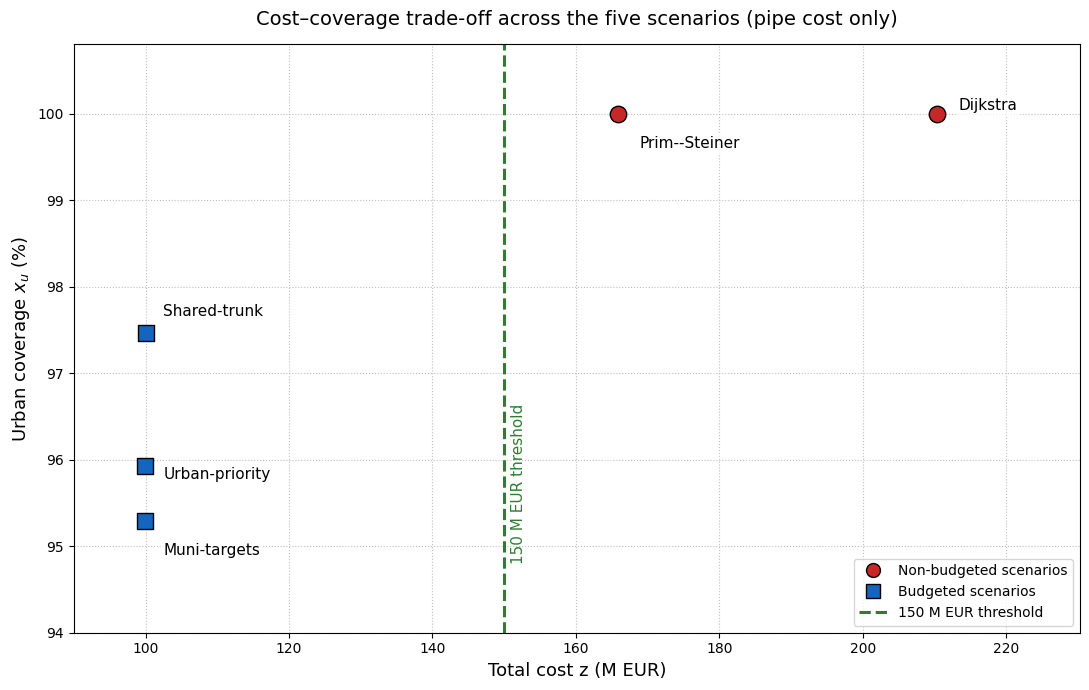


Saved figure files:
  PNG : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_tradeoff\chapter6_cost_coverage_tradeoff.png
  PDF : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_tradeoff\chapter6_cost_coverage_tradeoff.pdf
  SVG : C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_tradeoff\chapter6_cost_coverage_tradeoff.svg

LaTeX snippet saved to:
  C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\After_Manual_Networks_Correction\chapter6_tradeoff\latex_figure_cost_coverage_tradeoff.tex

BLOCK 14 COMPLETED


In [14]:
# ============================================================
# BLOCK 14 -- COST-COVERAGE TRADE-OFF PLOT ACROSS SCENARIOS
# ============================================================
# Purpose:
#   Create a publication-ready scatter plot showing the trade-off
#   between total cost and urban coverage across the five scenarios.
#
# The block:
#   - reads the final manual-corrected outputs
#   - computes urban coverage x_u
#   - computes total cost z
#   - optionally includes pumping-station costs if the pumping-results
#     GeoPackages are found
#   - plots a 150 M EUR threshold line
#   - saves PNG / PDF / SVG + CSV summary
#
# Outputs:
#   Results/After_Manual_Networks_Correction/chapter6_tradeoff/
#       chapter6_cost_coverage_tradeoff.png
#       chapter6_cost_coverage_tradeoff.pdf
#       chapter6_cost_coverage_tradeoff.svg
#       chapter6_cost_coverage_tradeoff_data.csv
# ============================================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import fiona

print("=" * 120)
print("BLOCK 14 -- COST-COVERAGE TRADE-OFF PLOT ACROSS SCENARIOS")
print("=" * 120)

# ------------------------------------------------------------
# 0. CHECK REQUIREMENTS
# ------------------------------------------------------------

if "FINAL_MANUAL_CORRECTION_RESULTS" not in globals() or len(FINAL_MANUAL_CORRECTION_RESULTS) == 0:
    raise RuntimeError(
        "Run the previous corrected-network blocks first. "
        "FINAL_MANUAL_CORRECTION_RESULTS is missing or empty."
    )

if "PIPE_COST_EUR_PER_M" not in globals():
    PIPE_COST_EUR_PER_M = 400.0

NEW_PS_UNIT_COST_EUR = 1_500_000.0
BUDGET_THRESHOLD_MEUR = 150.0

if "MANUAL_CORRECTION_DIR" not in globals():
    MANUAL_CORRECTION_DIR = RESULTS_DIR / "After_Manual_Networks_Correction"

TRADEOFF_DIR = MANUAL_CORRECTION_DIR / "chapter6_tradeoff"
TRADEOFF_DIR.mkdir(parents=True, exist_ok=True)

# Optional pumping-station results folder
DEFAULT_PUMPING_RESULTS_DIR = Path(
    r"C:\Users\lucam\OneDrive\Desktop\Cyprus Project\Results\PunpingStations_Positioning"
)
PUMPING_RESULTS_DIR = globals().get("OUTPUT_DIR", DEFAULT_PUMPING_RESULTS_DIR)

# ------------------------------------------------------------
# 1. SCENARIO ORDER / LABELS / FAMILY
# ------------------------------------------------------------

PREFERRED_SCENARIO_ORDER = [
    "dijkstra",
    "prim_steiner",
    "shared_trunk",
    "urban_priority",
    "municipality_targets",
]

SCENARIO_DISPLAY = {
    "dijkstra": "Rooted Dijkstra",
    "prim_steiner": "Prim--Steiner",
    "shared_trunk": "Shared-trunk",
    "urban_priority": "Urban-priority",
    "municipality_targets": "Municipality-targets",
}

SCENARIO_SHORT = {
    "dijkstra": "Dijkstra",
    "prim_steiner": "Prim--Steiner",
    "shared_trunk": "Shared-trunk",
    "urban_priority": "Urban-priority",
    "municipality_targets": "Muni-targets",
}

SCENARIO_FAMILY = {
    "dijkstra": "Non-budgeted",
    "prim_steiner": "Non-budgeted",
    "shared_trunk": "Budgeted",
    "urban_priority": "Budgeted",
    "municipality_targets": "Budgeted",
}

scenario_keys_available = list(FINAL_MANUAL_CORRECTION_RESULTS.keys())
SCENARIO_ORDER = [s for s in PREFERRED_SCENARIO_ORDER if s in scenario_keys_available]
SCENARIO_ORDER += [s for s in scenario_keys_available if s not in SCENARIO_ORDER]

# ------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------

def _list_layers(gpkg_path):
    try:
        return list(fiona.listlayers(str(gpkg_path)))
    except Exception:
        return []


def _layer_exists(gpkg_path, layer_name):
    return layer_name in _list_layers(gpkg_path)


def _read_layer(gpkg_path, layer_name, target_crs=None):
    gdf = gpd.read_file(gpkg_path, layer=layer_name)

    if target_crs is not None:
        if gdf.crs is None:
            gdf = gdf.set_crs(target_crs)
        else:
            gdf = gdf.to_crs(target_crs)

    return gdf


def _read_layer_if_exists(gpkg_path, layer_name, target_crs=None):
    gpkg_path = Path(gpkg_path)
    if not gpkg_path.exists():
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    if not _layer_exists(gpkg_path, layer_name):
        return gpd.GeoDataFrame(geometry=[], crs=target_crs)

    return _read_layer(gpkg_path, layer_name, target_crs=target_crs)


def _safe_numeric(series, default=0.0):
    return pd.to_numeric(series, errors="coerce").fillna(default)


def _safe_bool(series):
    if str(series.dtype) == "bool":
        return series.fillna(False)
    return (
        series.astype(str)
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def _line_length_m(gdf):
    if gdf is None or len(gdf) == 0:
        return 0.0
    return float(gdf.geometry.length.sum())


def _find_new_ps_count_from_pumping_outputs(scenario_key):
    """
    If a pumping-station GeoPackage exists for this scenario,
    count the new pumping stations from layer new_ps_final_candidates.
    """
    pumping_gpkg = Path(PUMPING_RESULTS_DIR) / f"{scenario_key}_pumping_stations.gpkg"

    if not pumping_gpkg.exists():
        return 0, False, pumping_gpkg

    # preferred layer name
    layer_candidates = [
        "new_ps_final_candidates",
        "new_pumping_stations",
        "new_ps",
    ]

    for lyr in layer_candidates:
        if _layer_exists(pumping_gpkg, lyr):
            try:
                gdf = _read_layer(pumping_gpkg, lyr)
                return len(gdf), True, pumping_gpkg
            except Exception:
                pass

    return 0, False, pumping_gpkg


# ------------------------------------------------------------
# 3. EXTRACT COST / COVERAGE PER SCENARIO
# ------------------------------------------------------------

rows = []

for scenario_key in SCENARIO_ORDER:
    result = FINAL_MANUAL_CORRECTION_RESULTS[scenario_key]
    final_gpkg = Path(result["final_gpkg"])

    print("\n" + "=" * 100)
    print(f"Scenario: {scenario_key}")
    print(final_gpkg)
    print("=" * 100)

    if not final_gpkg.exists():
        print("  [SKIP] final_gpkg not found.")
        continue

    # ----------------------------------------
    # 3.1 Demand nodes and urban coverage
    # ----------------------------------------
    demand_nodes = _read_layer_if_exists(
        final_gpkg,
        "demand_nodes_final_manual_assignment",
        target_crs=CRS_PROJECTED if "CRS_PROJECTED" in globals() else None,
    )

    if len(demand_nodes) == 0:
        raise RuntimeError(
            f"Layer 'demand_nodes_final_manual_assignment' missing or empty in:\n{final_gpkg}"
        )

    if "assigned_population" not in demand_nodes.columns:
        raise RuntimeError(
            f"'assigned_population' missing in demand_nodes_final_manual_assignment for {scenario_key}"
        )

    demand_nodes["assigned_population"] = _safe_numeric(demand_nodes["assigned_population"])

    # Urban / considered demand nodes
    if "load_eligible" in demand_nodes.columns:
        urban_mask = _safe_bool(demand_nodes["load_eligible"])
    elif "consider_for_load_balance" in demand_nodes.columns:
        urban_mask = _safe_bool(demand_nodes["consider_for_load_balance"])
    else:
        # fallback: positive assigned population
        urban_mask = demand_nodes["assigned_population"] > 0

    # Served nodes
    if "final_covered_by_system" in demand_nodes.columns:
        served_mask = _safe_bool(demand_nodes["final_covered_by_system"])
    elif "final_wwtp_assignment" in demand_nodes.columns:
        served_mask = demand_nodes["final_wwtp_assignment"].notna() & (
            demand_nodes["final_wwtp_assignment"].astype(str).str.strip() != ""
        )
    else:
        served_mask = pd.Series(False, index=demand_nodes.index)

    urban_nodes = demand_nodes[urban_mask].copy()
    served_urban_nodes = demand_nodes[urban_mask & served_mask].copy()

    urban_pop_total = float(urban_nodes["assigned_population"].sum())
    urban_pop_served = float(served_urban_nodes["assigned_population"].sum())
    urban_pop_uncovered = urban_pop_total - urban_pop_served
    urban_coverage_pct = 100.0 * urban_pop_served / urban_pop_total if urban_pop_total > 0 else 0.0

    # ----------------------------------------
    # 3.2 New pipe cost
    # ----------------------------------------
    # preferred layer for newly built WWTP2 network
    new_pipe_layer_candidates = [
        "new_pipes_WWTP2_final",
        "new_pipes_WWTP2_final_manual",
        "new_pipes_reference",
        "new_pipes_final",
    ]

    new_pipes = None
    used_new_pipe_layer = None

    for lyr in new_pipe_layer_candidates:
        tmp = _read_layer_if_exists(
            final_gpkg,
            lyr,
            target_crs=CRS_PROJECTED if "CRS_PROJECTED" in globals() else None,
        )
        if len(tmp) > 0:
            new_pipes = tmp
            used_new_pipe_layer = lyr
            break

    if new_pipes is None or len(new_pipes) == 0:
        new_pipe_length_m = 0.0
        pipe_cost_eur = 0.0
    else:
        if "length_m" in new_pipes.columns:
            new_pipe_length_m = float(_safe_numeric(new_pipes["length_m"]).sum())
        else:
            new_pipe_length_m = _line_length_m(new_pipes)

        pipe_cost_eur = new_pipe_length_m * PIPE_COST_EUR_PER_M

    # ----------------------------------------
    # 3.3 Optional pumping cost
    # ----------------------------------------
    new_ps_count, pumping_found, pumping_gpkg = _find_new_ps_count_from_pumping_outputs(scenario_key)
    pumping_cost_eur = new_ps_count * NEW_PS_UNIT_COST_EUR

    # ----------------------------------------
    # 3.4 Total cost
    # ----------------------------------------
    total_cost_eur = pipe_cost_eur + pumping_cost_eur
    total_cost_meur = total_cost_eur / 1e6
    pipe_cost_meur = pipe_cost_eur / 1e6
    pumping_cost_meur = pumping_cost_eur / 1e6

    rows.append({
        "scenario_key": scenario_key,
        "scenario": SCENARIO_DISPLAY.get(scenario_key, scenario_key),
        "scenario_short": SCENARIO_SHORT.get(scenario_key, scenario_key),
        "family": SCENARIO_FAMILY.get(scenario_key, "Unknown"),
        "urban_pop_total": urban_pop_total,
        "urban_pop_served": urban_pop_served,
        "urban_pop_uncovered": urban_pop_uncovered,
        "urban_coverage_pct": urban_coverage_pct,
        "new_pipe_length_m": new_pipe_length_m,
        "new_pipe_length_km": new_pipe_length_m / 1000.0,
        "pipe_cost_eur": pipe_cost_eur,
        "pipe_cost_meur": pipe_cost_meur,
        "new_ps_count": new_ps_count,
        "pumping_cost_eur": pumping_cost_eur,
        "pumping_cost_meur": pumping_cost_meur,
        "total_cost_eur": total_cost_eur,
        "total_cost_meur": total_cost_meur,
        "used_new_pipe_layer": used_new_pipe_layer,
        "pumping_results_found": pumping_found,
        "pumping_gpkg": str(pumping_gpkg),
    })

    print(f"  Urban pop served / total : {urban_pop_served:,.0f} / {urban_pop_total:,.0f}")
    print(f"  Urban coverage           : {urban_coverage_pct:.2f}%")
    print(f"  New pipe length          : {new_pipe_length_m/1000.0:.2f} km")
    print(f"  Pipe cost                : €{pipe_cost_meur:.2f} M")
    print(f"  New pumping stations     : {new_ps_count}")
    print(f"  Pumping cost             : €{pumping_cost_meur:.2f} M")
    print(f"  Total cost               : €{total_cost_meur:.2f} M")

tradeoff_df = pd.DataFrame(rows)

if len(tradeoff_df) == 0:
    raise RuntimeError("No scenario data extracted for the trade-off plot.")

tradeoff_df["_scenario_sort"] = tradeoff_df["scenario_key"].apply(
    lambda x: SCENARIO_ORDER.index(x) if x in SCENARIO_ORDER else 999
)
tradeoff_df = tradeoff_df.sort_values("_scenario_sort").drop(columns="_scenario_sort").reset_index(drop=True)

# Save raw data
csv_path = TRADEOFF_DIR / "chapter6_cost_coverage_tradeoff_data.csv"
tradeoff_df.to_csv(csv_path, index=False)

print("\nTRADE-OFF DATA")
print(tradeoff_df.to_string(index=False))
print(f"\nCSV saved to:\n  {csv_path}")

# ------------------------------------------------------------
# 4. PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Different style for family
style_map = {
    "Non-budgeted": {"color": "#C62828", "marker": "o", "size": 140},
    "Budgeted": {"color": "#1565C0", "marker": "s", "size": 140},
    "Unknown": {"color": "#616161", "marker": "o", "size": 140},
}

for _, row in tradeoff_df.iterrows():
    style = style_map.get(row["family"], style_map["Unknown"])

    ax.scatter(
        row["total_cost_meur"],
        row["urban_coverage_pct"],
        s=style["size"],
        c=style["color"],
        marker=style["marker"],
        edgecolors="black",
        linewidths=1.0,
        zorder=3,
    )

    # annotation offsets tuned per scenario
    dx, dy = 2.0, 0.15
    if row["scenario_key"] == "dijkstra":
        dx, dy = 3.0, 0.10
    elif row["scenario_key"] == "prim_steiner":
        dx, dy = 3.0, -0.35
    elif row["scenario_key"] == "shared_trunk":
        dx, dy = 2.5, 0.25
    elif row["scenario_key"] == "urban_priority":
        dx, dy = 2.5, -0.10
    elif row["scenario_key"] == "municipality_targets":
        dx, dy = 2.5, -0.35

    ax.annotate(
        row["scenario_short"],
        (row["total_cost_meur"], row["urban_coverage_pct"]),
        xytext=(row["total_cost_meur"] + dx, row["urban_coverage_pct"] + dy),
        textcoords="data",
        fontsize=11,
        ha="left",
        va="center",
        zorder=4,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

# Budget threshold line
ax.axvline(
    BUDGET_THRESHOLD_MEUR,
    color="#2E7D32",
    linestyle="--",
    linewidth=2.2,
    zorder=2,
)

ax.text(
    BUDGET_THRESHOLD_MEUR + 1.0,
    tradeoff_df["urban_coverage_pct"].min() - 0.5,
    "150 M EUR threshold",
    color="#2E7D32",
    fontsize=11,
    rotation=90,
    va="bottom",
    ha="left",
)

# Axes labels
ax.set_xlabel("Total cost z (M EUR)", fontsize=13)
ax.set_ylabel("Urban coverage $x_u$ (%)", fontsize=13)

# Title
if tradeoff_df["pumping_results_found"].all():
    title_suffix = " (pipes + new pumping stations)"
elif tradeoff_df["pumping_results_found"].any():
    title_suffix = " (mixed: pumping included where available)"
else:
    title_suffix = " (pipe cost only)"

ax.set_title(
    "Cost–coverage trade-off across the five scenarios" + title_suffix,
    fontsize=14,
    pad=14,
)

# Grid and limits
x_min = min(BUDGET_THRESHOLD_MEUR - 20, tradeoff_df["total_cost_meur"].min() - 10)
x_max = max(tradeoff_df["total_cost_meur"].max() + 20, BUDGET_THRESHOLD_MEUR + 20)

y_min = min(94.0, tradeoff_df["urban_coverage_pct"].min() - 1.0)
y_max = max(100.8, tradeoff_df["urban_coverage_pct"].max() + 0.8)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)

# Legend
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Non-budgeted scenarios',
           markerfacecolor=style_map["Non-budgeted"]["color"], markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Budgeted scenarios',
           markerfacecolor=style_map["Budgeted"]["color"], markeredgecolor='black', markersize=10),
    Line2D([0], [0], color="#2E7D32", lw=2.2, linestyle="--", label='150 M EUR threshold'),
]

ax.legend(handles=legend_handles, loc="lower right", frameon=True)

plt.tight_layout()

# ------------------------------------------------------------
# 5. SAVE FIGURE
# ------------------------------------------------------------

png_path = TRADEOFF_DIR / "chapter6_cost_coverage_tradeoff.png"
pdf_path = TRADEOFF_DIR / "chapter6_cost_coverage_tradeoff.pdf"
svg_path = TRADEOFF_DIR / "chapter6_cost_coverage_tradeoff.svg"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

plt.show()

print("\nSaved figure files:")
print(f"  PNG : {png_path}")
print(f"  PDF : {pdf_path}")
print(f"  SVG : {svg_path}")

# ------------------------------------------------------------
# 6. OPTIONAL LATEX SNIPPET
# ------------------------------------------------------------

latex_snippet = rf"""
\begin{{figure}}[H]
    \centering
    \includegraphics[width=0.88\textwidth]{{figures/chapter6_cost_coverage_tradeoff.png}}
    \caption{{Cost--coverage trade-off across the five scenarios. Full urban coverage requires substantially higher total cost than the budgeted alternatives, which cluster closely in both cost and coverage. The dashed vertical line marks the EUR~150~million threshold.}}
    \label{{fig:tradeoff-coverage-cost}}
\end{{figure}}
"""

latex_path = TRADEOFF_DIR / "latex_figure_cost_coverage_tradeoff.tex"
latex_path.write_text(latex_snippet.strip() + "\n", encoding="utf-8")

print(f"\nLaTeX snippet saved to:\n  {latex_path}")

print("\nBLOCK 14 COMPLETED")
print("=" * 120)